## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import os
from scipy.sparse.linalg import eigsh
import finite_difference_quantum as fin


## Plot Configuration


In [2]:
FIGURE_WIDTH = 8.0
FIGURE_HEIGHT = 6.0
FIGURE_DPI = 300

FONT_SIZE = 12
TITLE_SIZE = 14
LABEL_SIZE = 12
LEGEND_SIZE = 10
TICK_SIZE = 10

plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE,
    'figure.titlesize': TITLE_SIZE + 2,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'patch.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'savefig.dpi': FIGURE_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})

COLOR_2ND = '#1f77b4'
COLOR_4TH = '#ff7f0e'
COLOR_THEORY = '#2ca02c'
COLOR_ERROR = '#d62728'

LINE_STYLE_2ND = '-'
LINE_STYLE_4TH = '--'
LINE_STYLE_THEORY = ':'
LINE_STYLE_ERROR = '-.'

MARKER_2ND = 'o'
MARKER_4TH = 's'
MARKER_THEORY = '^'

GRID_ALPHA = 0.3
GRID_LINESTYLE = '--'
GRID_LINEWIDTH = 0.8

CONVERGENCE_X_LABEL = 'Grid Size N'
CONVERGENCE_Y_LABEL = 'Error'
CONVERGENCE_TITLE_PREFIX = 'Convergence Analysis'

TIMING_X_LABEL = 'Grid Size N'
TIMING_Y_LABEL = 'Time (seconds)'
TIMING_TITLE_PREFIX = 'Timing Comparison'

ACCURACY_X_LABEL = 'Eigenvalue Index'
ACCURACY_Y_LABEL = 'Absolute Error'
ACCURACY_TITLE_PREFIX = 'Accuracy Comparison'

SPECTRUM_X_LABEL = 'Quantum Number n'
SPECTRUM_Y_LABEL = 'Energy'
SPECTRUM_TITLE_PREFIX = 'Energy Spectrum'

WAVEFUNCTION_X_LABEL = r'$\tilde{x}$'
WAVEFUNCTION_Y_LABEL = r'$\psi(\tilde{x})$'
WAVEFUNCTION_TITLE_PREFIX = 'Wavefunction'

OUTPUT_DIR = 'images'
OUTPUT_FORMAT = 'png'

def get_figure(figsize=None, dpi=None):
    if figsize is None:
        figsize = (FIGURE_WIDTH, FIGURE_HEIGHT)
    if dpi is None:
        dpi = FIGURE_DPI
    return plt.figure(figsize=figsize, dpi=dpi)

def apply_style(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)
    return ax

def save_figure(filename, output_dir=None, format=None):
    if output_dir is None:
        output_dir = OUTPUT_DIR
    if format is None:
        format = OUTPUT_FORMAT
    
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, f"{filename}.{format}")
    plt.savefig(filepath, dpi=FIGURE_DPI, bbox_inches='tight', pad_inches=0.1, format=format)
    print(f"Saved: {filepath}")
    return filepath

def get_order_color(order):
    return COLOR_2ND if order == 2 else COLOR_4TH

def get_order_label(order):
    return f"{order}nd Order" if order == 2 else f"{order}th Order"

def get_order_style(order):
    return LINE_STYLE_2ND if order == 2 else LINE_STYLE_4TH

def get_order_marker(order):
    return MARKER_2ND if order == 2 else MARKER_4TH



## Plotting Utilities


In [3]:
def plot_convergence(N_values, errors_2nd, errors_4th, system_name='', 
                     ylabel=None, log_scale=True, save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    if ylabel is None:
        ylabel = CONVERGENCE_Y_LABEL
    
    ax.plot(N_values, errors_2nd, 
            color=COLOR_2ND, linestyle=get_order_style(2), 
            marker=get_order_marker(2), label=get_order_label(2),
            linewidth=2, markersize=6)
    ax.plot(N_values, errors_4th, 
            color=COLOR_4TH, linestyle=get_order_style(4), 
            marker=get_order_marker(4), label=get_order_label(4),
            linewidth=2, markersize=6)
    
    ax.set_xlabel(CONVERGENCE_X_LABEL)
    ax.set_ylabel(ylabel)
    title = f"{CONVERGENCE_TITLE_PREFIX}: {system_name}" if system_name else CONVERGENCE_TITLE_PREFIX
    ax.set_title(title)
    ax.legend()
    
    if log_scale:
        ax.set_yscale('log')
        ax.set_xscale('log')
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()

def plot_timing(N_values, times_2nd, times_4th, system_name='', save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    ax.plot(N_values, times_2nd, 
            color=COLOR_2ND, linestyle=get_order_style(2),
            marker=get_order_marker(2), label=get_order_label(2),
            linewidth=2, markersize=6)
    ax.plot(N_values, times_4th, 
            color=COLOR_4TH, linestyle=get_order_style(4),
            marker=get_order_marker(4), label=get_order_label(4),
            linewidth=2, markersize=6)
    
    ax.set_xlabel(TIMING_X_LABEL)
    ax.set_ylabel(TIMING_Y_LABEL)
    title = f"{TIMING_TITLE_PREFIX}: {system_name}" if system_name else TIMING_TITLE_PREFIX
    ax.set_title(title)
    ax.legend()
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()

def plot_accuracy(eigenvalue_indices, errors_2nd, errors_4th, 
                  system_name='', log_scale=True, save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    ax.plot(eigenvalue_indices, errors_2nd, 
            color=COLOR_2ND, linestyle=get_order_style(2),
            marker=get_order_marker(2), label=get_order_label(2),
            linewidth=2, markersize=8)
    ax.plot(eigenvalue_indices, errors_4th, 
            color=COLOR_4TH, linestyle=get_order_style(4),
            marker=get_order_marker(4), label=get_order_label(4),
            linewidth=2, markersize=8)
    
    ax.set_xlabel(ACCURACY_X_LABEL)
    ax.set_ylabel(ACCURACY_Y_LABEL)
    title = f"{ACCURACY_TITLE_PREFIX}: {system_name}" if system_name else ACCURACY_TITLE_PREFIX
    ax.set_title(title)
    ax.legend()
    
    if log_scale:
        ax.set_yscale('log')
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()

def plot_energy_spectrum(quantum_numbers, energies_2nd, energies_4th, 
                         energies_theory=None, system_name='', save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    ax.plot(quantum_numbers, energies_2nd, 
            color=COLOR_2ND, linestyle=get_order_style(2),
            marker=get_order_marker(2), label=get_order_label(2),
            linewidth=2, markersize=8)
    ax.plot(quantum_numbers, energies_4th, 
            color=COLOR_4TH, linestyle=get_order_style(4),
            marker=get_order_marker(4), label=get_order_label(4),
            linewidth=2, markersize=8)
    
    if energies_theory is not None:
        ax.plot(quantum_numbers, energies_theory, 
                color=COLOR_THEORY, linestyle=LINE_STYLE_THEORY,
                marker=MARKER_THEORY, label='Theory',
                linewidth=2, markersize=8)
    
    ax.set_xlabel(SPECTRUM_X_LABEL)
    ax.set_ylabel(SPECTRUM_Y_LABEL)
    title = f"{SPECTRUM_TITLE_PREFIX}: {system_name}" if system_name else SPECTRUM_TITLE_PREFIX
    ax.set_title(title)
    ax.legend()
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()

def plot_wavefunctions(x, wavefunctions_2nd, wavefunctions_4th, 
                       wavefunctions_theory=None, labels=None,
                       system_name='', state_index=0, save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    if labels is None:
        labels = [f"n={i}" for i in range(len(wavefunctions_2nd))]
    
    ax.plot(x, wavefunctions_2nd[state_index], 
            color=COLOR_2ND, linestyle=get_order_style(2),
            label=f"{get_order_label(2)} {labels[state_index]}",
            linewidth=2)
    
    ax.plot(x, wavefunctions_4th[state_index], 
            color=COLOR_4TH, linestyle=get_order_style(4),
            label=f"{get_order_label(4)} {labels[state_index]}",
            linewidth=2)
    
    if wavefunctions_theory is not None:
        ax.plot(x, wavefunctions_theory[state_index], 
                color=COLOR_THEORY, linestyle=LINE_STYLE_THEORY,
                label=f"Theory {labels[state_index]}",
                linewidth=2)
    
    ax.set_xlabel(WAVEFUNCTION_X_LABEL)
    ax.set_ylabel(WAVEFUNCTION_Y_LABEL)
    title = f"{WAVEFUNCTION_TITLE_PREFIX}: {system_name} {labels[state_index]}"
    ax.set_title(title)
    ax.legend()
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()

def plot_error_vs_parameter(parameter_values, errors_2nd, errors_4th,
                           parameter_name='Parameter', system_name='',
                           log_scale=True, save_name=None):
    fig = get_figure()
    ax = apply_style()
    
    ax.plot(parameter_values, errors_2nd, 
            color=COLOR_2ND, linestyle=get_order_style(2),
            marker=get_order_marker(2), label=get_order_label(2),
            linewidth=2, markersize=6)
    ax.plot(parameter_values, errors_4th, 
            color=COLOR_4TH, linestyle=get_order_style(4),
            marker=get_order_marker(4), label=get_order_label(4),
            linewidth=2, markersize=6)
    
    ax.set_xlabel(parameter_name)
    ax.set_ylabel('Error')
    title = f"Error vs {parameter_name}: {system_name}" if system_name else f"Error vs {parameter_name}"
    ax.set_title(title)
    ax.legend()
    
    if log_scale:
        ax.set_yscale('log')
    
    plt.tight_layout()
    
    if save_name:
        save_figure(save_name)
    else:
        plt.show()



## Analysis Generator


In [4]:
class AnalysisConfig:
    def __init__(self, system_name='', potential_func=None, 
                 x_inf=5.0, N_default=1000, n_eigenvalues=10,
                 theory_energies=None, theory_wavefunctions=None):
        self.system_name = system_name
        self.potential_func = potential_func
        self.x_inf = x_inf
        self.N_default = N_default
        self.n_eigenvalues = n_eigenvalues
        self.theory_energies = theory_energies
        self.theory_wavefunctions = theory_wavefunctions

def compute_eigenvalues(config, N, order=2, k=None):
    """
    Compute eigenvalues using a robust strategy with multiple fallback levels.
    For 2nd order, uses more aggressive parameters and progressive fallback.
    """
    if k is None:
        k = config.n_eigenvalues
    
    H = fin.hamiltonian(config.potential_func, -config.x_inf, config.x_inf, N, order=order)
    
    # Always try direct first, with progressive as fallback
    try:
        return _compute_eigenvalues_direct(H, N, k, order)
    except Exception as e:
        # If direct fails, try progressive (especially useful for 2nd order)
        print(f"  Direct computation failed, trying progressive approach...")
        return _compute_eigenvalues_progressive(H, N, k, order)

def _compute_eigenvalues_direct(H, N, k, order):
    """Direct computation with aggressive parameters."""
    # Very aggressive parameters for robustness
    base_maxiter = 50000
    base_tol = 1e-8
    
    # Scale based on N
    if N > 5000:
        maxiter_multiplier = 15.0
        tol_val = 1e-6
    elif N > 2000:
        maxiter_multiplier = 8.0
        tol_val = 1e-7
    else:
        maxiter_multiplier = 1.0
        tol_val = base_tol
    
    # Scale based on k
    if k > 10:
        k_multiplier = 3.0 + 0.3 * (k - 10)
    elif k > 5:
        k_multiplier = 2.0 + 0.2 * (k - 5)
    elif k > 1:
        k_multiplier = 1.5 + 0.1 * (k - 1)
    else:
        k_multiplier = 1.0
    
    # 2nd order needs extra iterations
    if order == 2:
        order_multiplier = 3.0
    else:
        order_multiplier = 1.0
    
    maxiter_val = int(base_maxiter * maxiter_multiplier * k_multiplier * order_multiplier)
    ncv_val = min(max(2*k + 1, k + 5), N, 100)  # Increased ncv cap
    
    # Try multiple strategies
    strategies = [
        {'tol': tol_val, 'maxiter': maxiter_val, 'ncv': ncv_val},
        {'tol': tol_val * 10, 'maxiter': maxiter_val * 2, 'ncv': min(ncv_val * 2, N)},
        {'tol': 1e-5, 'maxiter': maxiter_val * 3, 'ncv': min(ncv_val * 3, N)},
        {'tol': 1e-4, 'maxiter': maxiter_val * 5, 'ncv': min(ncv_val * 4, N)}
    ]
    
    for i, params in enumerate(strategies):
        try:
            E = eigsh(H, k=k, which='SM', tol=params['tol'], 
                     maxiter=params['maxiter'], ncv=params['ncv'], 
                     return_eigenvectors=False)
            if i > 0:
                print(f"  Converged with strategy {i+1} (tol={params['tol']:.1e})")
            return np.sort(E)
        except Exception as e:
            if i < len(strategies) - 1:
                continue
            else:
                # Last strategy failed, try progressive approach
                print(f"  Direct computation failed, trying progressive approach...")
                return _compute_eigenvalues_progressive(H, N, k, order)

def _compute_eigenvalues_progressive(H, N, k, order):
    """
    Progressive strategy: compute eigenvalues one at a time.
    This is more robust for 2nd order methods when batch computation fails.
    """
    all_eigenvalues = []
    
    # Compute eigenvalues one at a time - this is slower but more reliable
    for i in range(k):
        try:
            # Compute one more eigenvalue than we already have
            current_k = len(all_eigenvalues) + 1
            E_batch = _compute_eigenvalues_direct(H, N, current_k, order)
            # Take only the new eigenvalue (the last one)
            all_eigenvalues.append(E_batch[-1])
        except Exception as e:
            print(f"  Warning: Failed to compute eigenvalue {len(all_eigenvalues)+1}, stopping at {len(all_eigenvalues)} eigenvalues.")
            break
    
    if len(all_eigenvalues) == 0:
        raise RuntimeError("Failed to compute any eigenvalues with progressive strategy")
    
    return np.sort(np.array(all_eigenvalues))

def compute_eigenvalues_and_vectors(config, N, order=2, k=None):
    """
    Compute eigenvalues and eigenvectors using a robust strategy with fallbacks.
    """
    if k is None:
        k = config.n_eigenvalues
    
    H = fin.hamiltonian(config.potential_func, -config.x_inf, config.x_inf, N, order=order)
    
    # Always try direct first, with progressive as fallback
    try:
        return _compute_eigenvalues_and_vectors_direct(H, N, k, order, config)
    except Exception as e:
        print(f"  Direct computation failed, trying progressive approach...")
        return _compute_eigenvalues_and_vectors_progressive(H, N, k, order, config)

def _compute_eigenvalues_and_vectors_direct(H, N, k, order, config):
    """Direct computation with aggressive parameters."""
    base_maxiter = 50000
    base_tol = 1e-8
    
    if N > 5000:
        maxiter_multiplier = 15.0
        tol_val = 1e-6
    elif N > 2000:
        maxiter_multiplier = 8.0
        tol_val = 1e-7
    else:
        maxiter_multiplier = 1.0
        tol_val = base_tol
    
    if k > 10:
        k_multiplier = 3.0 + 0.3 * (k - 10)
    elif k > 5:
        k_multiplier = 2.0 + 0.2 * (k - 5)
    elif k > 1:
        k_multiplier = 1.5 + 0.1 * (k - 1)
    else:
        k_multiplier = 1.0
    
    if order == 2:
        order_multiplier = 3.0
    else:
        order_multiplier = 1.0
    
    maxiter_val = int(base_maxiter * maxiter_multiplier * k_multiplier * order_multiplier)
    ncv_val = min(max(2*k + 1, k + 5), N, 100)
    
    strategies = [
        {'tol': tol_val, 'maxiter': maxiter_val, 'ncv': ncv_val},
        {'tol': tol_val * 10, 'maxiter': maxiter_val * 2, 'ncv': min(ncv_val * 2, N)},
        {'tol': 1e-5, 'maxiter': maxiter_val * 3, 'ncv': min(ncv_val * 3, N)},
        {'tol': 1e-4, 'maxiter': maxiter_val * 5, 'ncv': min(ncv_val * 4, N)}
    ]
    
    for i, params in enumerate(strategies):
        try:
            E, vecs = eigsh(H, k=k, which='SM', tol=params['tol'], 
                           maxiter=params['maxiter'], ncv=params['ncv'])
            if i > 0:
                print(f"  Converged with strategy {i+1} (tol={params['tol']:.1e})")
            
            idx = np.argsort(E)
            E = E[idx]
            vecs = vecs[:, idx]
            
            x = fin.spatial(-config.x_inf, config.x_inf, N)
            dx = x[1] - x[0]
            vecs = vecs / np.sqrt(dx)
            
            for j in range(k):
                jm = np.argmax(np.abs(vecs[:, j]))
                if vecs[jm, j] < 0:
                    vecs[:, j] *= -1
            
            return E, vecs
        except Exception as e:
            if i < len(strategies) - 1:
                continue
            else:
                print(f"  Direct computation failed, trying progressive approach...")
                return _compute_eigenvalues_and_vectors_progressive(H, N, k, order, config)

def _compute_eigenvalues_and_vectors_progressive(H, N, k, order, config):
    """Progressive strategy: compute eigenvalues and eigenvectors one at a time."""
    all_eigenvalues = []
    all_vectors = None
    
    # Compute eigenvalues one at a time
    for i in range(k):
        try:
            # Compute one more eigenvalue than we already have
            current_k = len(all_eigenvalues) + 1
            E_batch, vecs_batch = _compute_eigenvalues_and_vectors_direct(H, N, current_k, order, config)
            # Take only the new eigenvalue/eigenvector (the last one)
            all_eigenvalues.append(E_batch[-1])
            if all_vectors is not None:
                all_vectors = np.hstack([all_vectors, vecs_batch[:, -1:]])
            else:
                all_vectors = vecs_batch[:, -1:]
        except Exception as e:
            print(f"  Warning: Failed to compute eigenvalue {len(all_eigenvalues)+1}, stopping at {len(all_eigenvalues)} eigenvalues.")
            break
    
    if len(all_eigenvalues) == 0:
        raise RuntimeError("Failed to compute any eigenvalues with progressive strategy")
    
    # Sort by eigenvalue
    idx = np.argsort(all_eigenvalues)
    E = np.array(all_eigenvalues)[idx]
    vecs = all_vectors[:, idx] if all_vectors is not None else None
    
    return E, vecs

def compute_timing(config, N_values, order=2):
    times = []
    for N in N_values:
        start = time.time()
        fin.hamiltonian(config.potential_func, -config.x_inf, config.x_inf, N, order=order)
        times.append(time.time() - start)
    return np.array(times)



In [5]:
def generate_convergence_analysis(config, N_values, reference_N=10000, 
                                  reference_order=4, save_name=None):
    print(f"Generating convergence analysis for {config.system_name}...")

    # Prefer analytical reference if available (avoids huge reference_N solves)
    if config.theory_energies is not None:
        E_ref = np.array([config.theory_energies(0)])
        print(f"  Using analytical reference energy (ground state): {E_ref[0]:.12g}")
    else:
        print(f"  Computing reference solution (N={reference_N}, order={reference_order})...")
        # Only compute ground state for reference (k=1) to avoid convergence issues
        E_ref = compute_eigenvalues(config, reference_N, order=reference_order, k=1)
    
    errors_2nd = []
    errors_4th = []
    
    for N in N_values:
        print(f"  Computing N={N}...")
        # Only compute ground state for convergence analysis
        E_2nd = compute_eigenvalues(config, N, order=2, k=1)
        E_4th = compute_eigenvalues(config, N, order=4, k=1)
        
        err_2nd = np.abs(E_2nd[0] - E_ref[0]) / np.abs(E_ref[0])
        err_4th = np.abs(E_4th[0] - E_ref[0]) / np.abs(E_ref[0])
        
        errors_2nd.append(err_2nd)
        errors_4th.append(err_4th)
    
    errors_2nd = np.array(errors_2nd)
    errors_4th = np.array(errors_4th)
    
    filename = save_name or f"convergence_{config.system_name.lower()}"
    plot_convergence(N_values, errors_2nd, errors_4th, 
                     system_name=config.system_name,
                     ylabel='Relative Error (Ground State)',
                     save_name=filename)
    
    return {
        'N_values': N_values,
        'errors_2nd': errors_2nd,
        'errors_4th': errors_4th,
        'reference_energy': E_ref[0]
    }

def generate_timing_analysis(config, N_values, save_name=None):
    print(f"Generating timing analysis for {config.system_name}...")
    
    print("  Computing 2nd order timings...")
    times_2nd = compute_timing(config, N_values, order=2)
    
    print("  Computing 4th order timings...")
    times_4th = compute_timing(config, N_values, order=4)
    
    filename = save_name or f"timing_{config.system_name.lower()}"
    plot_timing(N_values, times_2nd, times_4th, 
                system_name=config.system_name,
                save_name=filename)
    
    return {
        'N_values': N_values,
        'times_2nd': times_2nd,
        'times_4th': times_4th
    }

def generate_accuracy_analysis(config, N, save_name=None):
    print(f"Generating accuracy analysis for {config.system_name} (N={N})...")
    
    E_2nd = compute_eigenvalues(config, N, order=2)
    E_4th = compute_eigenvalues(config, N, order=4)
    
    if config.theory_energies is not None:
        n_values = np.arange(len(E_2nd))
        E_theory = np.array([config.theory_energies(n) for n in n_values])
        errors_2nd = np.abs(E_2nd - E_theory)
        errors_4th = np.abs(E_4th - E_theory)
        reference = 'theory'
    else:
        errors_2nd = np.abs(E_2nd - E_4th)
        errors_4th = np.abs(E_4th - E_4th)
        reference = '4th_order'
    
    eigenvalue_indices = np.arange(len(E_2nd))
    
    filename = save_name or f"accuracy_{config.system_name.lower()}_n{N}"
    plot_accuracy(eigenvalue_indices, errors_2nd, errors_4th,
                  system_name=config.system_name,
                  save_name=filename)
    
    return {
        'eigenvalue_indices': eigenvalue_indices,
        'energies_2nd': E_2nd,
        'energies_4th': E_4th,
        'errors_2nd': errors_2nd,
        'errors_4th': errors_4th,
        'reference': reference
    }

def generate_spectrum_analysis(config, N, save_name=None):
    print(f"Generating spectrum analysis for {config.system_name} (N={N})...")
    
    E_2nd = compute_eigenvalues(config, N, order=2)
    E_4th = compute_eigenvalues(config, N, order=4)
    
    quantum_numbers = np.arange(len(E_2nd))
    
    E_theory = None
    if config.theory_energies is not None:
        E_theory = np.array([config.theory_energies(n) for n in quantum_numbers])
    
    filename = save_name or f"spectrum_{config.system_name.lower()}_n{N}"
    plot_energy_spectrum(quantum_numbers, E_2nd, E_4th, E_theory,
                        system_name=config.system_name,
                        save_name=filename)
    
    return {
        'quantum_numbers': quantum_numbers,
        'energies_2nd': E_2nd,
        'energies_4th': E_4th,
        'energies_theory': E_theory
    }

def generate_wavefunction_analysis(config, N, n_states=3, save_name_base=None):
    print(f"Generating wavefunction analysis for {config.system_name} (N={N})...")
    
    E_2nd, vecs_2nd = compute_eigenvalues_and_vectors(config, N, order=2, k=n_states)
    E_4th, vecs_4th = compute_eigenvalues_and_vectors(config, N, order=4, k=n_states)
    
    x = fin.spatial(-config.x_inf, config.x_inf, N)
    
    vecs_theory = None
    if config.theory_wavefunctions is not None:
        vecs_theory = np.array([config.theory_wavefunctions(n, x) for n in range(n_states)]).T
    
    labels = [f"n={n}" for n in range(n_states)]
    results = {
        'x': x,
        'wavefunctions_2nd': vecs_2nd.T,
        'wavefunctions_4th': vecs_4th.T,
        'wavefunctions_theory': vecs_theory.T if vecs_theory is not None else None,
        'energies_2nd': E_2nd,
        'energies_4th': E_4th
    }
    
    for state_idx in range(n_states):
        filename = None
        if save_name_base:
            filename = f"{save_name_base}_state{state_idx}"
        
        plot_wavefunctions(x, vecs_2nd.T, vecs_4th.T, vecs_theory.T if vecs_theory is not None else None,
                          labels=labels, system_name=config.system_name,
                          state_index=state_idx, save_name=filename)
    
    return results

def generate_error_vs_domain_analysis(config, x_inf_values, N, save_name=None):
    print(f"Generating error vs domain analysis for {config.system_name}...")
    
    errors_2nd = []
    errors_4th = []
    
    for x_inf in x_inf_values:
        print(f"  Computing x_inf={x_inf}...")
        ref_x_inf = max(x_inf_values) * 1.5
        ref_config = AnalysisConfig(
            system_name=config.system_name,
            potential_func=config.potential_func,
            x_inf=ref_x_inf,
            N_default=config.N_default,
            n_eigenvalues=config.n_eigenvalues
        )
        E_ref = compute_eigenvalues(ref_config, N, order=4)
        
        temp_config = AnalysisConfig(
            system_name=config.system_name,
            potential_func=config.potential_func,
            x_inf=x_inf,
            N_default=config.N_default,
            n_eigenvalues=config.n_eigenvalues
        )
        E_2nd = compute_eigenvalues(temp_config, N, order=2)
        E_4th = compute_eigenvalues(temp_config, N, order=4)
        
        err_2nd = np.abs(E_2nd[0] - E_ref[0]) / np.abs(E_ref[0])
        err_4th = np.abs(E_4th[0] - E_ref[0]) / np.abs(E_ref[0])
        
        errors_2nd.append(err_2nd)
        errors_4th.append(err_4th)
    
    errors_2nd = np.array(errors_2nd)
    errors_4th = np.array(errors_4th)
    
    filename = save_name or f"error_vs_domain_{config.system_name.lower()}"
    plot_error_vs_parameter(x_inf_values, errors_2nd, errors_4th,
                           parameter_name='Domain Size x_inf',
                           system_name=config.system_name,
                           save_name=filename)
    
    return {
        'x_inf_values': x_inf_values,
        'errors_2nd': errors_2nd,
        'errors_4th': errors_4th
    }

def generate_error_vs_neigenvalues_analysis(config, N, n_eigenvalues_range, save_name=None):
    print(f"Generating error vs n_eigenvalues analysis for {config.system_name}...")
    
    max_k = max(n_eigenvalues_range)
    E_ref_2nd = compute_eigenvalues(config, N, order=2, k=max_k)
    E_ref_4th = compute_eigenvalues(config, N, order=4, k=max_k)
    
    errors_2nd = []
    errors_4th = []
    
    for k in n_eigenvalues_range:
        E_2nd = compute_eigenvalues(config, N, order=2, k=k)
        E_4th = compute_eigenvalues(config, N, order=4, k=k)
        
        err_2nd = np.abs(E_2nd[0] - E_ref_2nd[0]) / np.abs(E_ref_2nd[0])
        err_4th = np.abs(E_4th[0] - E_ref_4th[0]) / np.abs(E_ref_4th[0])
        
        errors_2nd.append(err_2nd)
        errors_4th.append(err_4th)
    
    errors_2nd = np.array(errors_2nd)
    errors_4th = np.array(errors_4th)
    
    filename = save_name or f"error_vs_neigenvalues_{config.system_name.lower()}"
    plot_error_vs_parameter(n_eigenvalues_range, errors_2nd, errors_4th,
                           parameter_name='Number of Eigenvalues',
                           system_name=config.system_name,
                           save_name=filename)
    
    return {
        'n_eigenvalues_range': n_eigenvalues_range,
        'errors_2nd': errors_2nd,
        'errors_4th': errors_4th
    }

def run_all_analyses(config, N_values=None, N_fixed=None, 
                     x_inf_values=None, n_eigenvalues_range=None,
                     save_prefix=None):
    if save_prefix is None:
        save_prefix = config.system_name.lower()
    
    results = {}
    
    if N_values is not None:
        results['convergence'] = generate_convergence_analysis(
            config, N_values, 
            save_name=f"{save_prefix}_convergence" if save_prefix else None
        )
    
    if N_values is not None:
        results['timing'] = generate_timing_analysis(
            config, N_values,
            save_name=f"{save_prefix}_timing" if save_prefix else None
        )
    
    if N_fixed is not None:
        results['accuracy'] = generate_accuracy_analysis(
            config, N_fixed,
            save_name=f"{save_prefix}_accuracy" if save_prefix else None
        )
    
    if N_fixed is not None:
        results['spectrum'] = generate_spectrum_analysis(
            config, N_fixed,
            save_name=f"{save_prefix}_spectrum" if save_prefix else None
        )
    
    if N_fixed is not None:
        results['wavefunctions'] = generate_wavefunction_analysis(
            config, N_fixed,
            save_name_base=f"{save_prefix}_wavefunction" if save_prefix else None
        )
    
    if x_inf_values is not None and N_fixed is not None:
        results['error_vs_domain'] = generate_error_vs_domain_analysis(
            config, x_inf_values, N_fixed,
            save_name=f"{save_prefix}_error_vs_domain" if save_prefix else None
        )
    
    if n_eigenvalues_range is not None and N_fixed is not None:
        results['error_vs_neigenvalues'] = generate_error_vs_neigenvalues_analysis(
            config, N_fixed, n_eigenvalues_range,
            save_name=f"{save_prefix}_error_vs_neigenvalues" if save_prefix else None
        )
    
    return results


In [6]:
def V_QSHO(x):
    return 0.5 * x**2

def QSHO_theory_energy(n):
    return n + 0.5

def QSHO_theory_wavefunction(n, x):
    from scipy.special import hermite
    import math
    
    H_n = hermite(n)
    N_n = 1.0 / np.sqrt(2**n * math.factorial(n) * np.sqrt(np.pi))
    psi = N_n * np.exp(-0.5 * x**2) * H_n(x)
    
    return psi

qsho_config = AnalysisConfig(
    system_name='QSHO',
    potential_func=V_QSHO,
    x_inf=5.0,
    N_default=1000,
    n_eigenvalues=10,
    theory_energies=QSHO_theory_energy,
    theory_wavefunctions=QSHO_theory_wavefunction
)

def V_ISW(x):
    return np.zeros_like(x)

def ISW_theory_energy(n, L=10.0):
    # n is 0-based index (ground state n=0 -> 1*pi/L)
    return ((n + 1) * np.pi / L)**2 / 2.0

def ISW_theory_wavefunction(n, x, L=10.0):
    psi = np.sqrt(2.0 / L) * np.sin((n + 1) * np.pi * (x + L/2) / L)
    psi[np.abs(x) > L/2] = 0.0
    return psi

isw_config = AnalysisConfig(
    system_name='ISW',
    potential_func=V_ISW,
    x_inf=5.0,
    N_default=1000,
    n_eigenvalues=10,
    theory_energies=lambda n: ISW_theory_energy(n, L=10.0),
    theory_wavefunctions=lambda n, x: ISW_theory_wavefunction(n, x, L=10.0)
)


## Usage Examples

### Generate All Analyses for QSHO


Generating convergence analysis for QSHO...
  Using analytical reference energy (ground state): 0.5
  Computing N=100...
  Computing N=200...
  Computing N=300...
  Computing N=400...
  Computing N=500...
  Computing N=600...
  Computing N=700...
  Computing N=800...
  Computing N=900...
  Computing N=1000...
Saved: images/qsho_convergence.png
Generating timing analysis for QSHO...
  Computing 2nd order timings...
  Computing 4th order timings...
Saved: images/qsho_timing.png
Generating accuracy analysis for QSHO (N=800)...
Saved: images/qsho_accuracy.png
Generating spectrum analysis for QSHO (N=800)...
Saved: images/qsho_spectrum.png
Generating wavefunction analysis for QSHO (N=800)...


/opt/homebrew/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Saved: images/qsho_wavefunction_state0.png
Saved: images/qsho_wavefunction_state1.png
Saved: images/qsho_wavefunction_state2.png
Generating error vs domain analysis for QSHO...
  Computing x_inf=3.0...
  Computing x_inf=5.0...
  Computing x_inf=7.5...
  Computing x_inf=10.0...
Saved: images/qsho_error_vs_domain.png
Generating error vs n_eigenvalues analysis for QSHO...
Saved: images/qsho_error_vs_neigenvalues.png


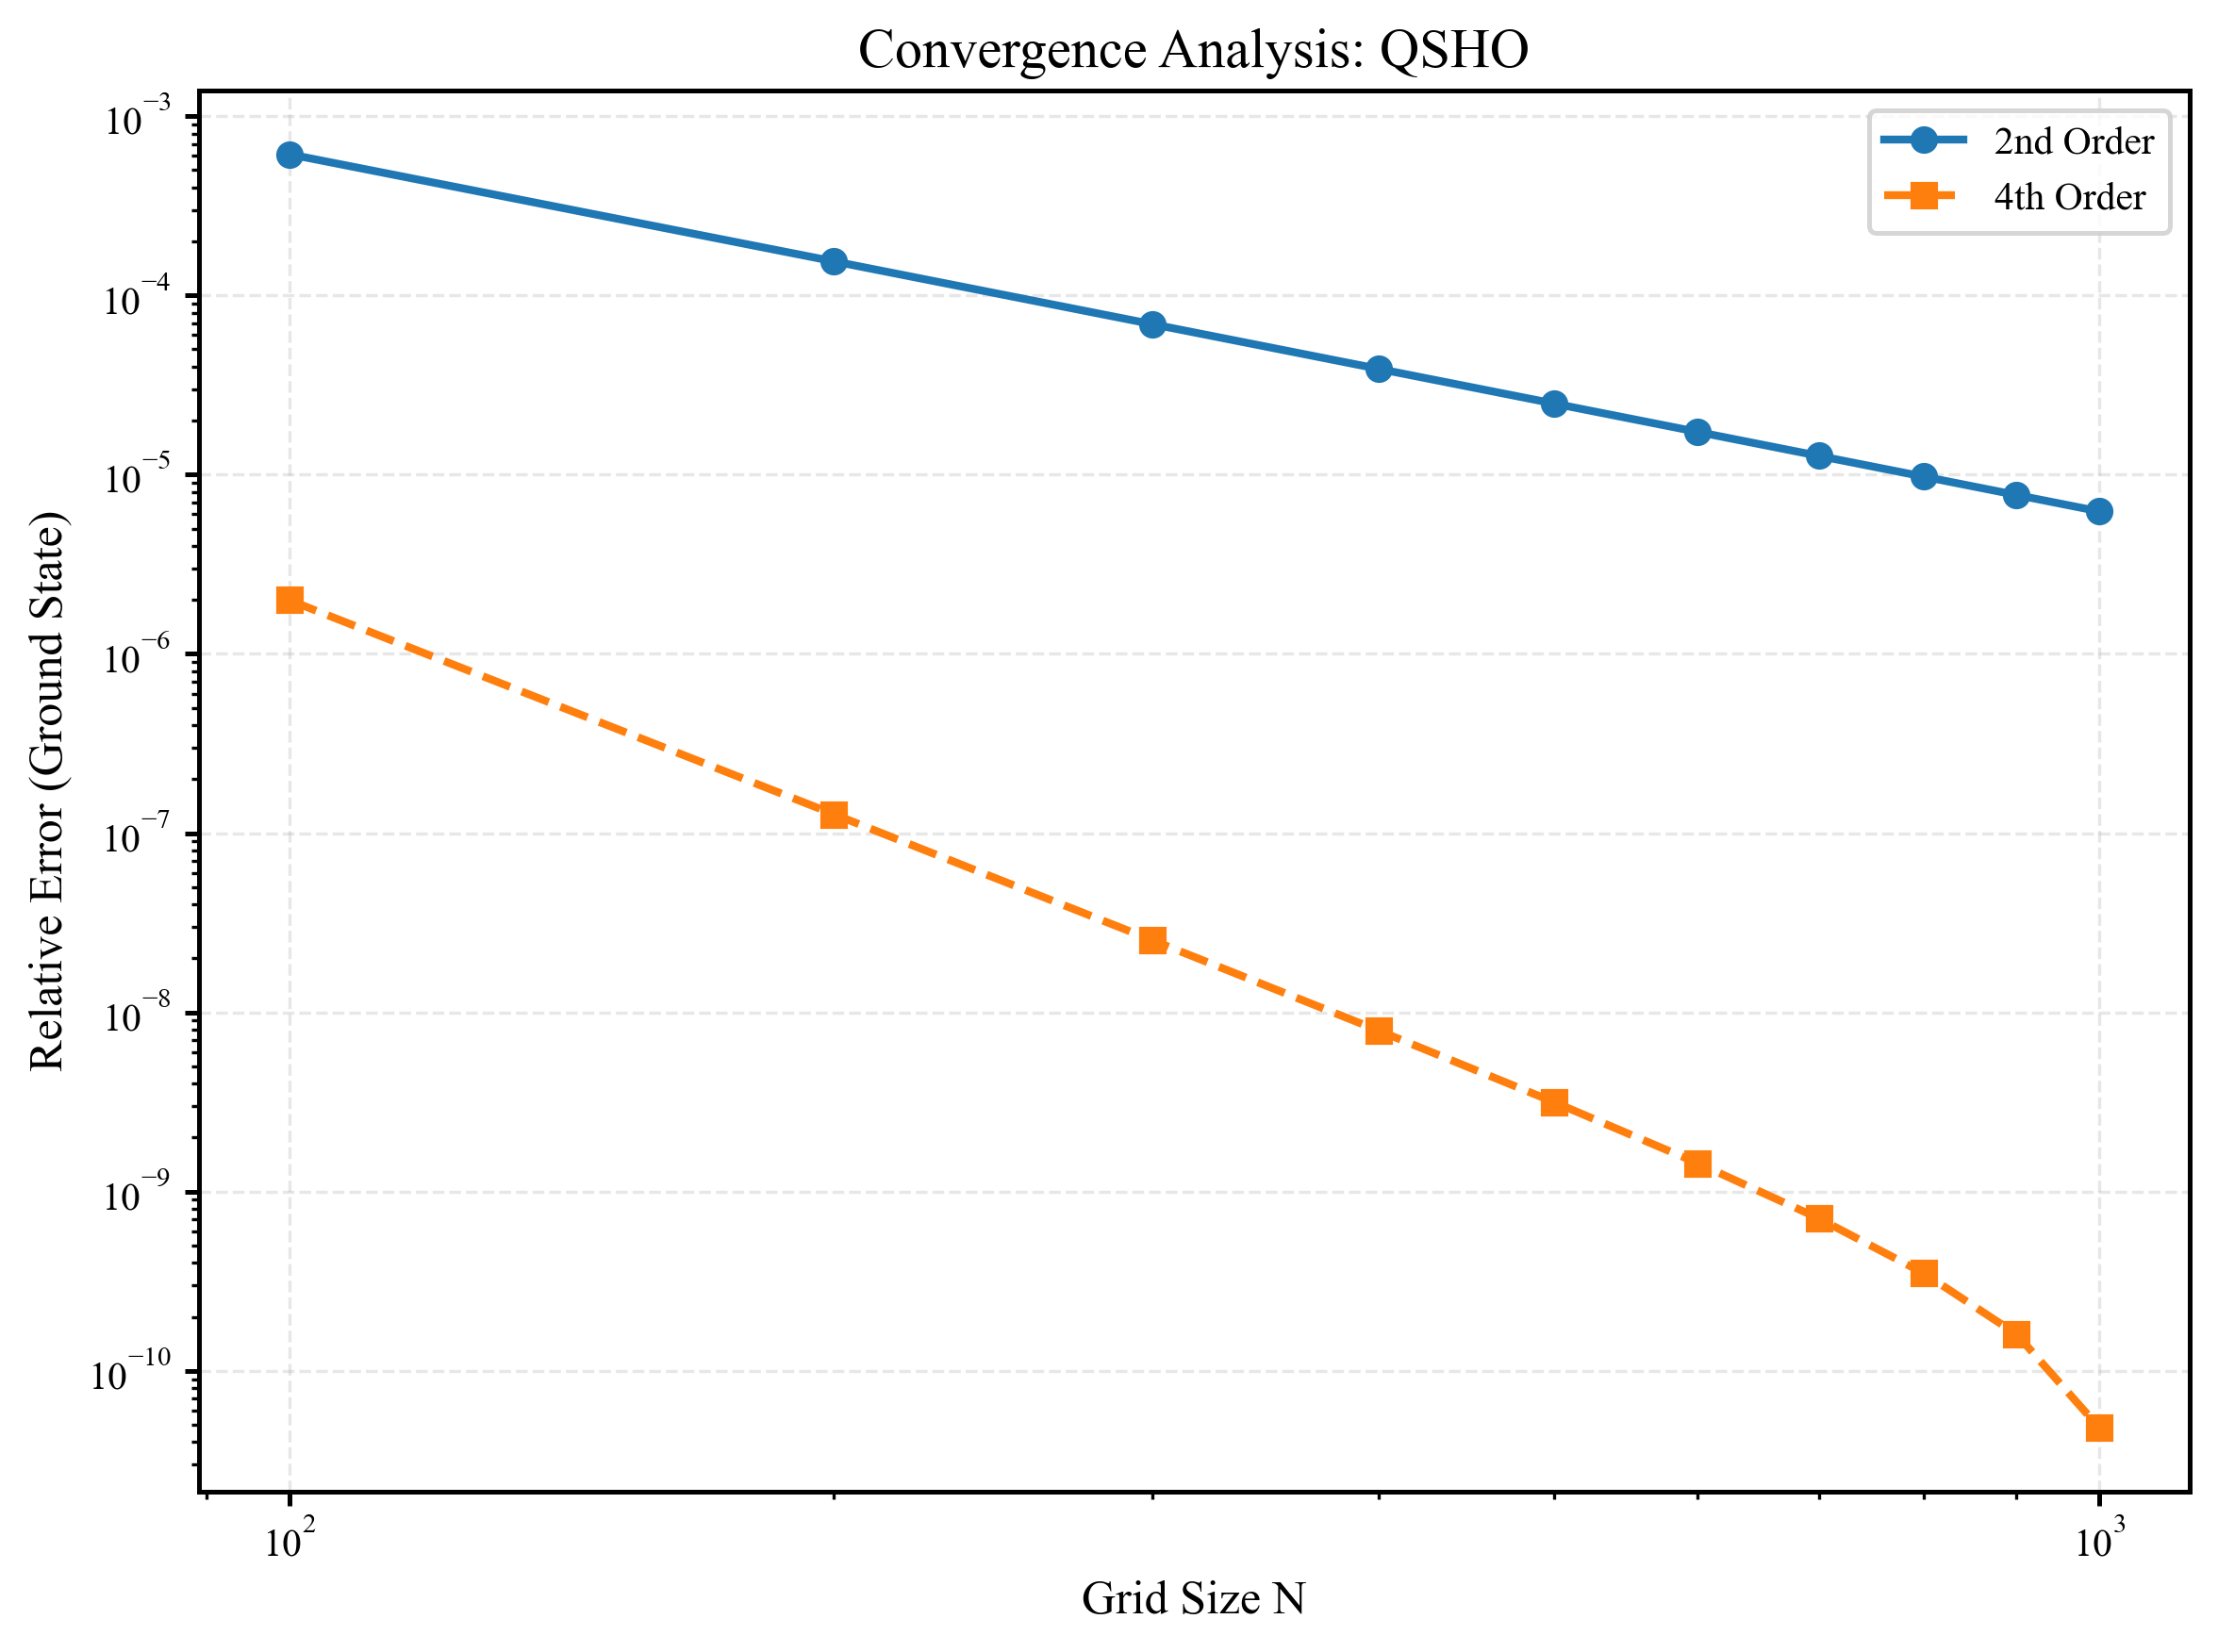

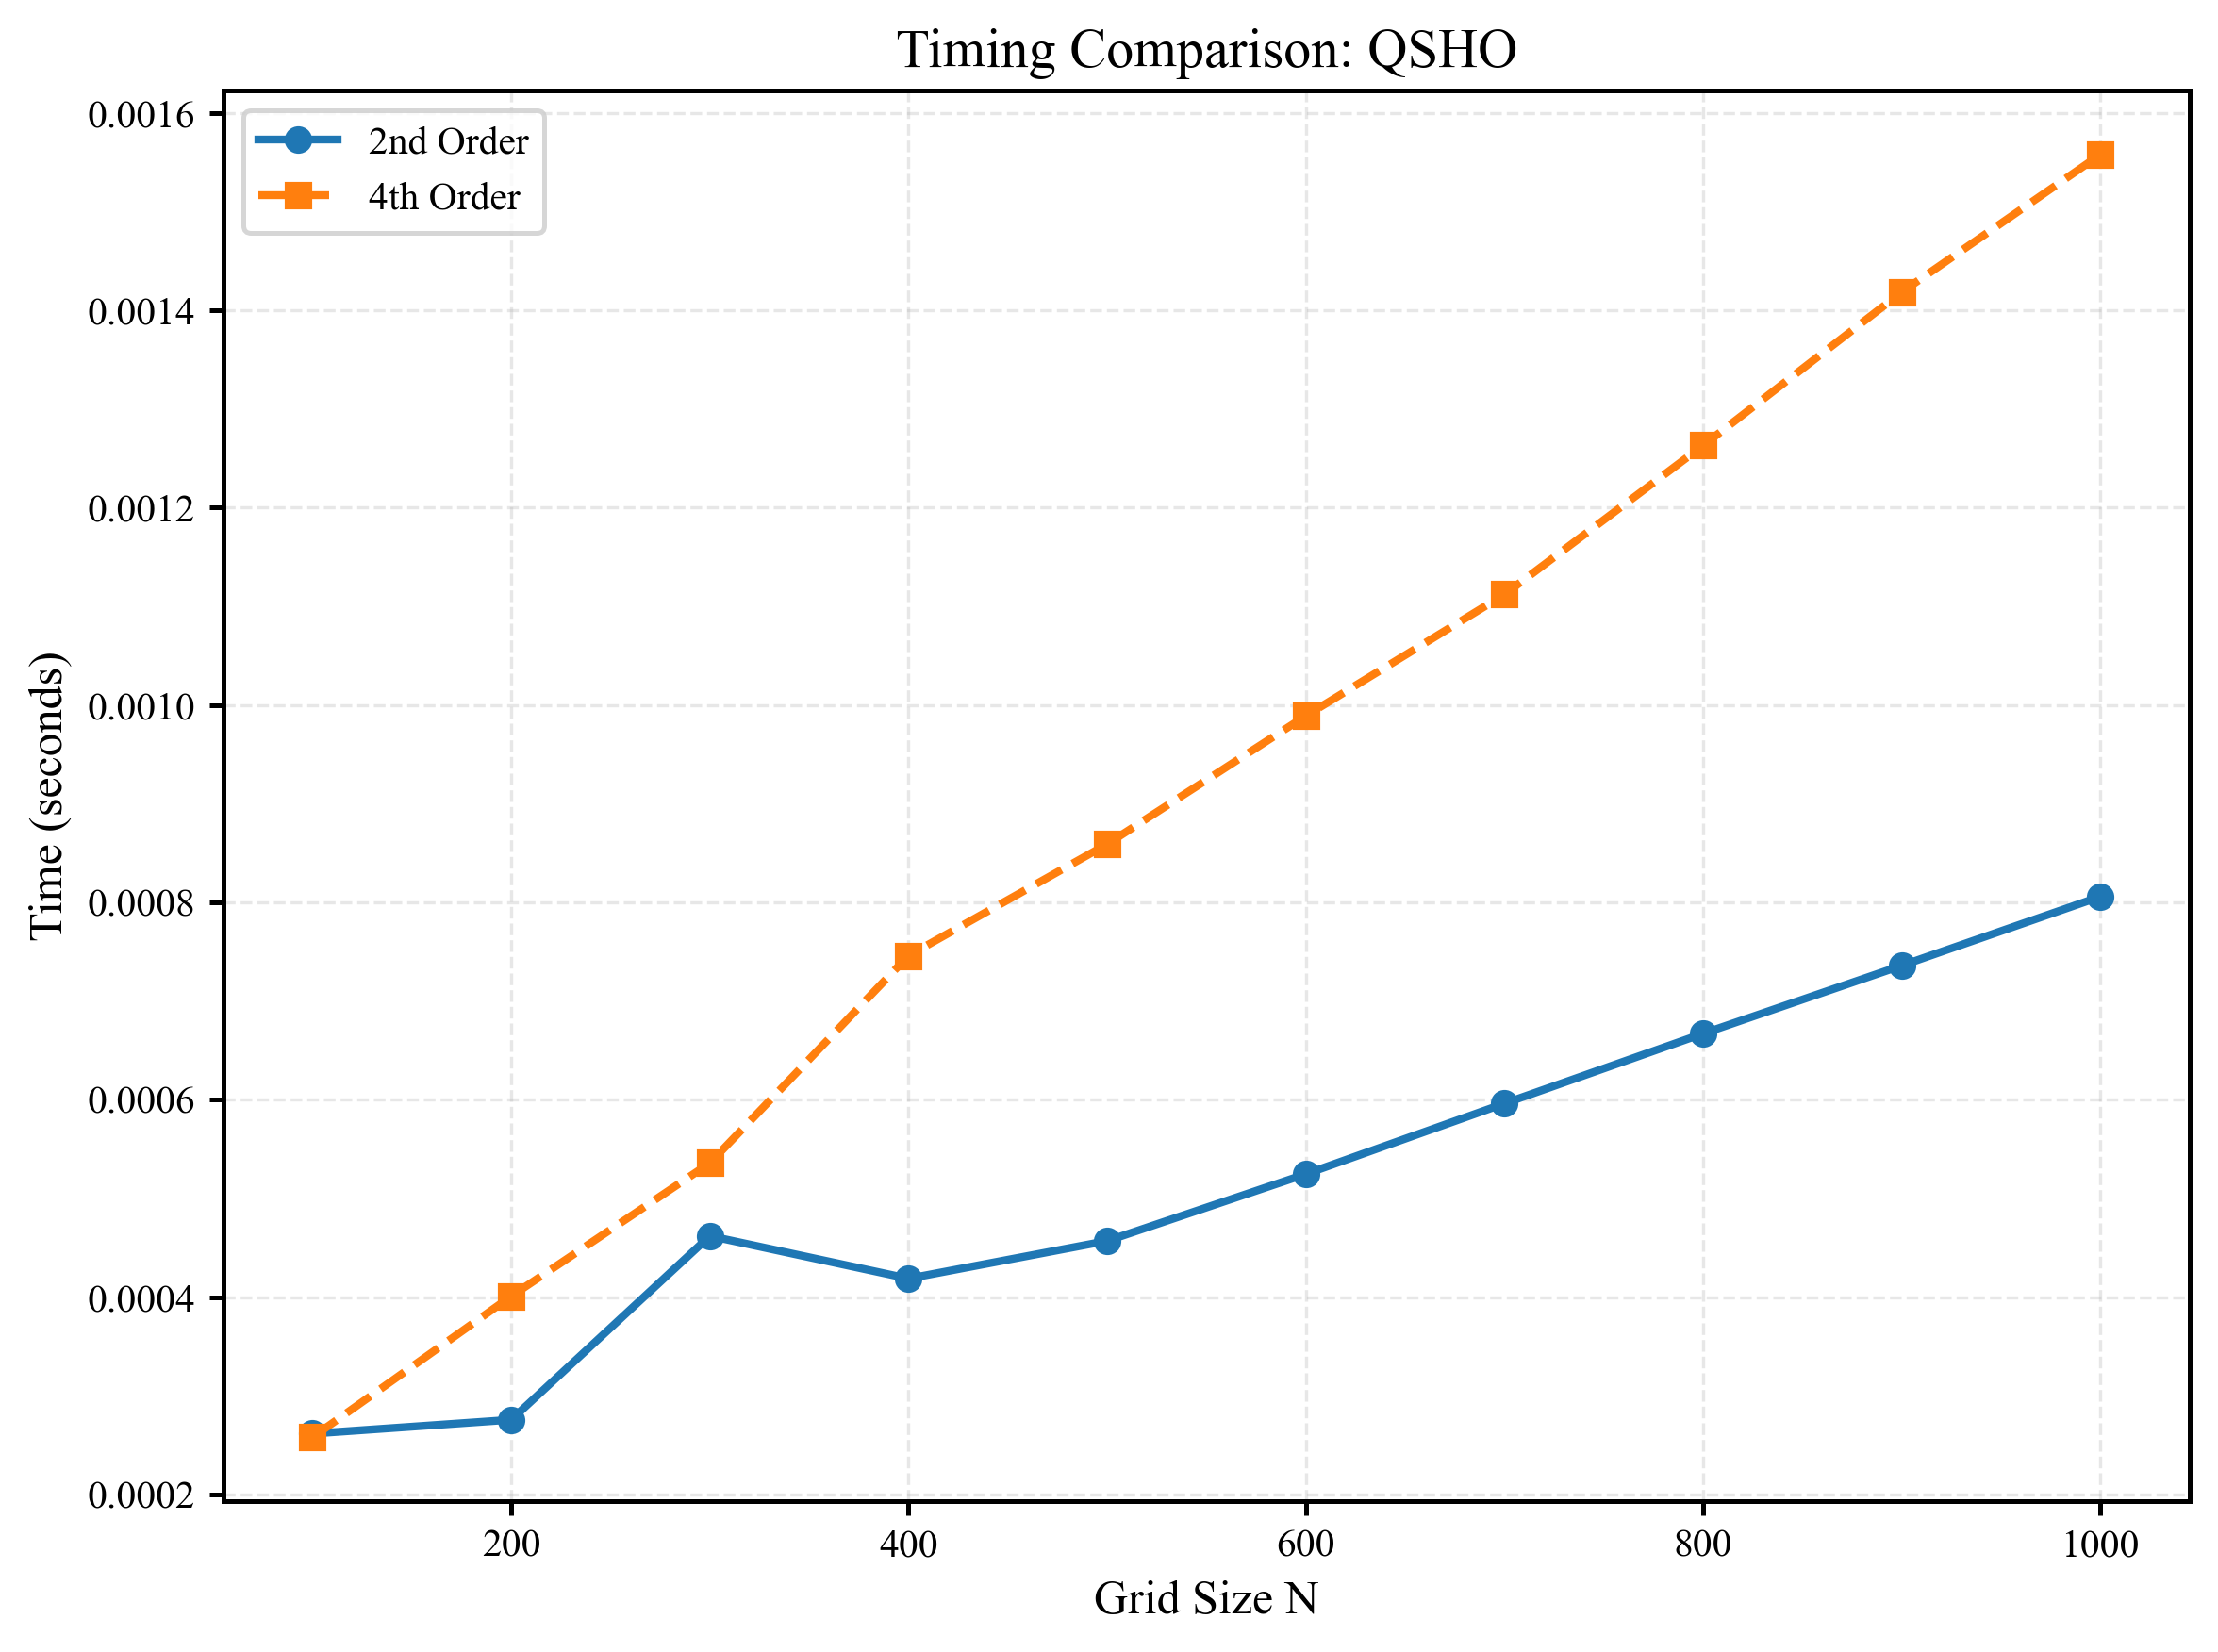

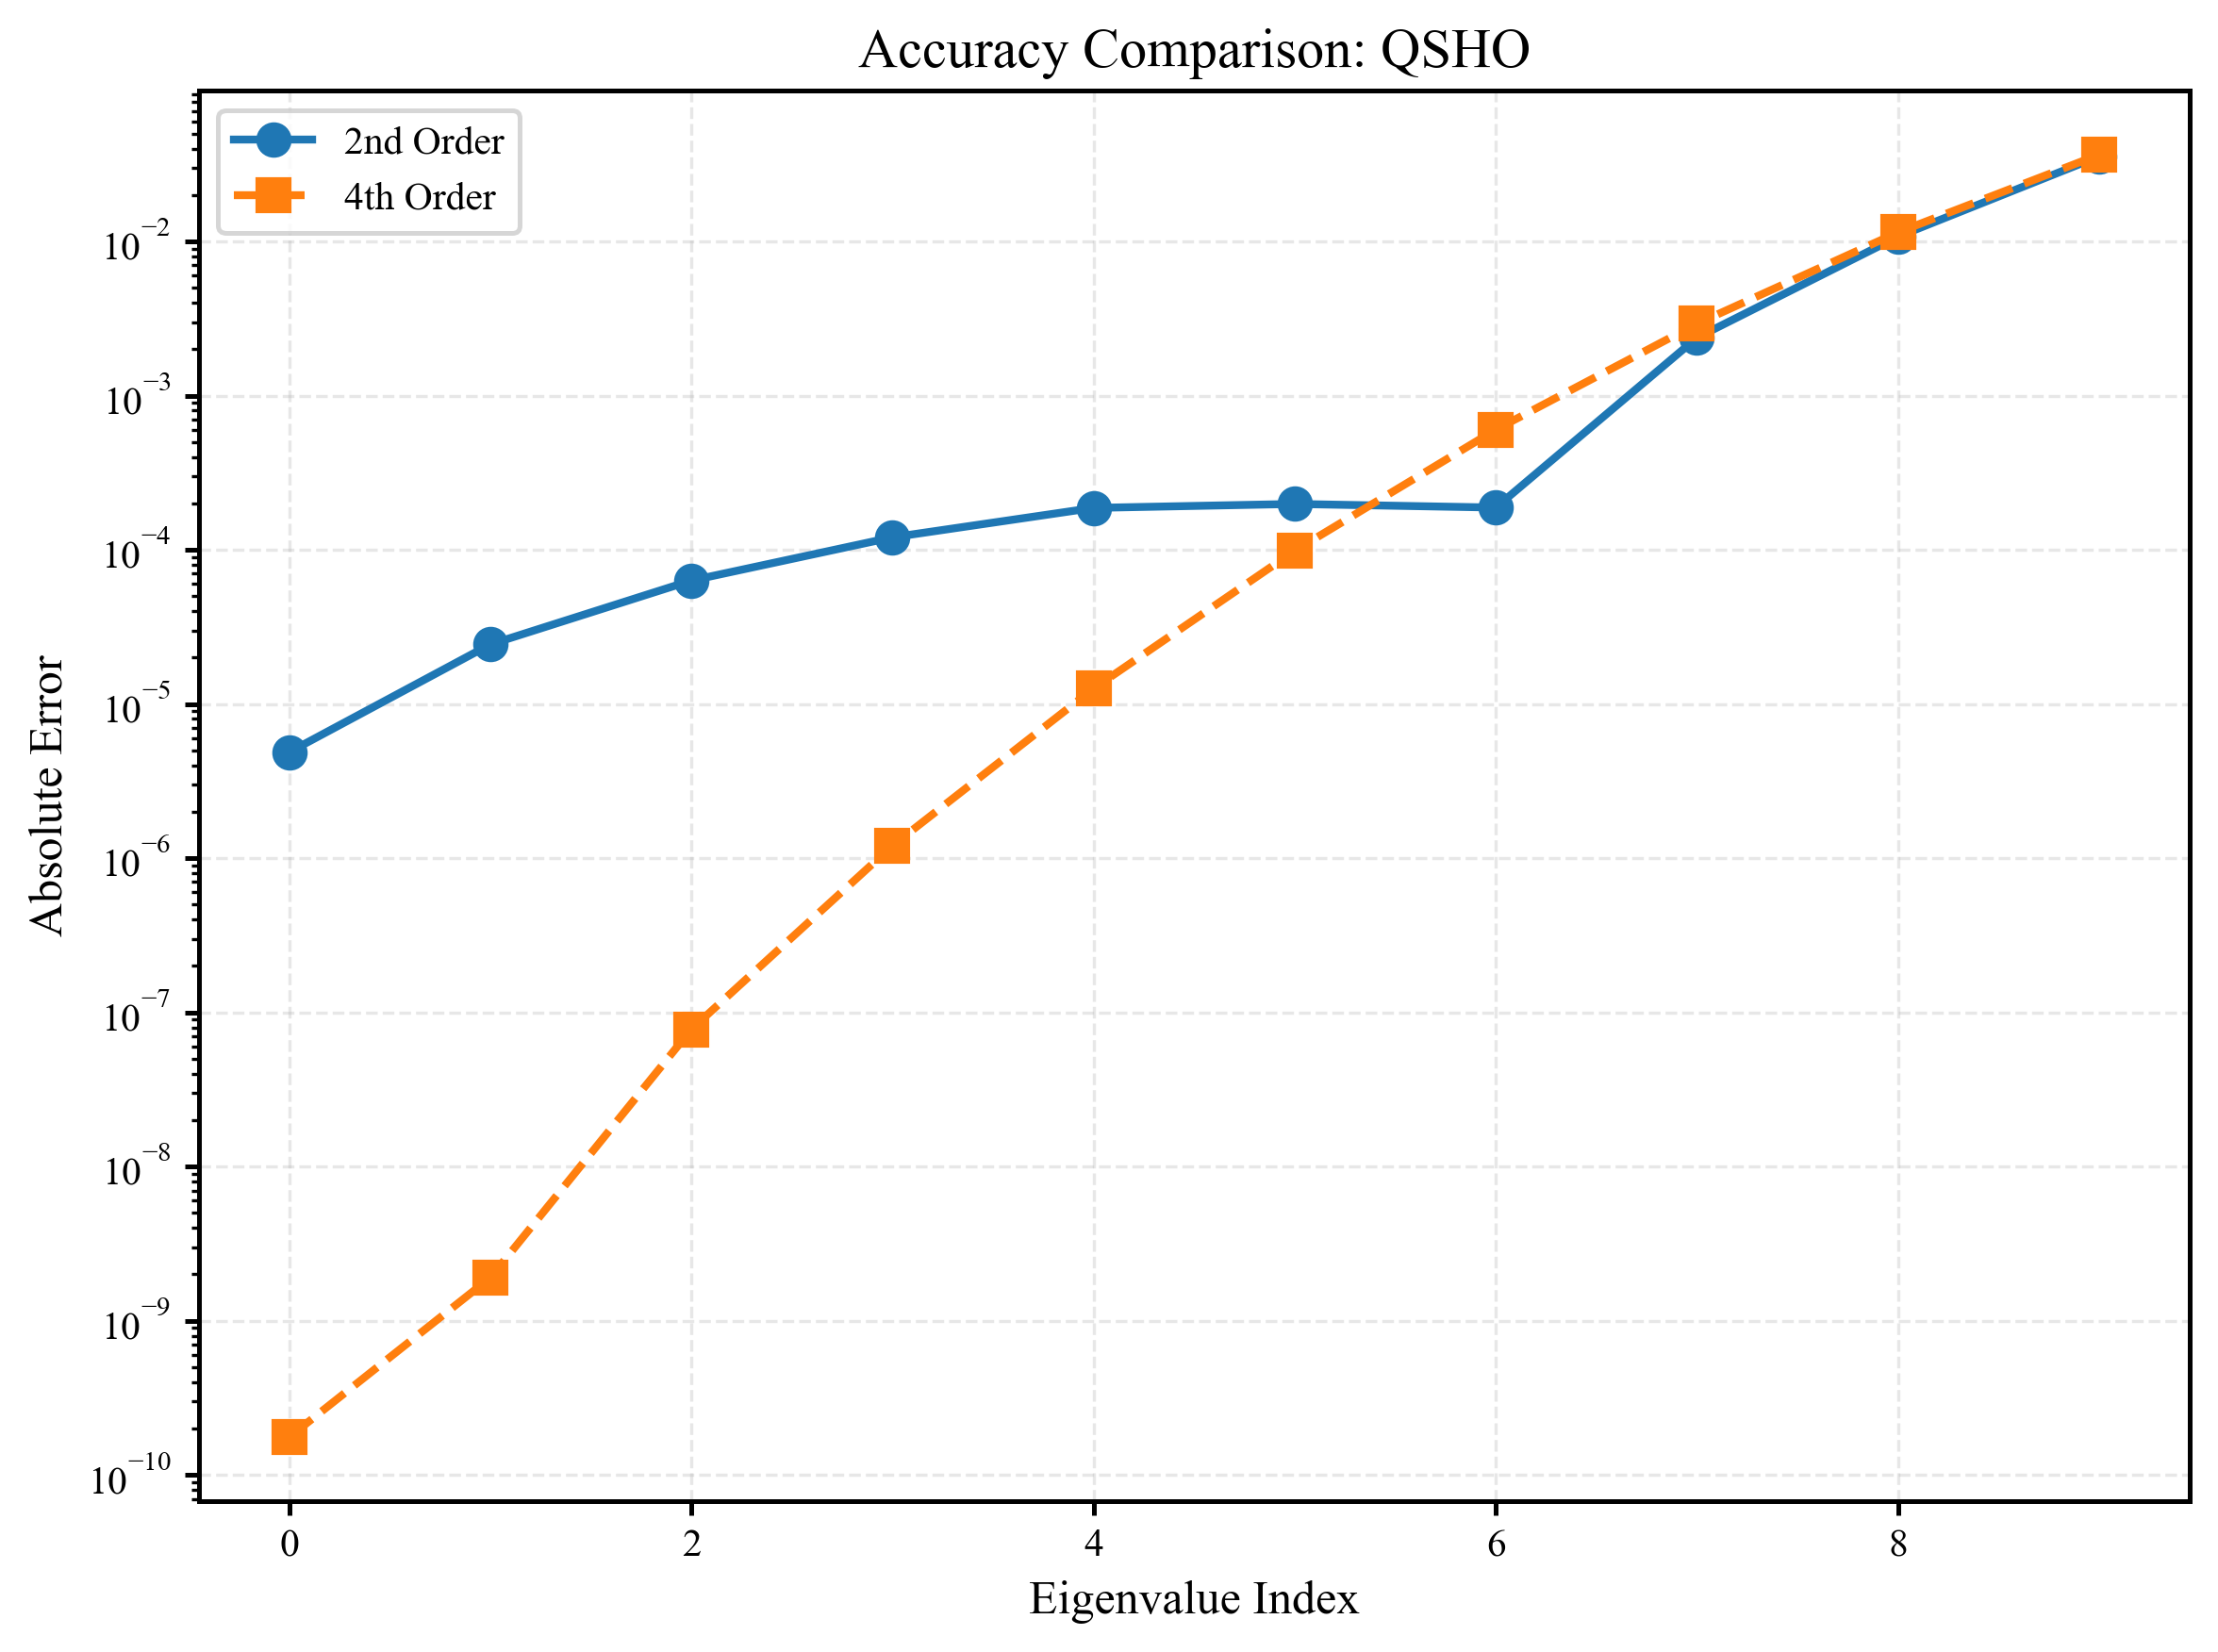

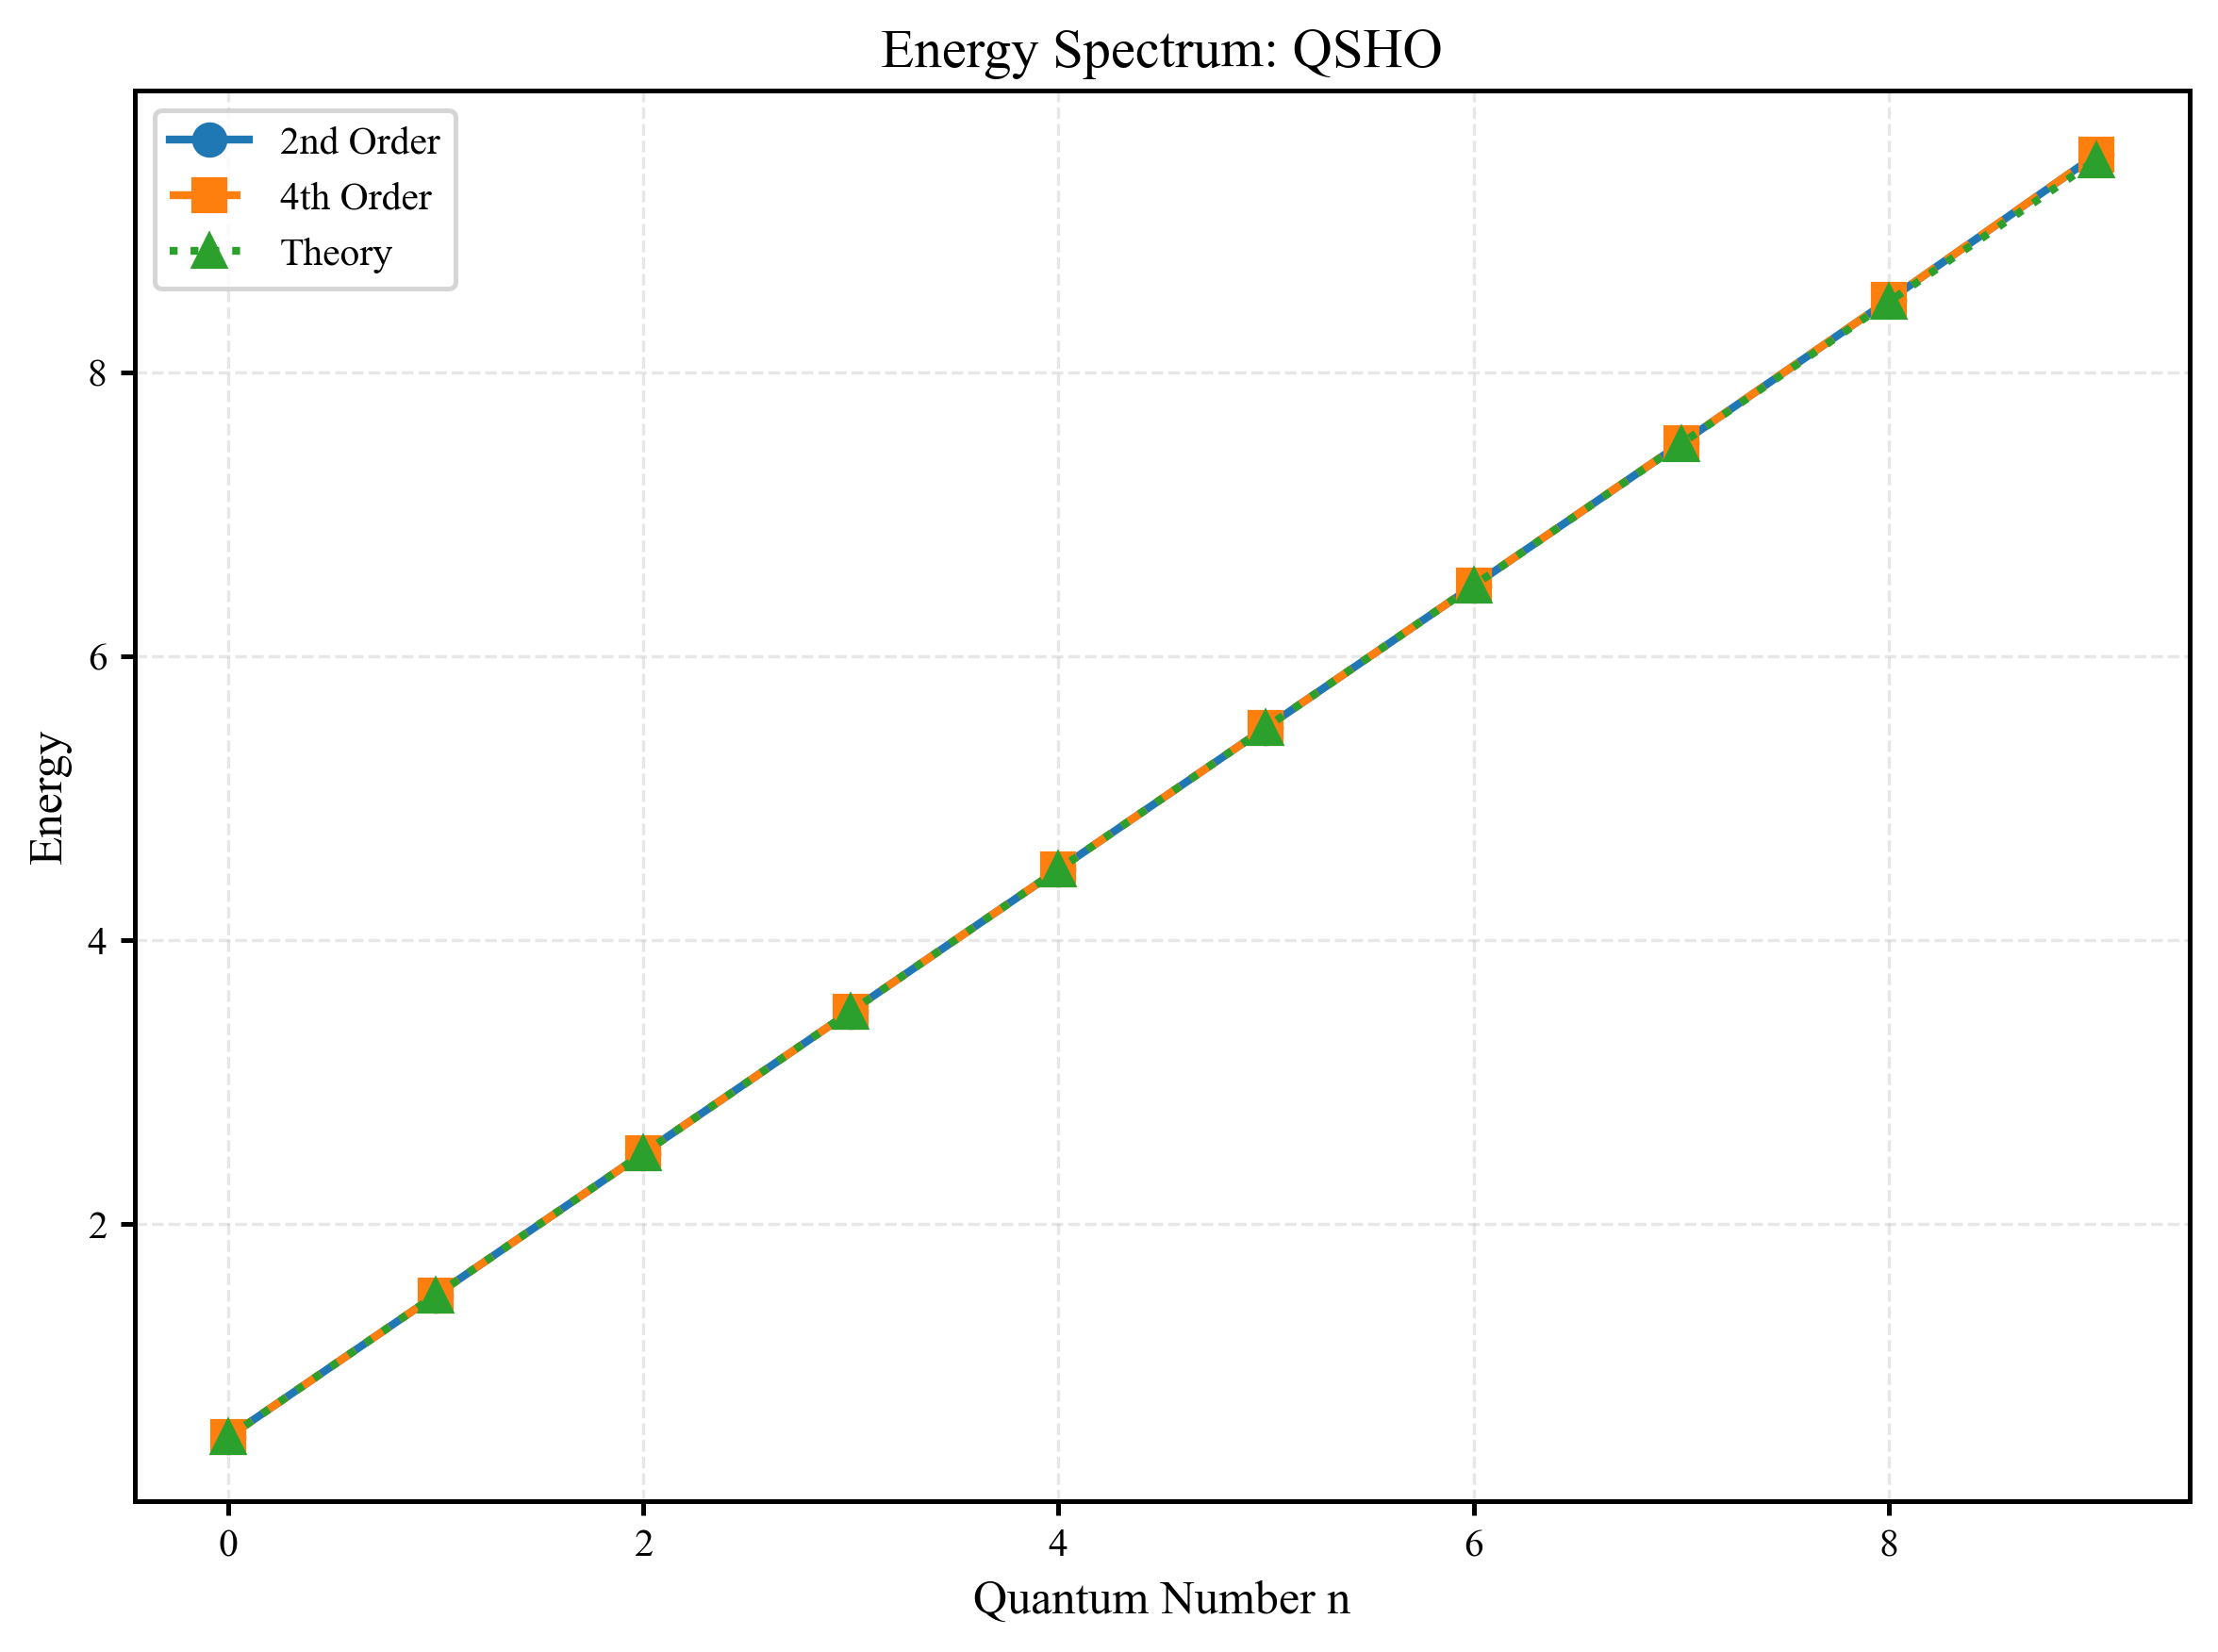

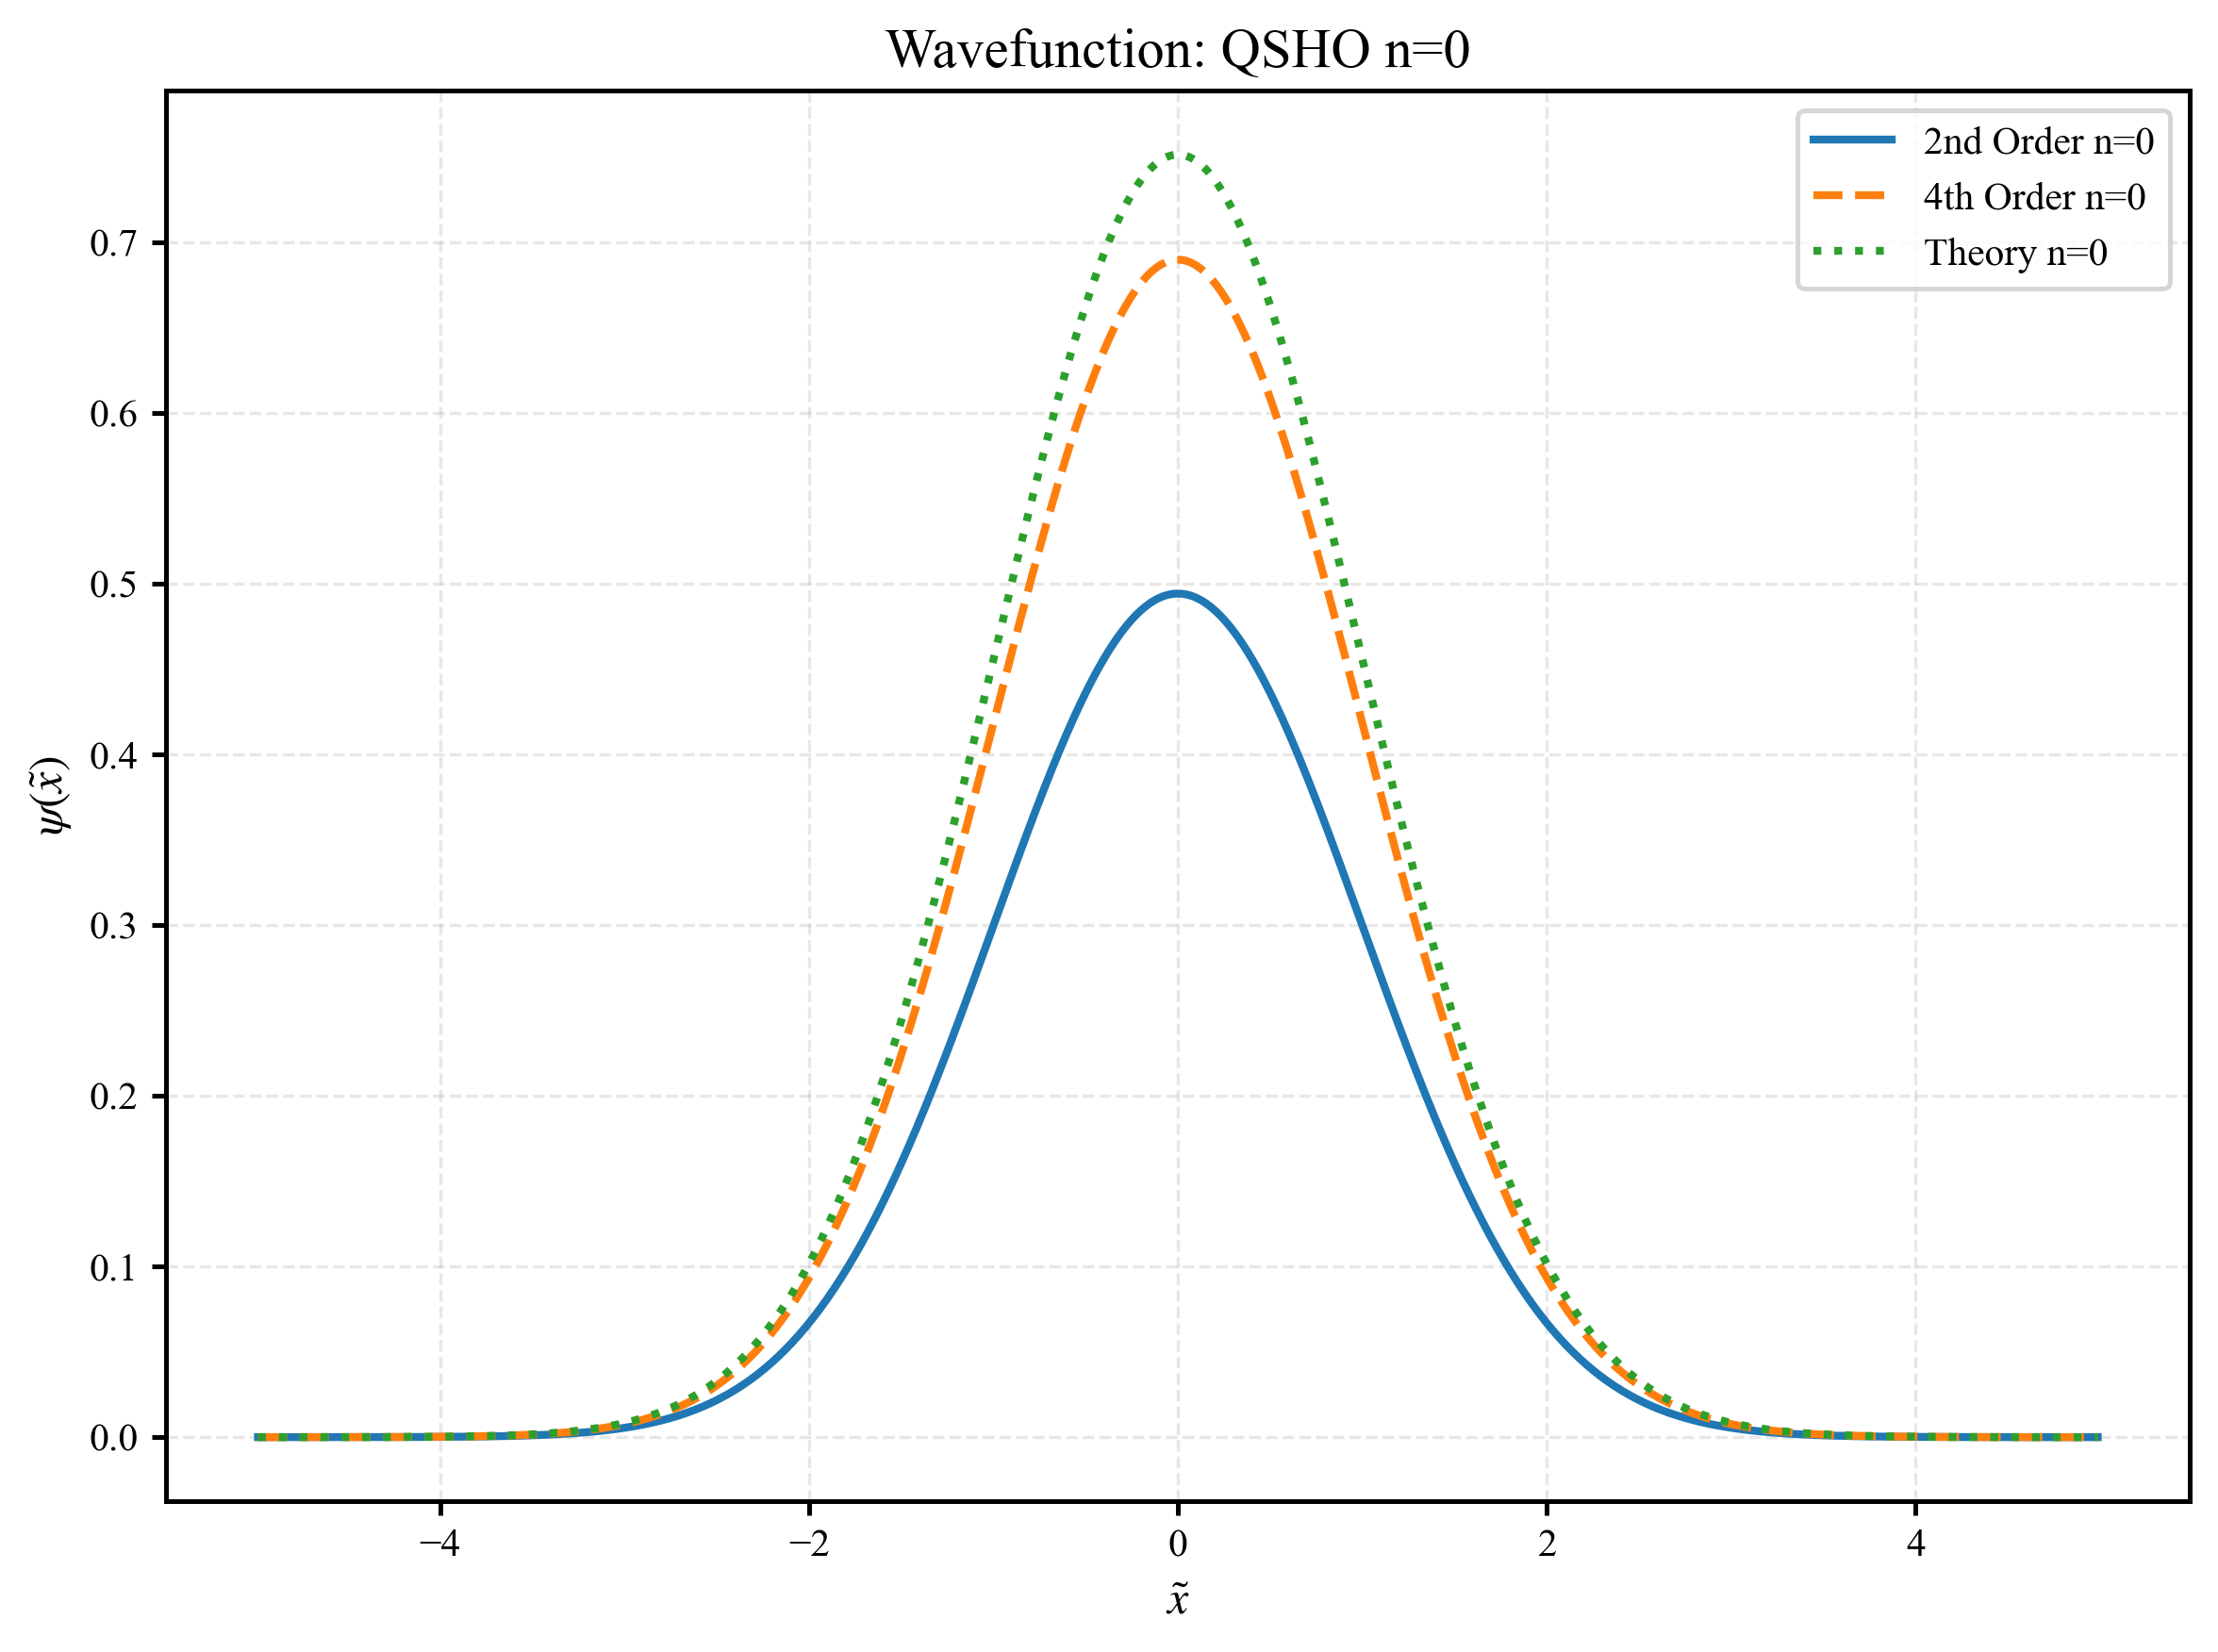

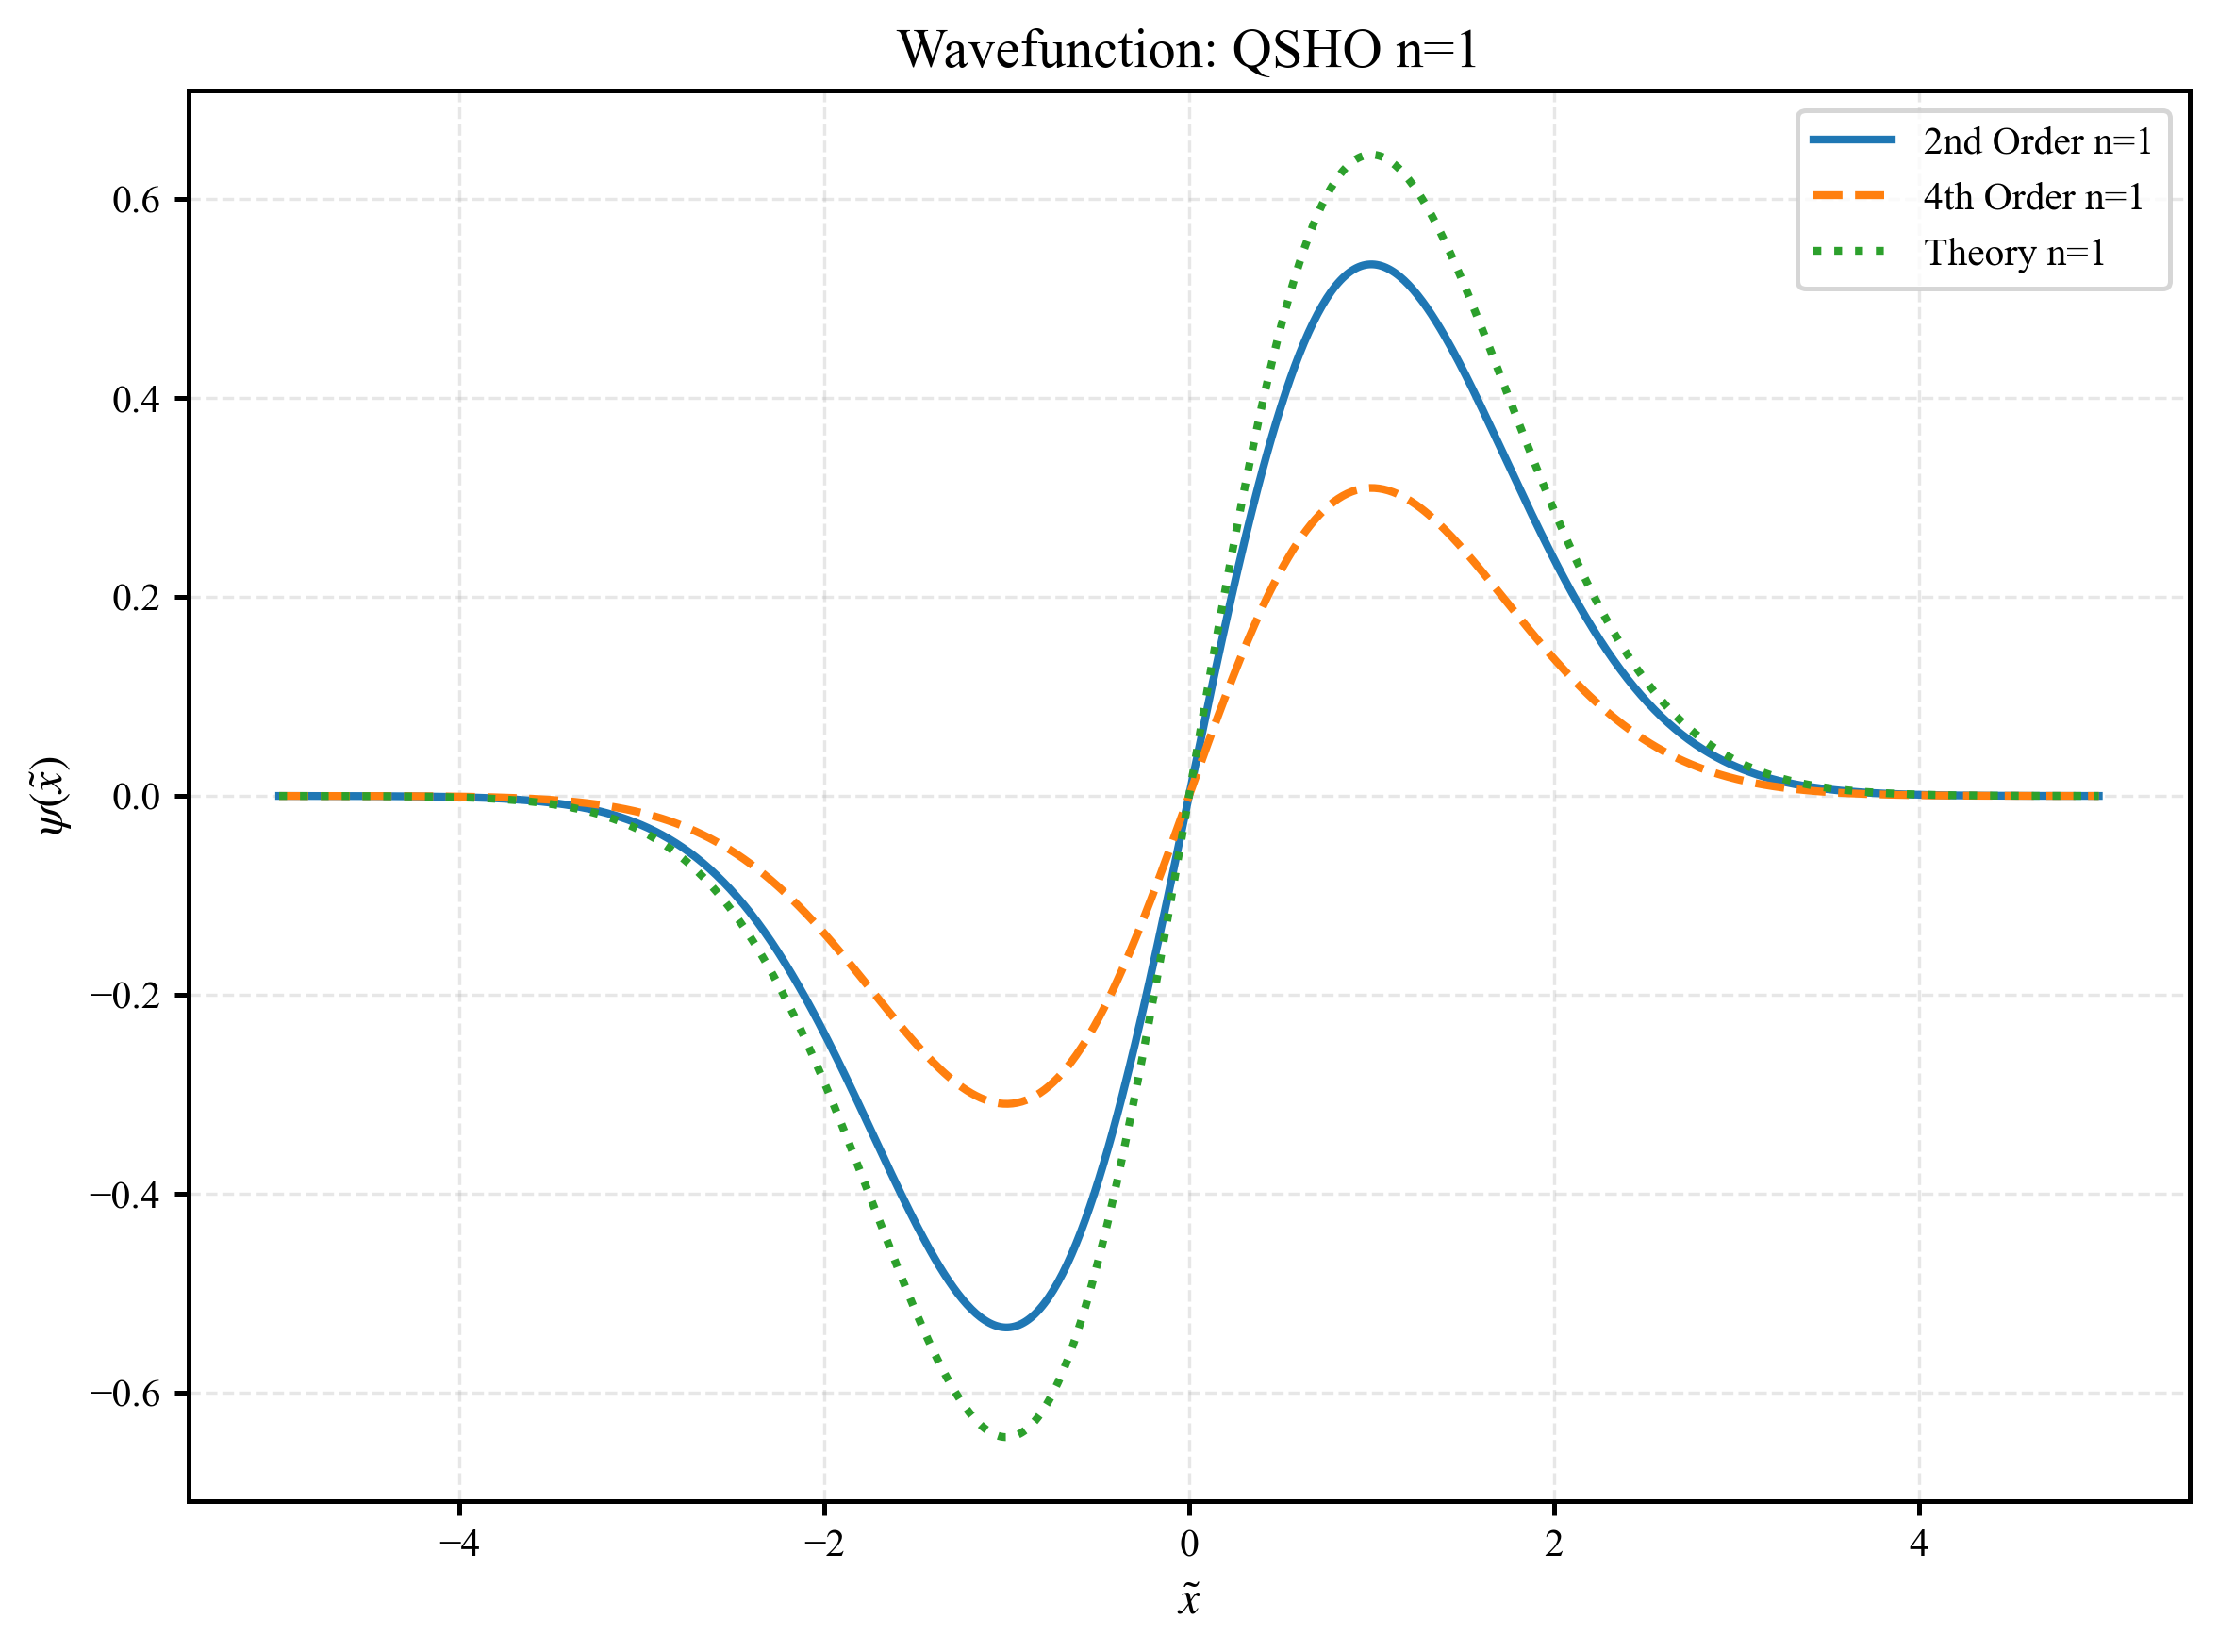

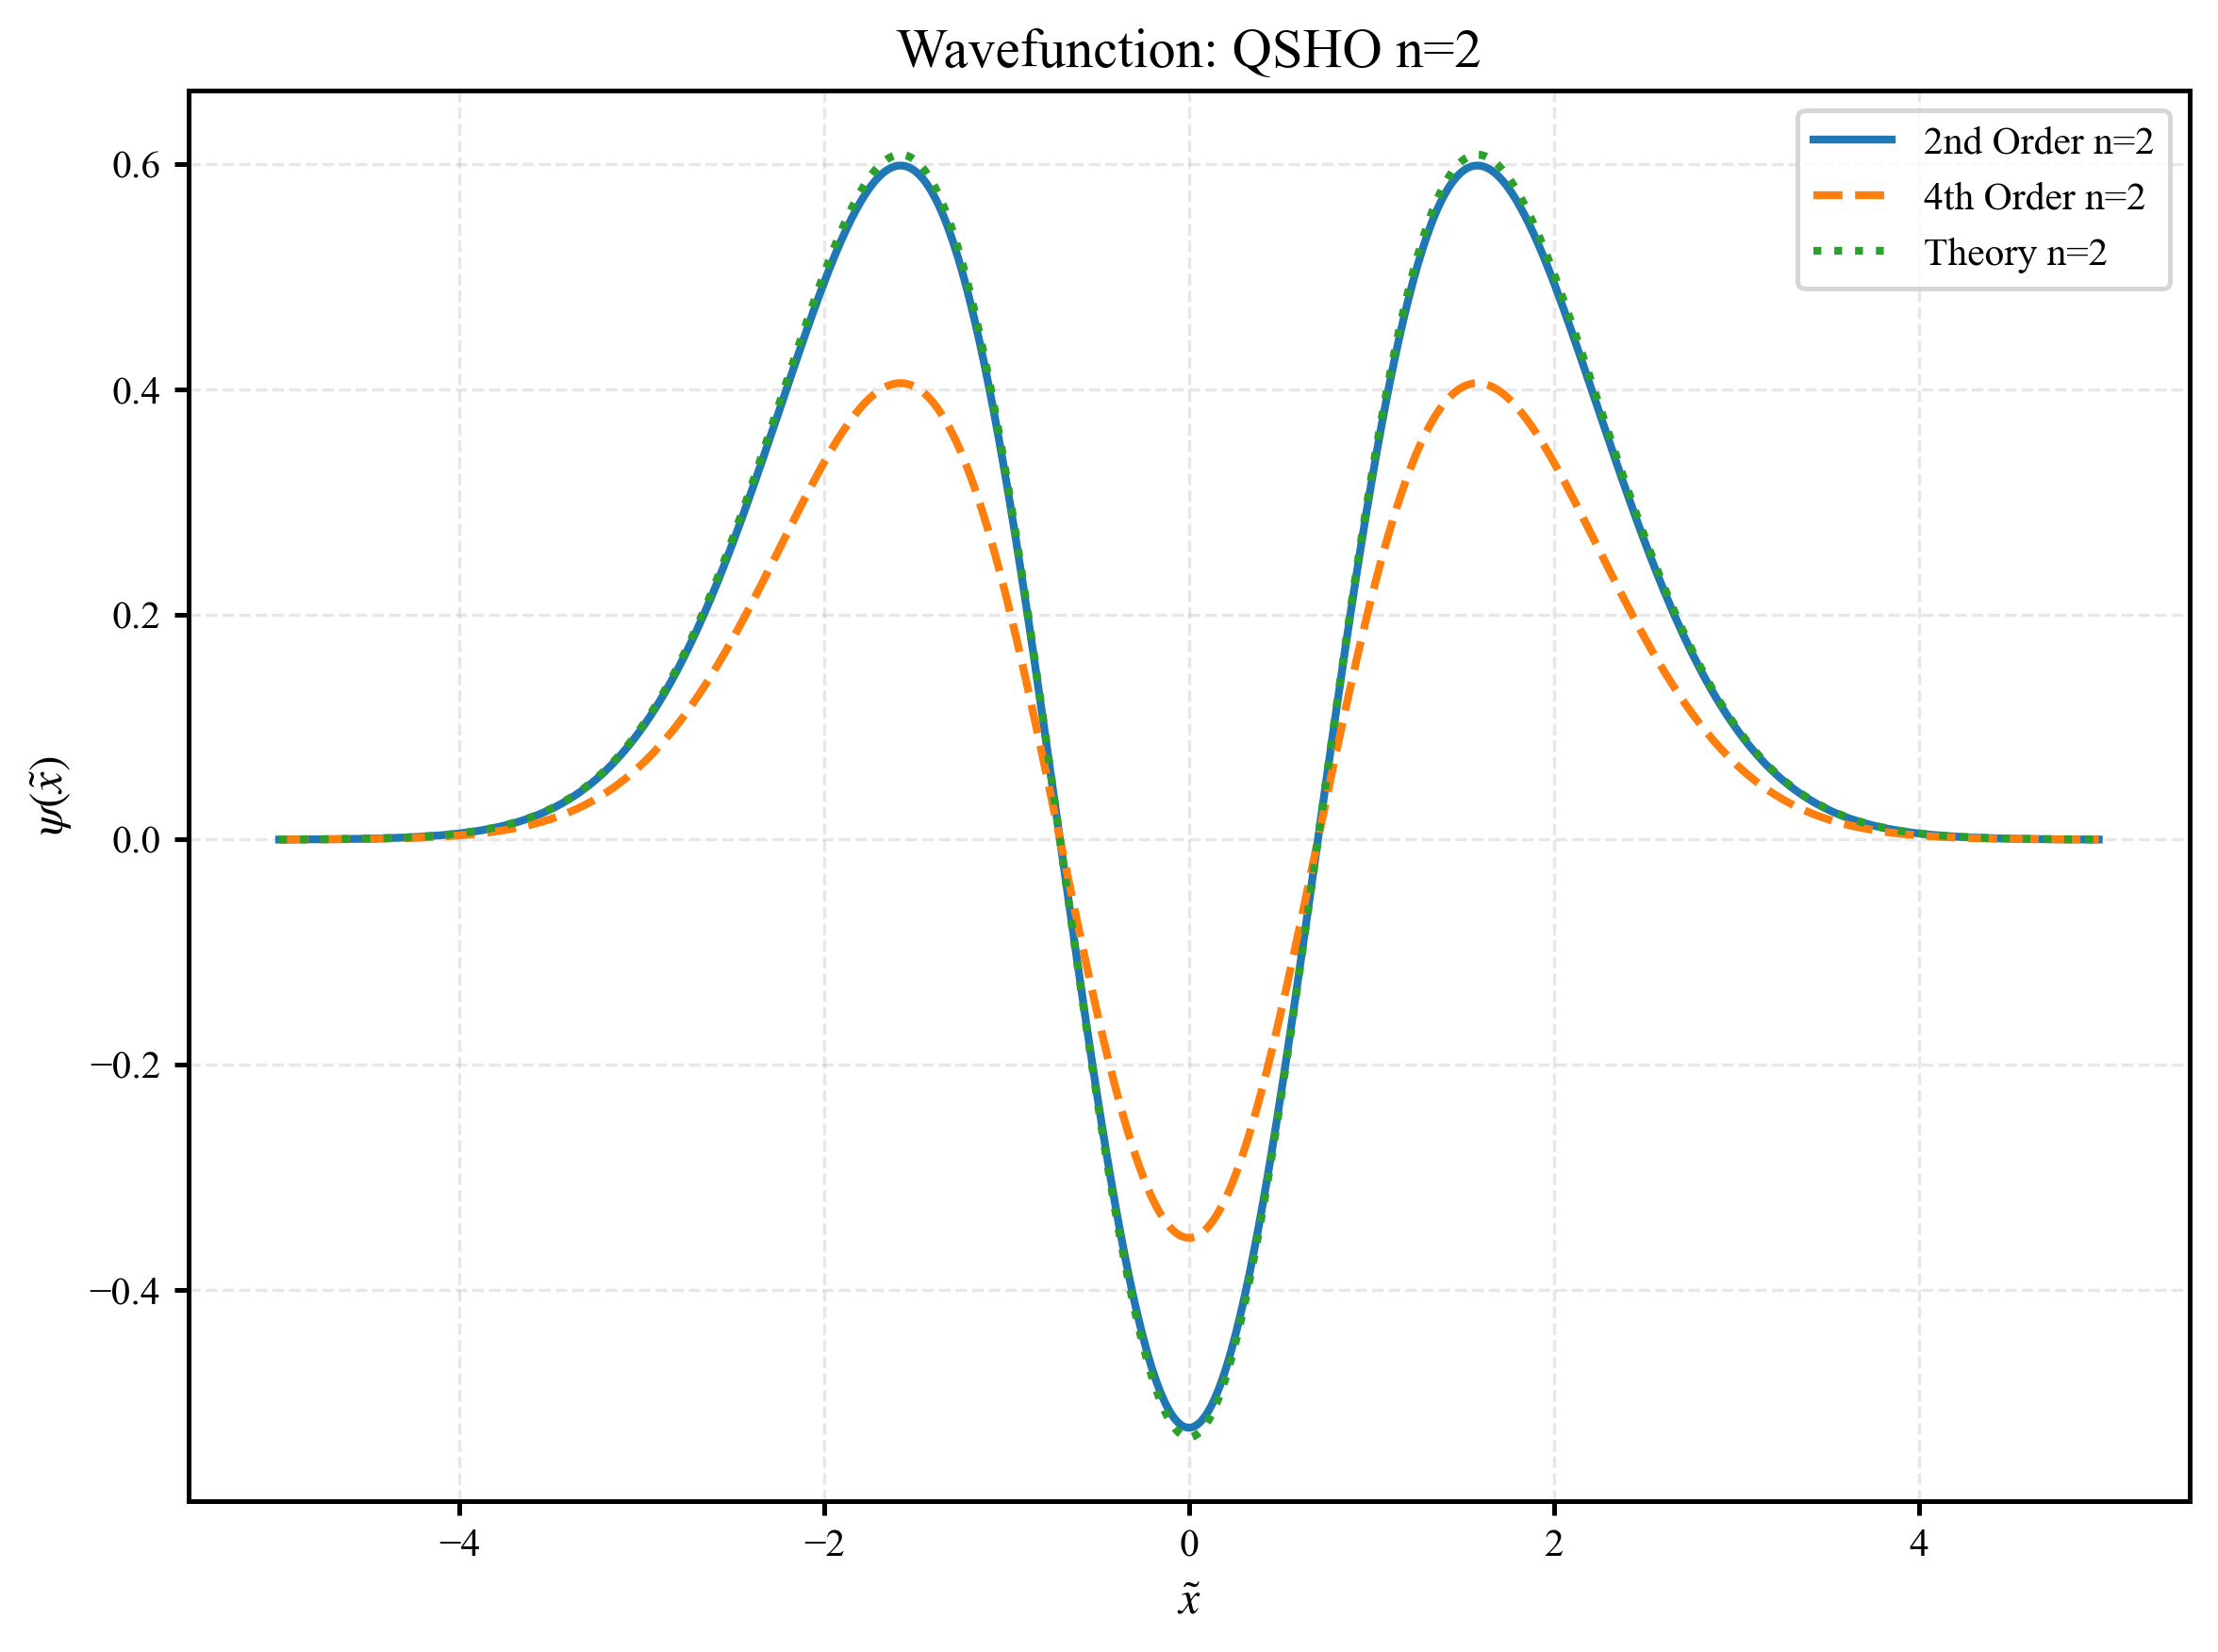

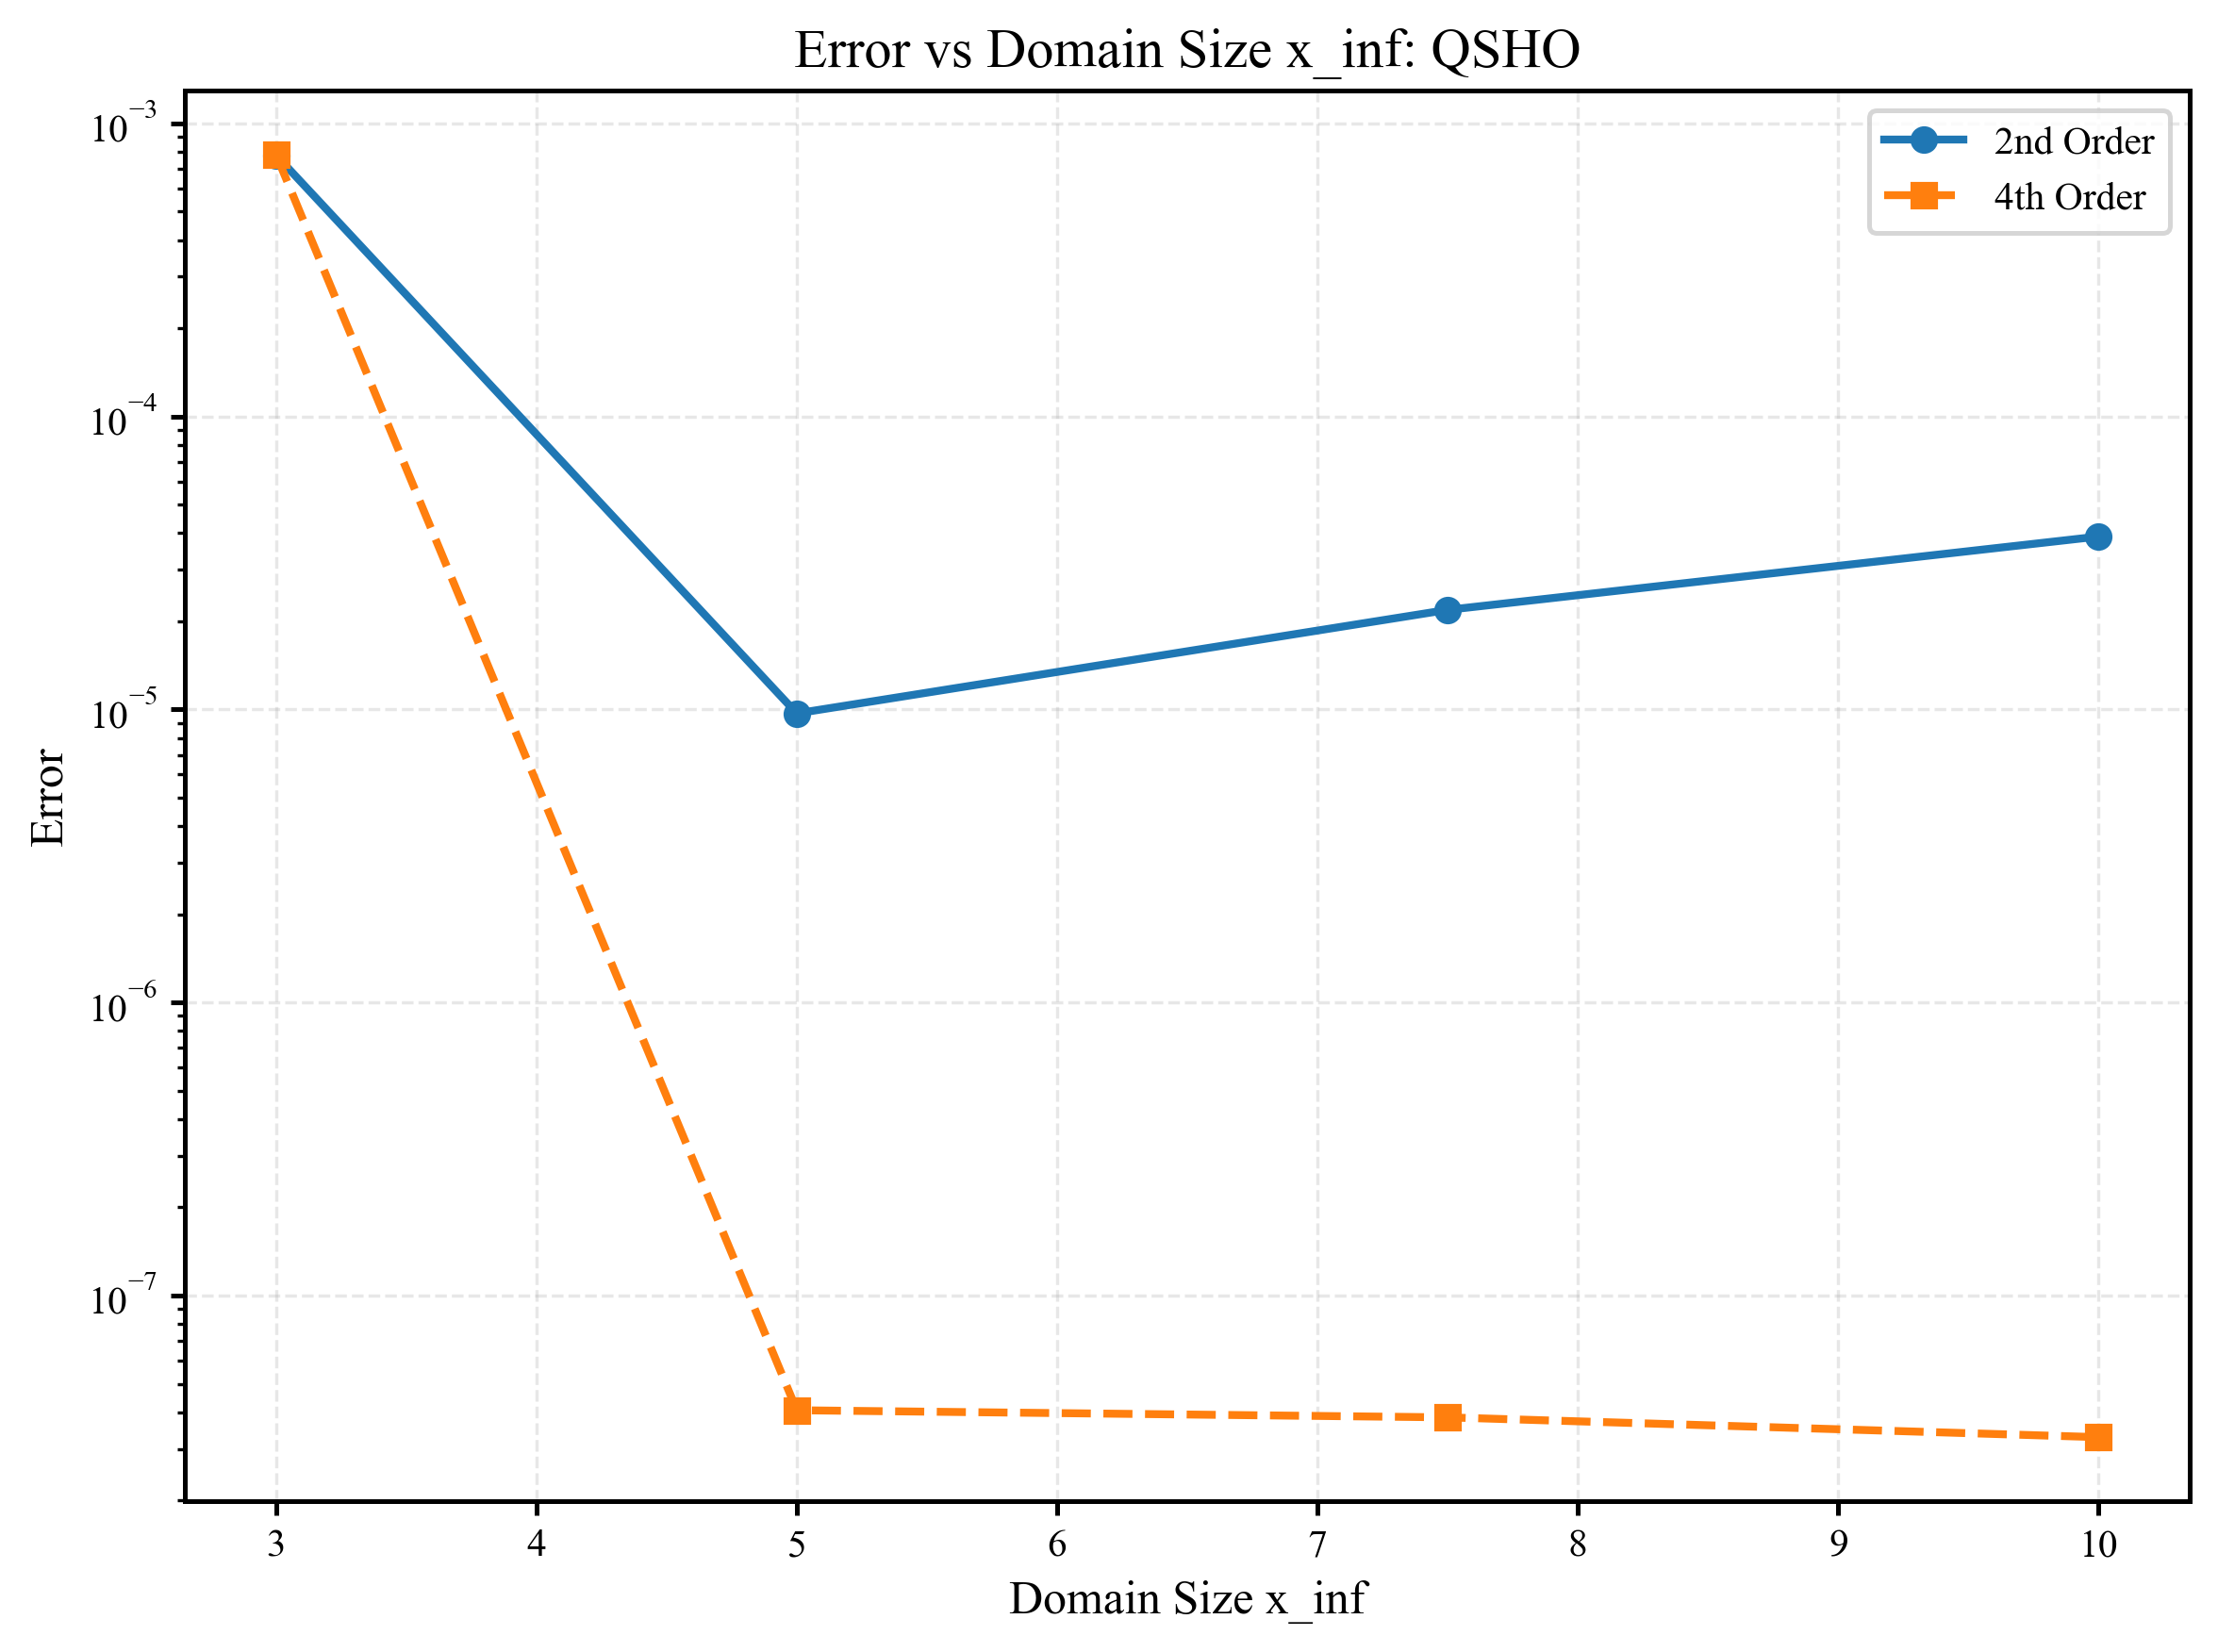

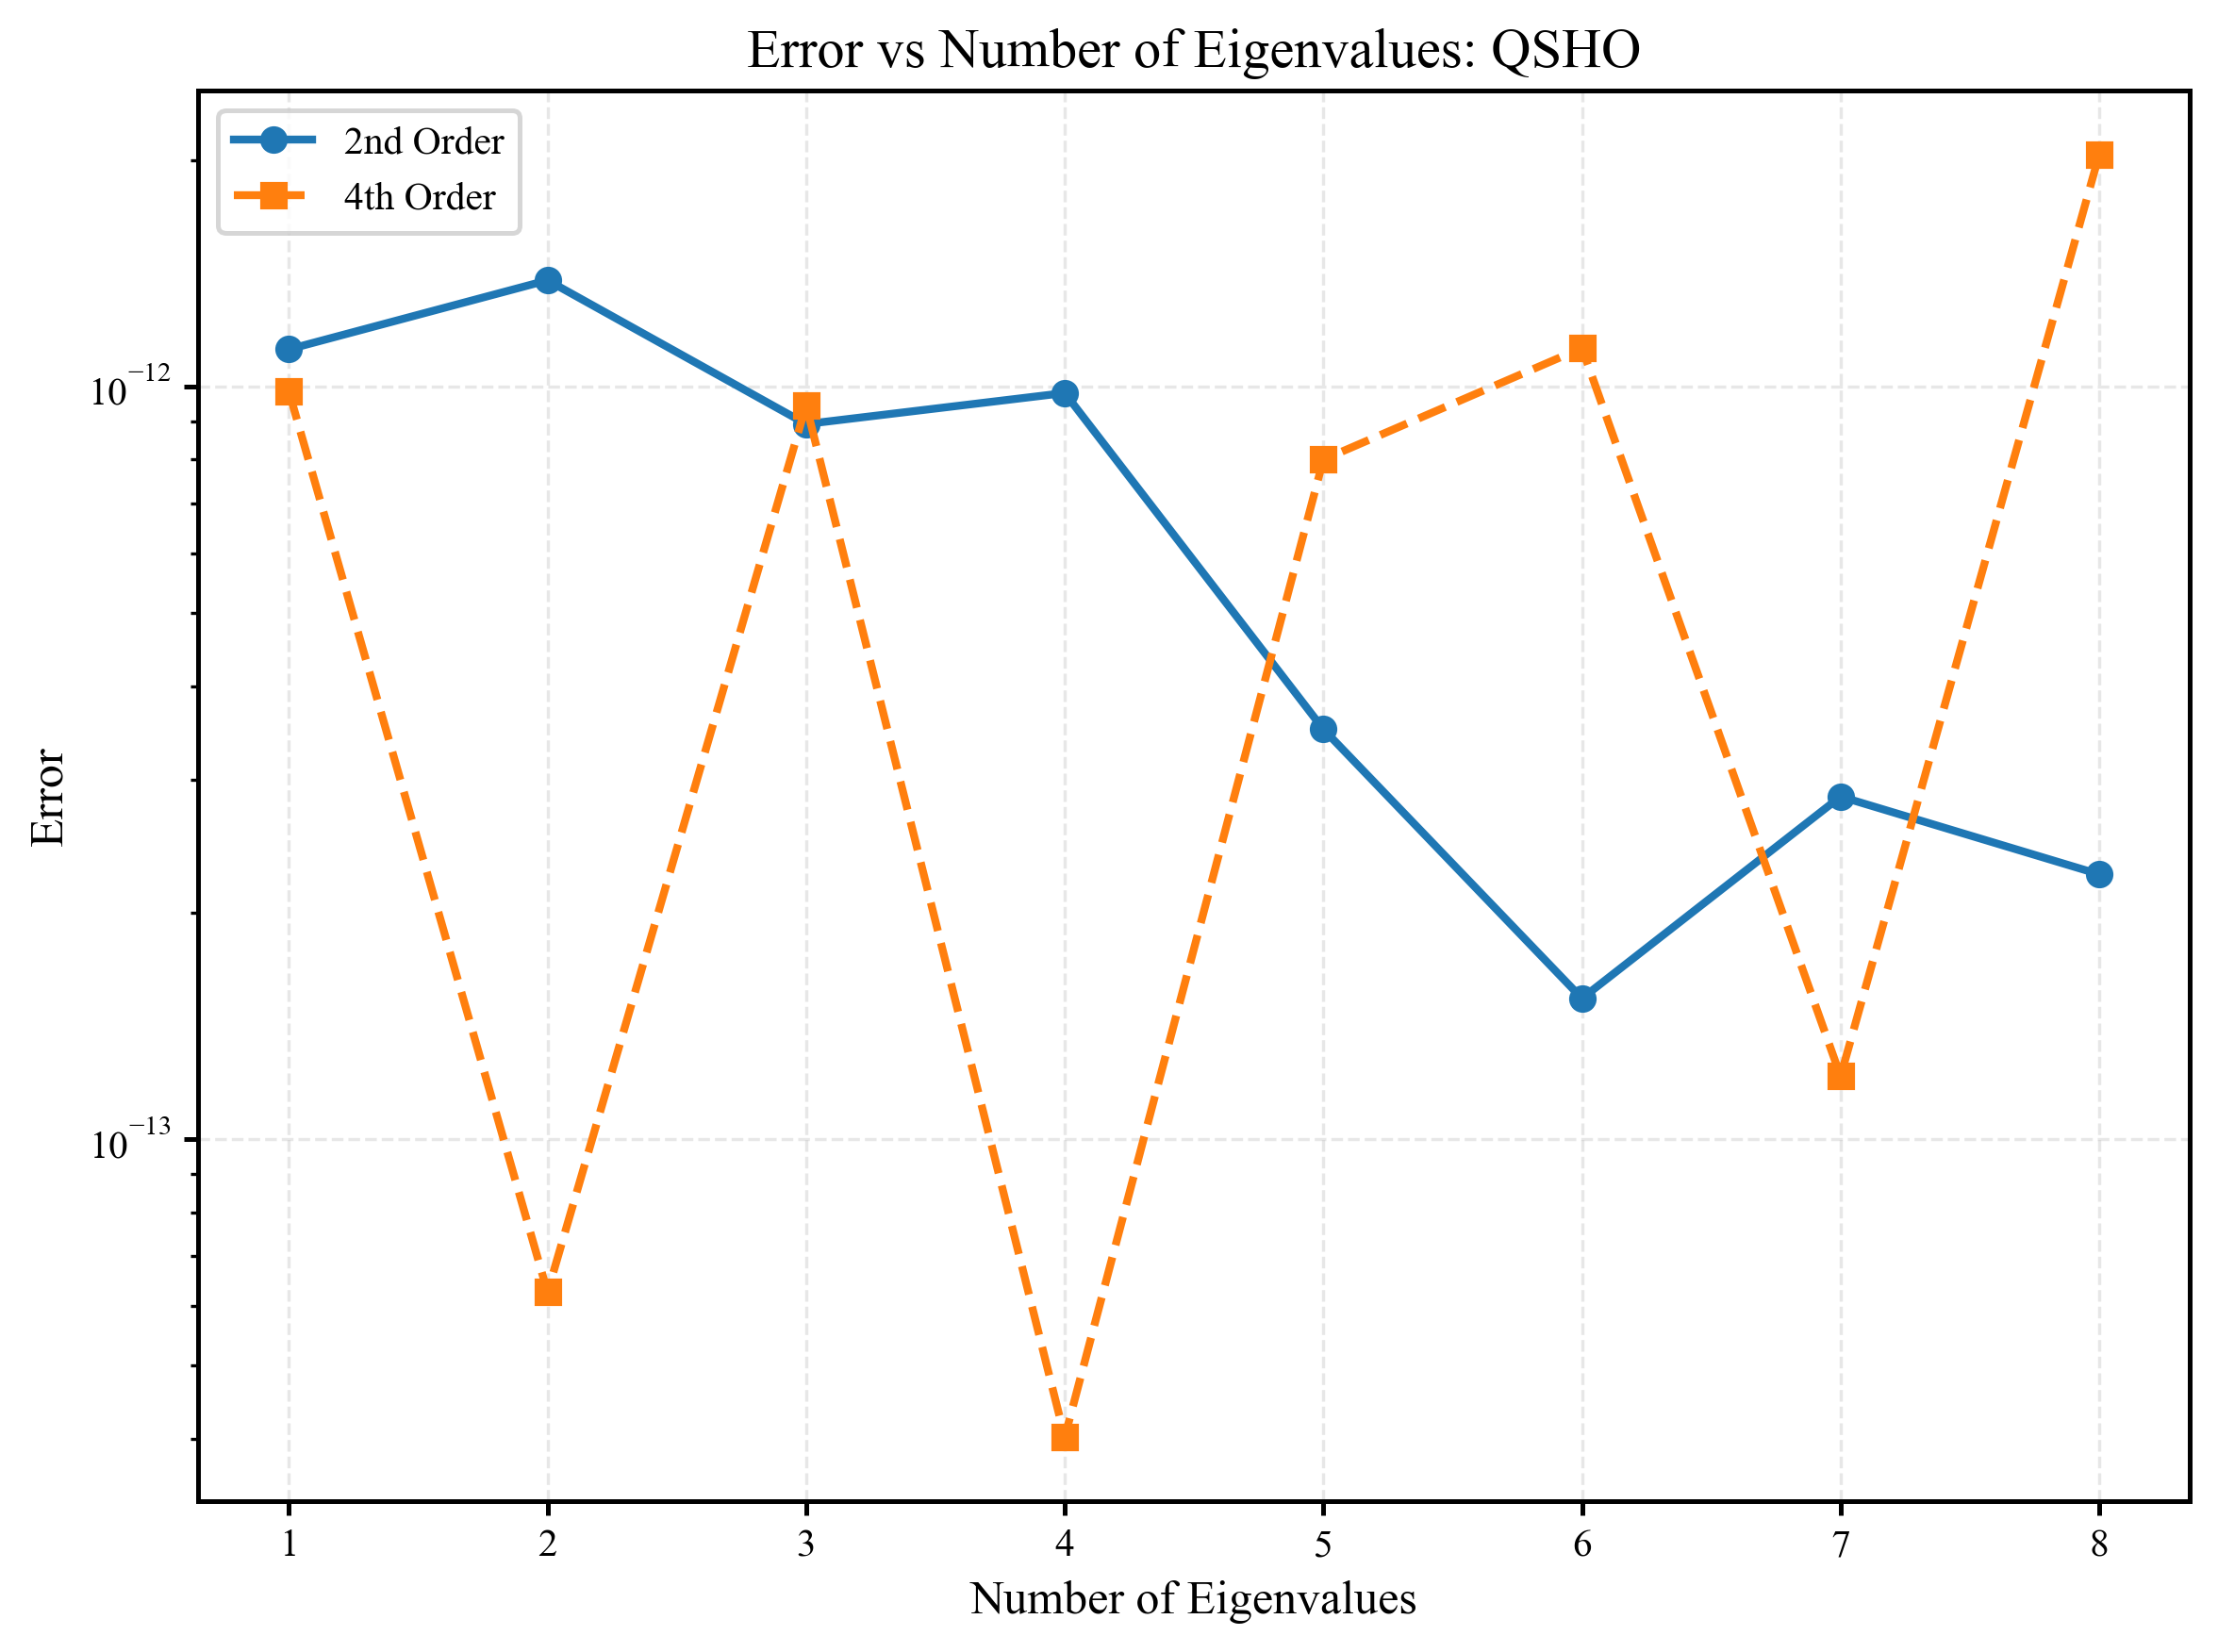

In [7]:
# Quick-run settings (fast sanity-check plots)
N_values_convergence = np.arange(100, 1001, 100)
N_values_timing = np.arange(100, 1001, 200)
N_fixed = 800

x_inf_values = np.array([3.0, 5.0, 7.5, 10.0])
n_eigenvalues_range = np.arange(1, 9, 1)

qsho_results = run_all_analyses(
    qsho_config,
    N_values=N_values_convergence,
    N_fixed=N_fixed,
    x_inf_values=x_inf_values,
    n_eigenvalues_range=n_eigenvalues_range,
    save_prefix='qsho'
)


### Generate All Analyses for ISW


Generating convergence analysis for ISW...
  Using analytical reference energy (ground state): 0.0493480220054
  Computing N=100...
  Computing N=200...
  Computing N=300...
  Computing N=400...
  Computing N=500...
  Computing N=600...
  Computing N=700...
  Computing N=800...
  Computing N=900...
  Computing N=1000...
Saved: images/isw_convergence.png
Generating timing analysis for ISW...
  Computing 2nd order timings...
  Computing 4th order timings...
Saved: images/isw_timing.png
Generating accuracy analysis for ISW (N=800)...
Saved: images/isw_accuracy.png
Generating spectrum analysis for ISW (N=800)...
Saved: images/isw_spectrum.png
Generating wavefunction analysis for ISW (N=800)...
Saved: images/isw_wavefunction_state0.png
Saved: images/isw_wavefunction_state1.png
Saved: images/isw_wavefunction_state2.png
Generating error vs n_eigenvalues analysis for ISW...
Saved: images/isw_error_vs_neigenvalues.png


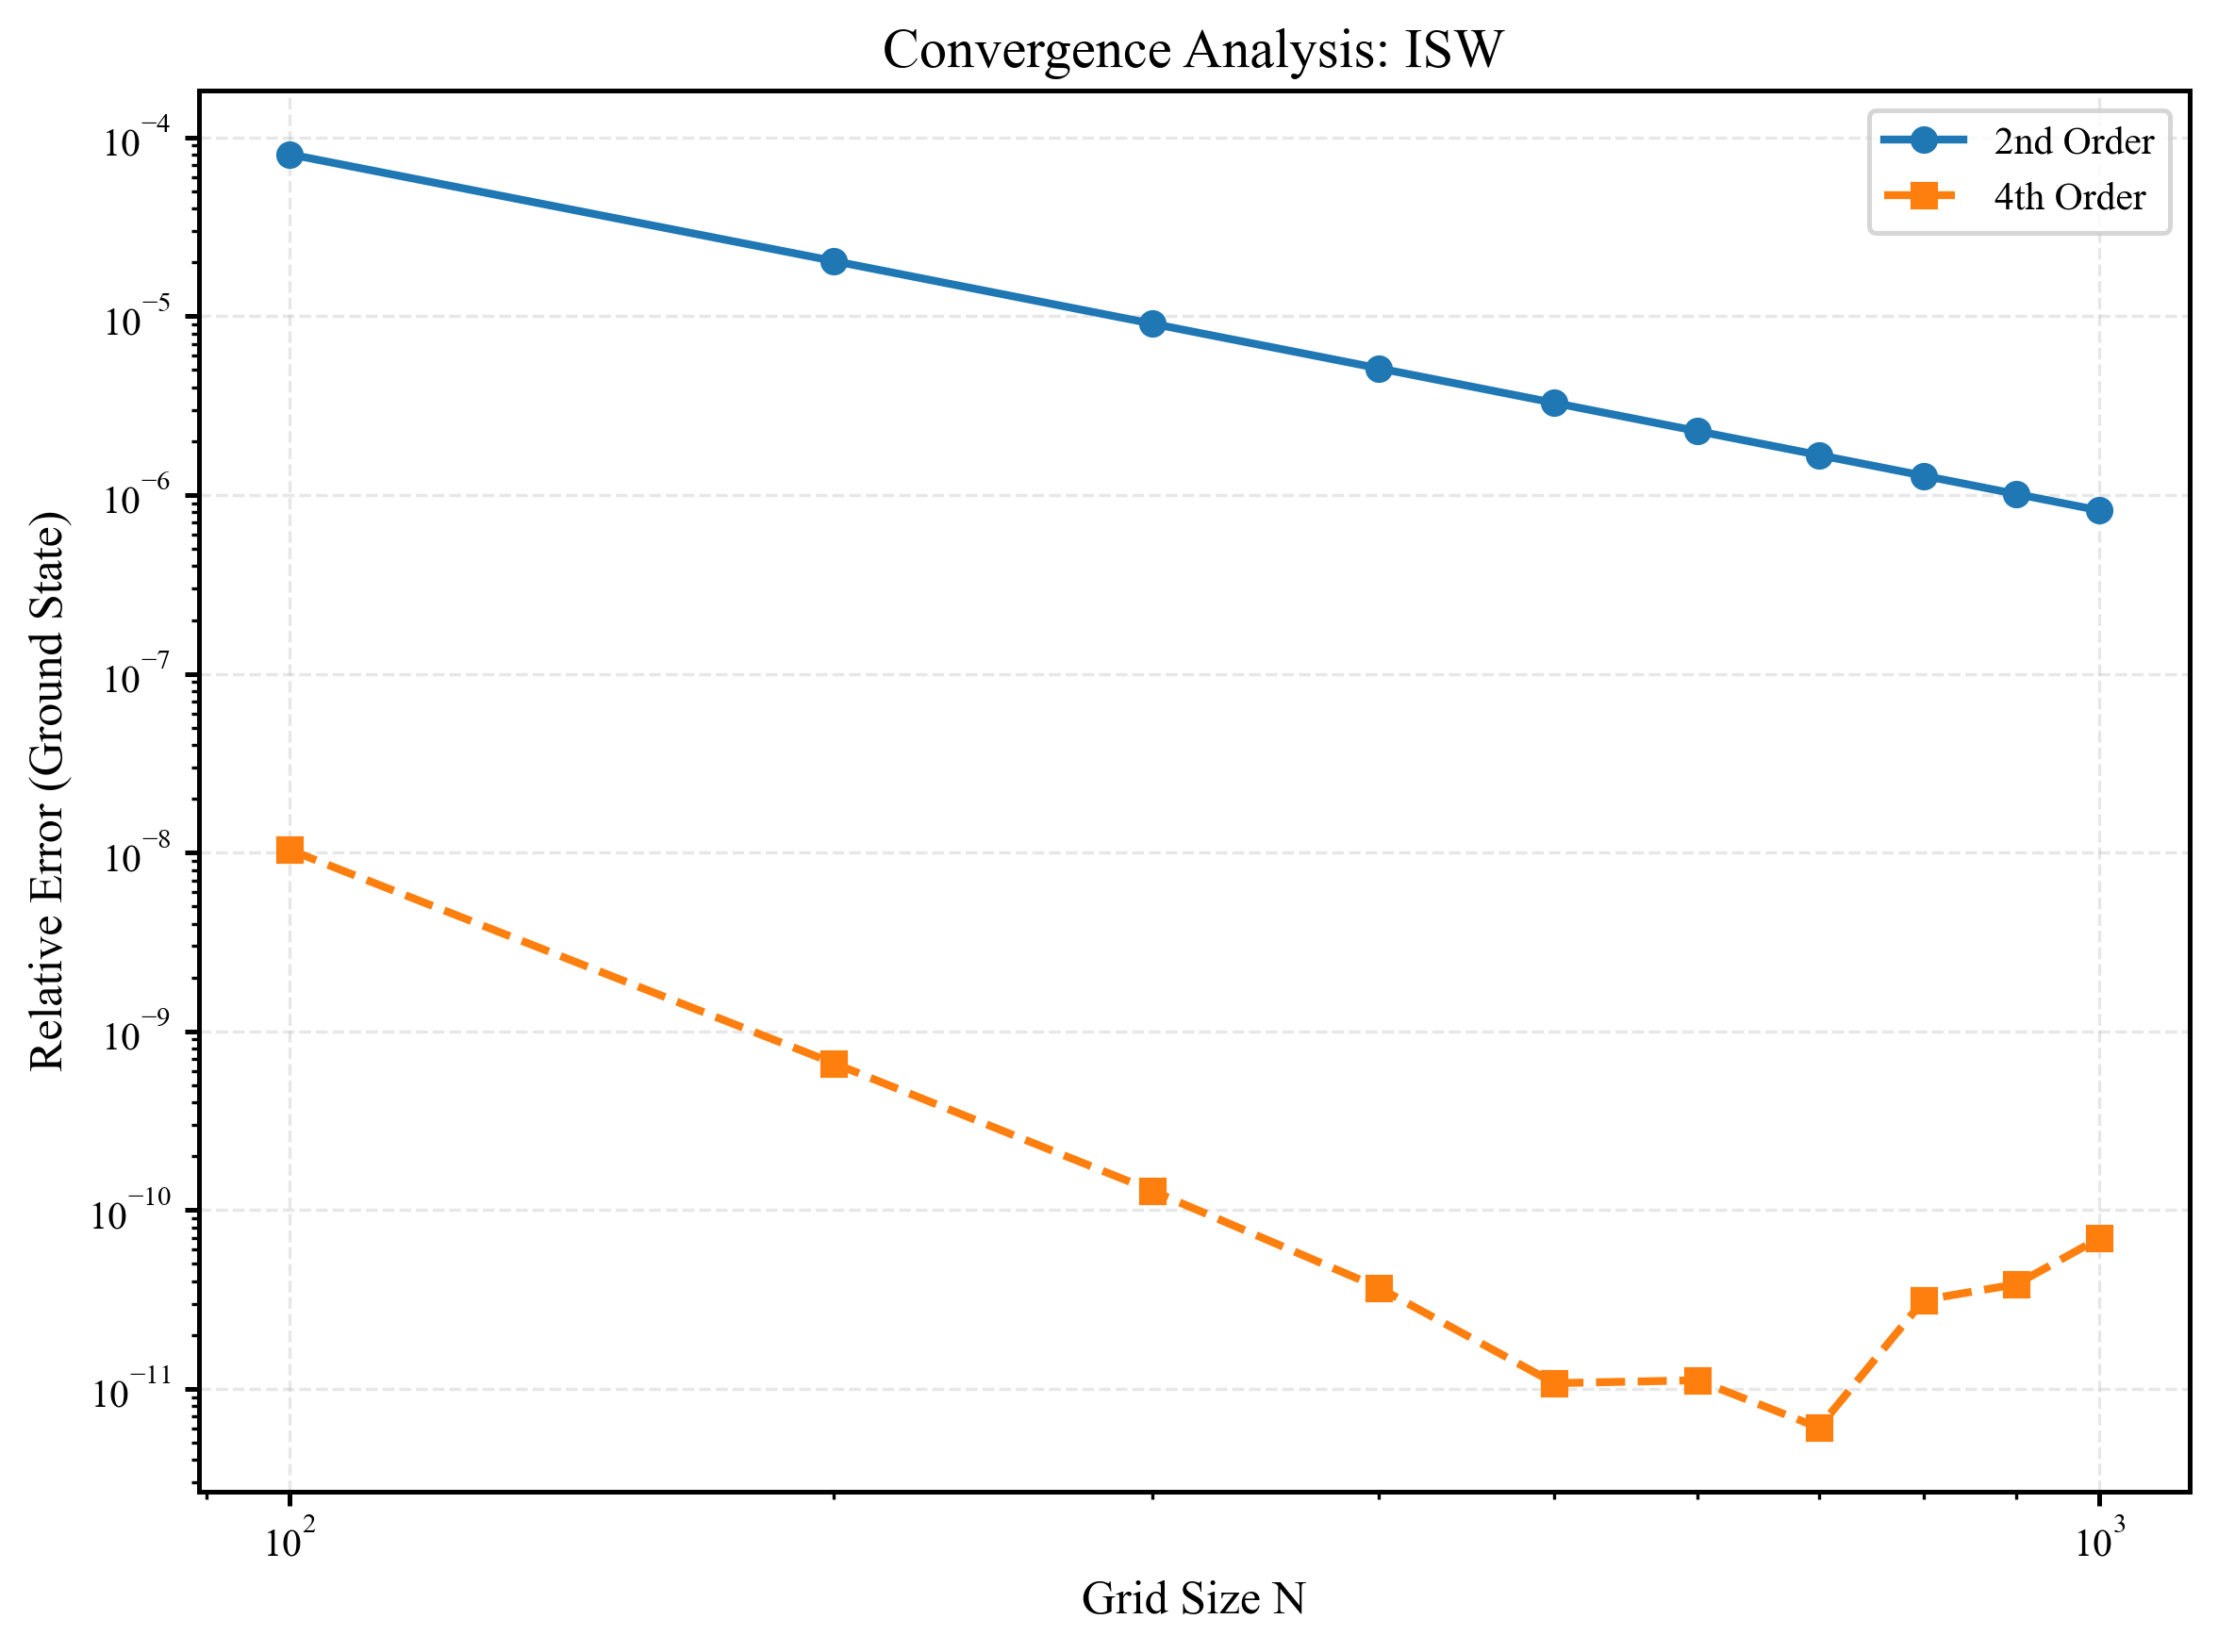

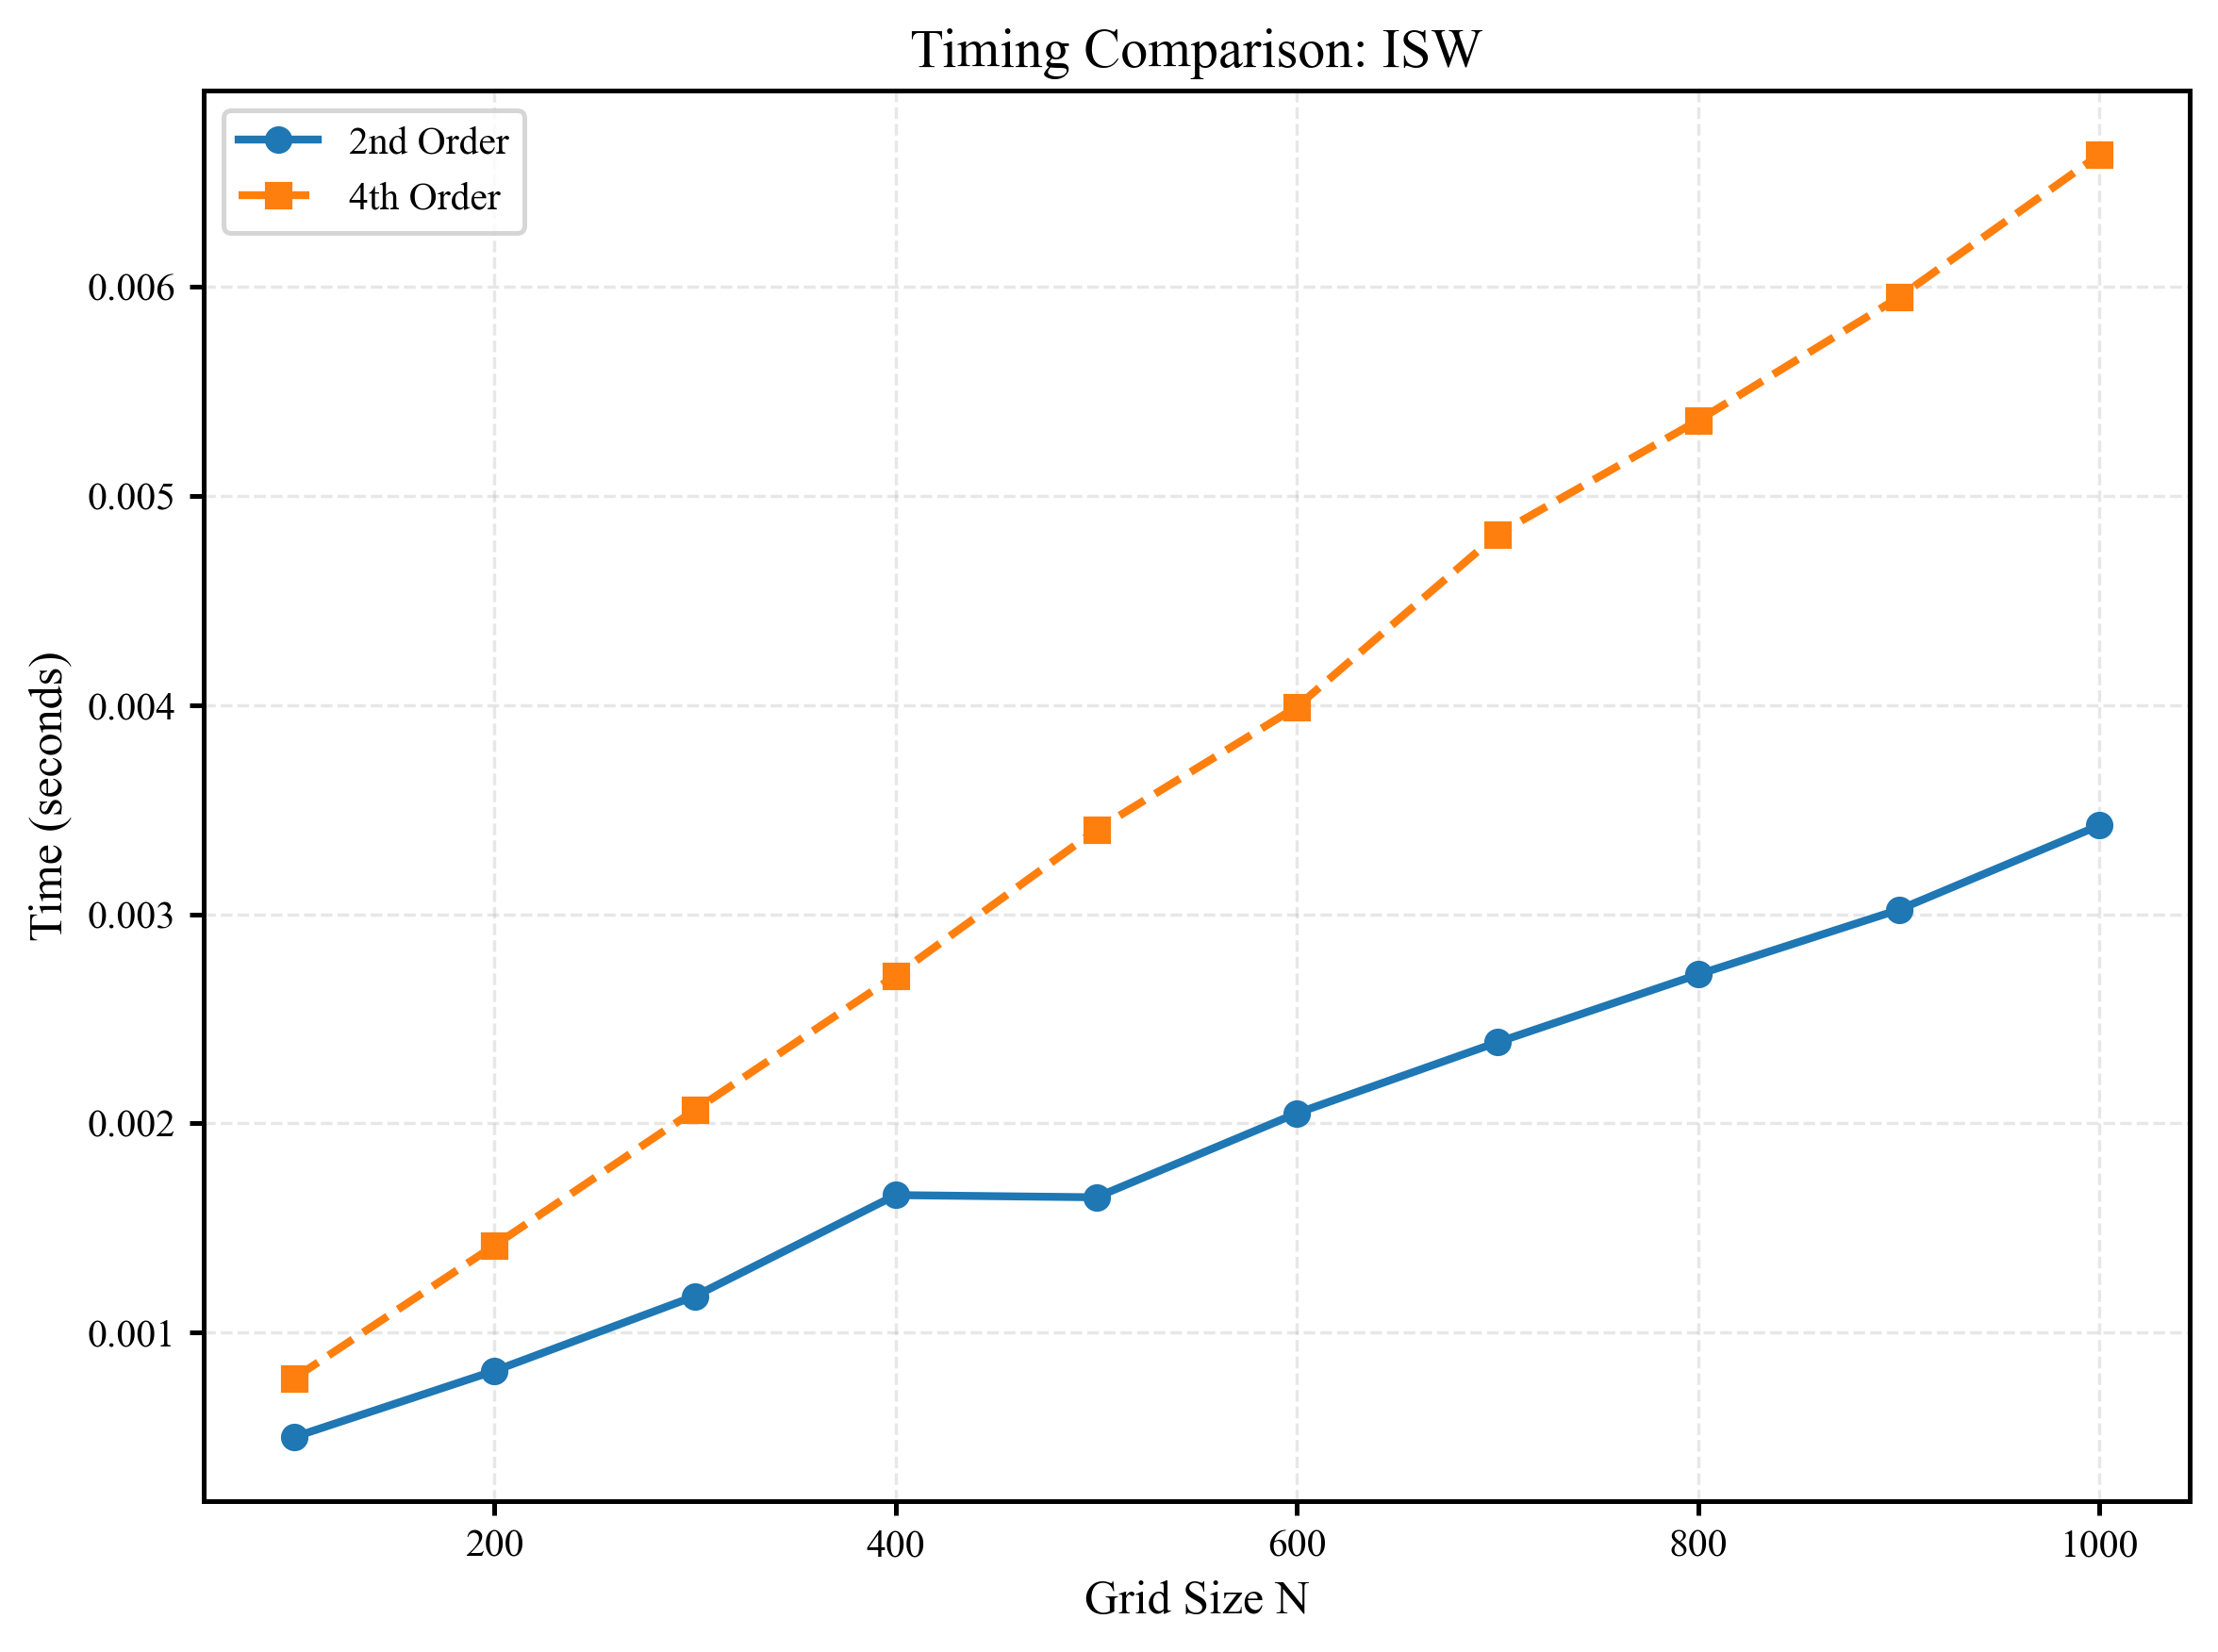

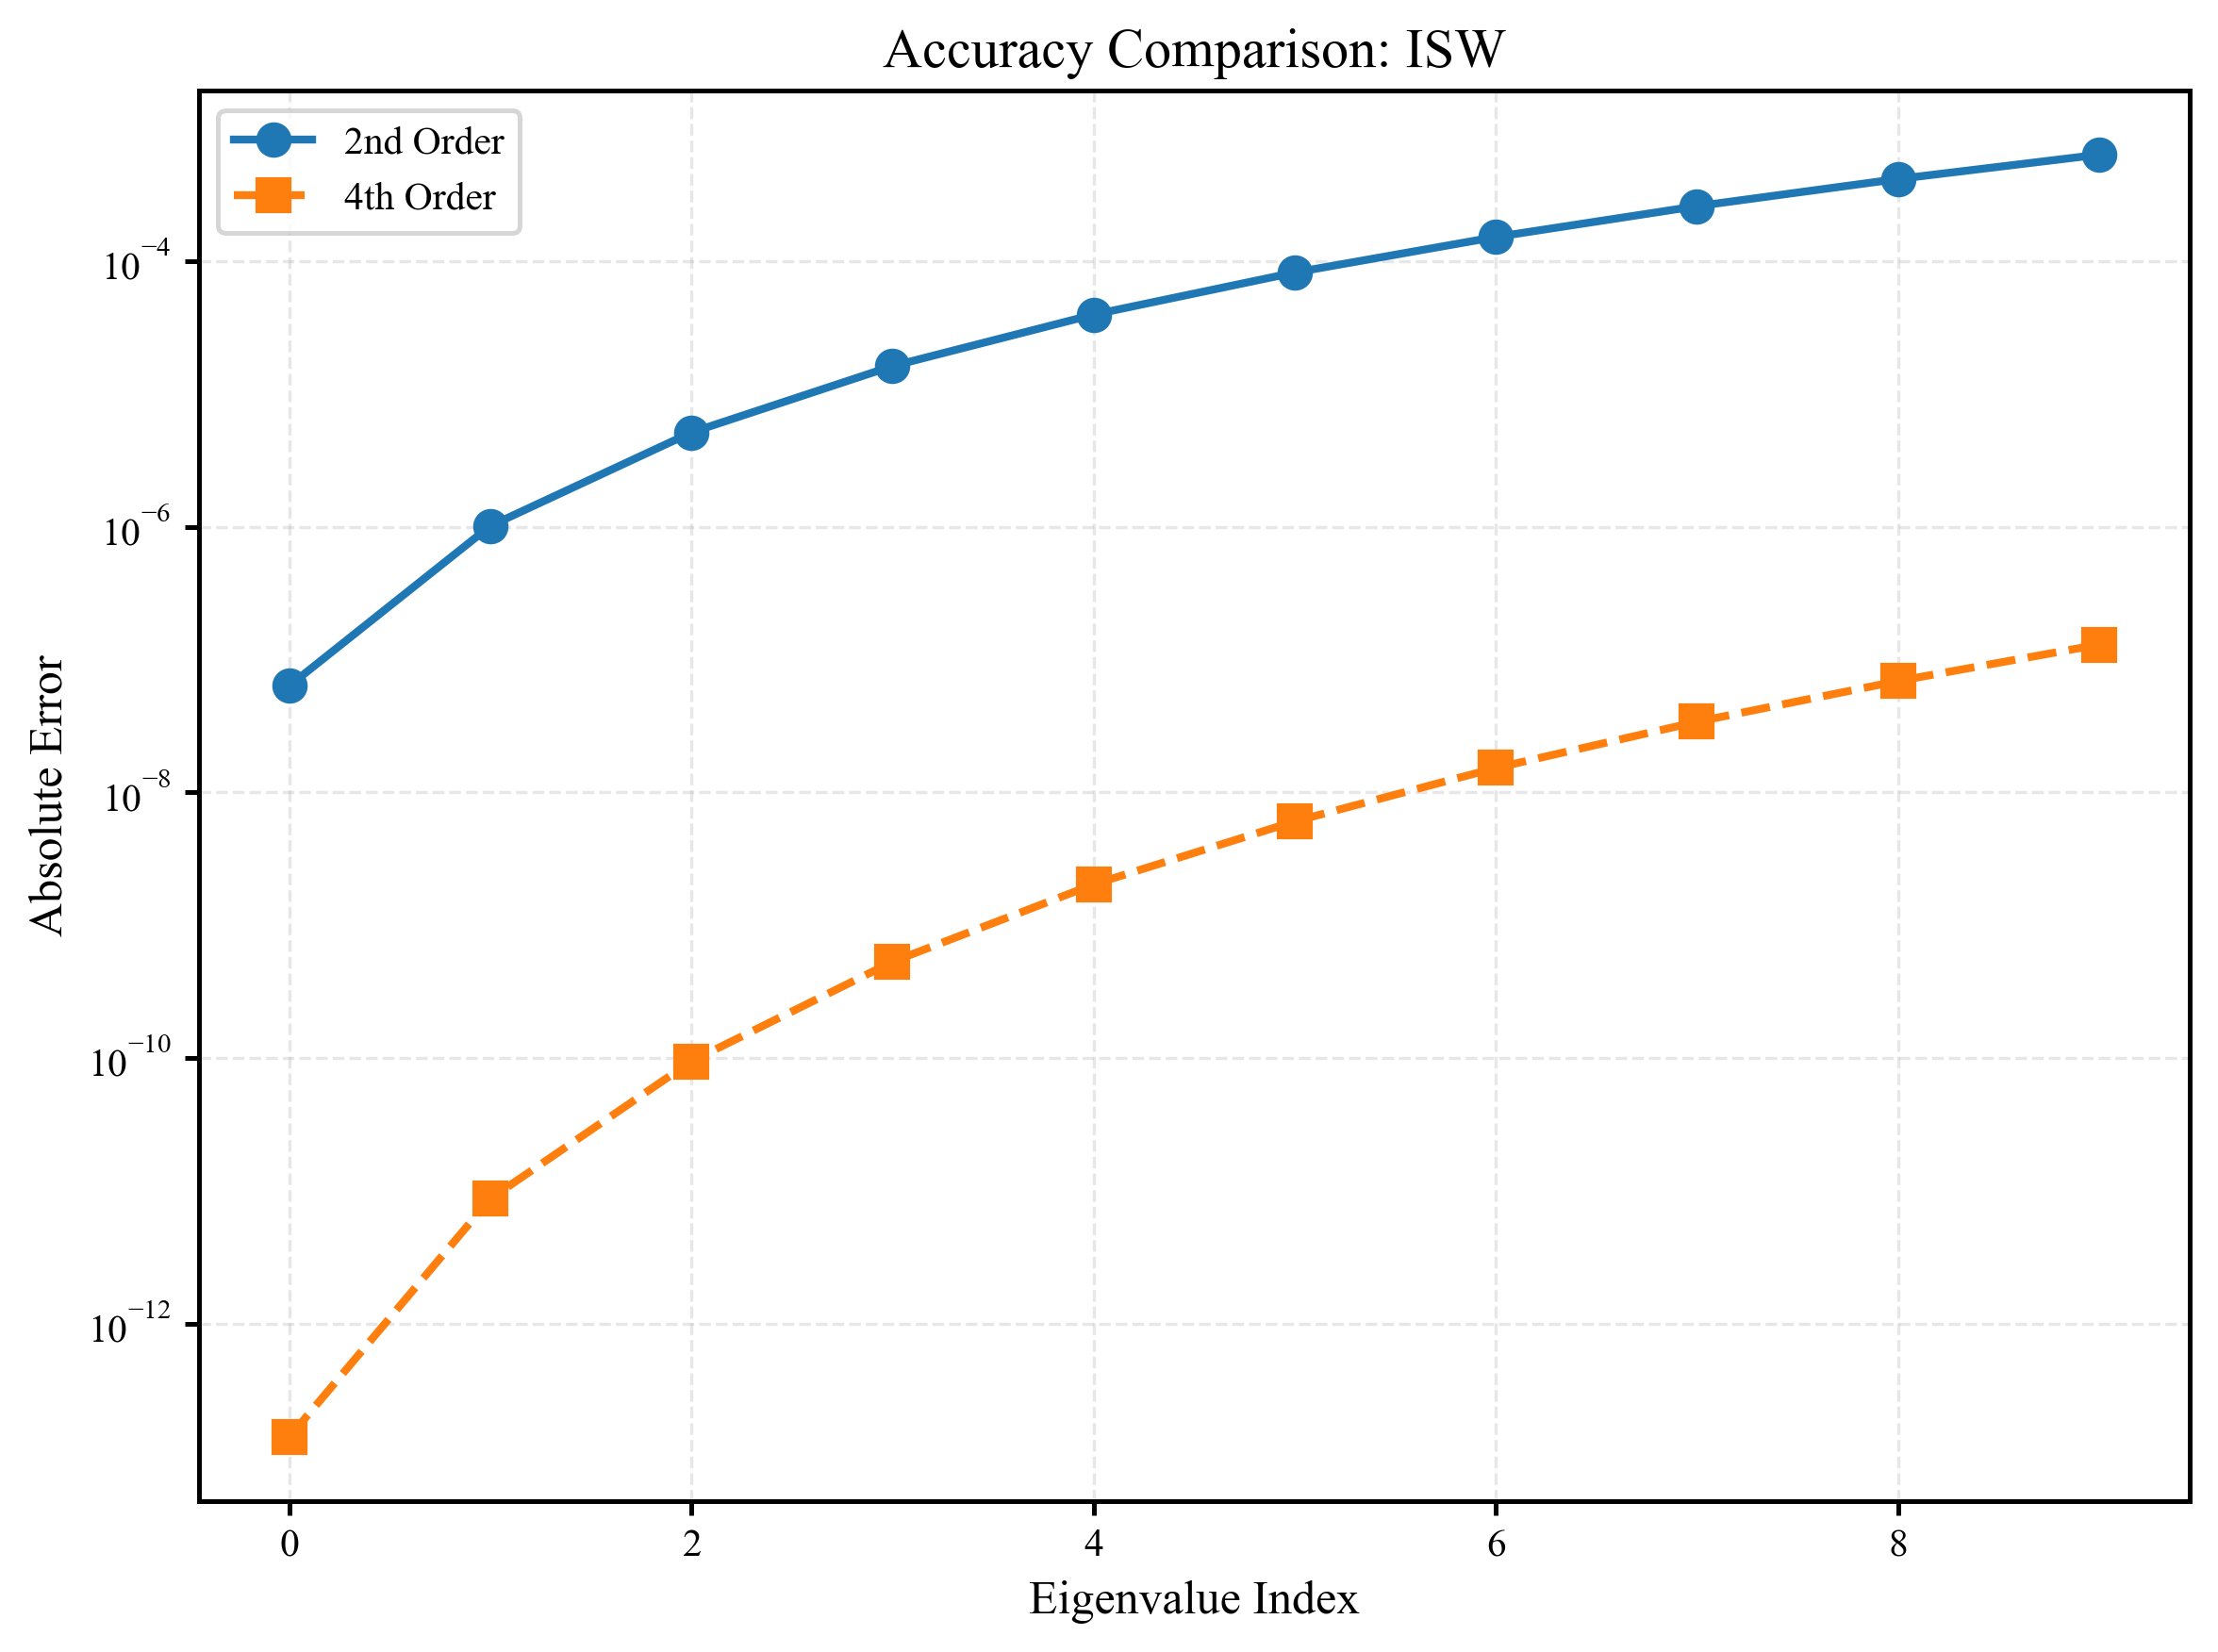

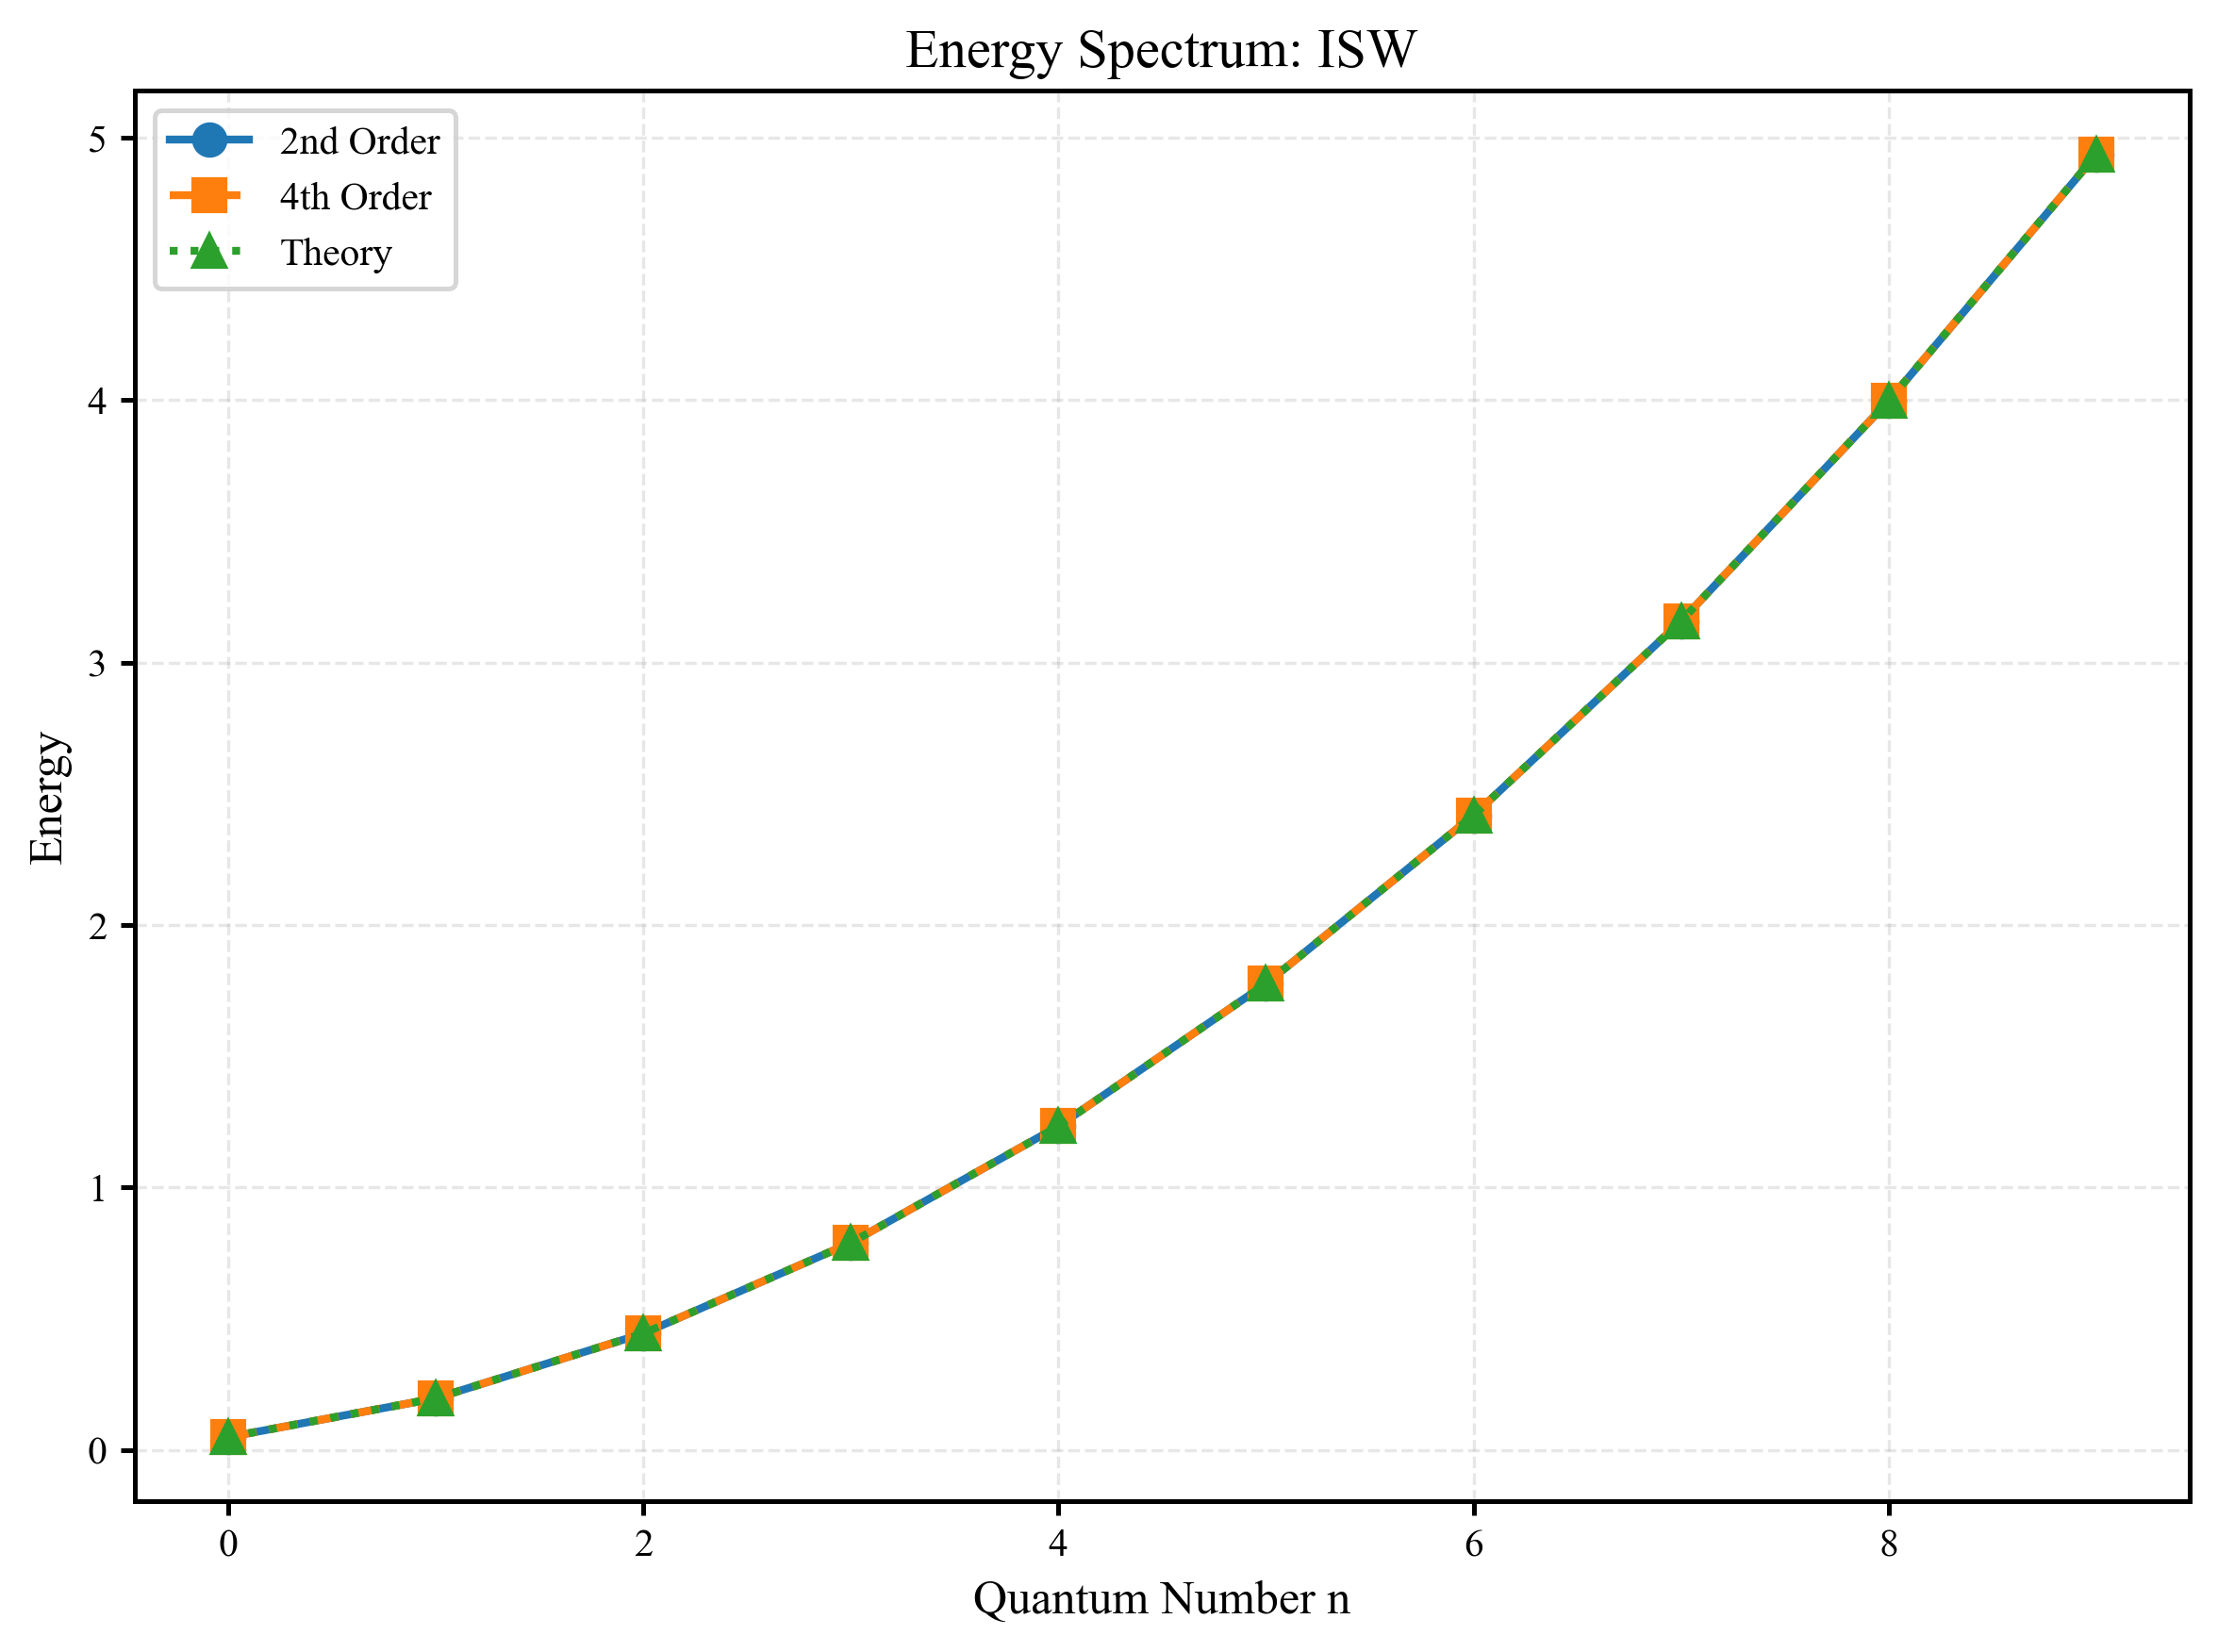

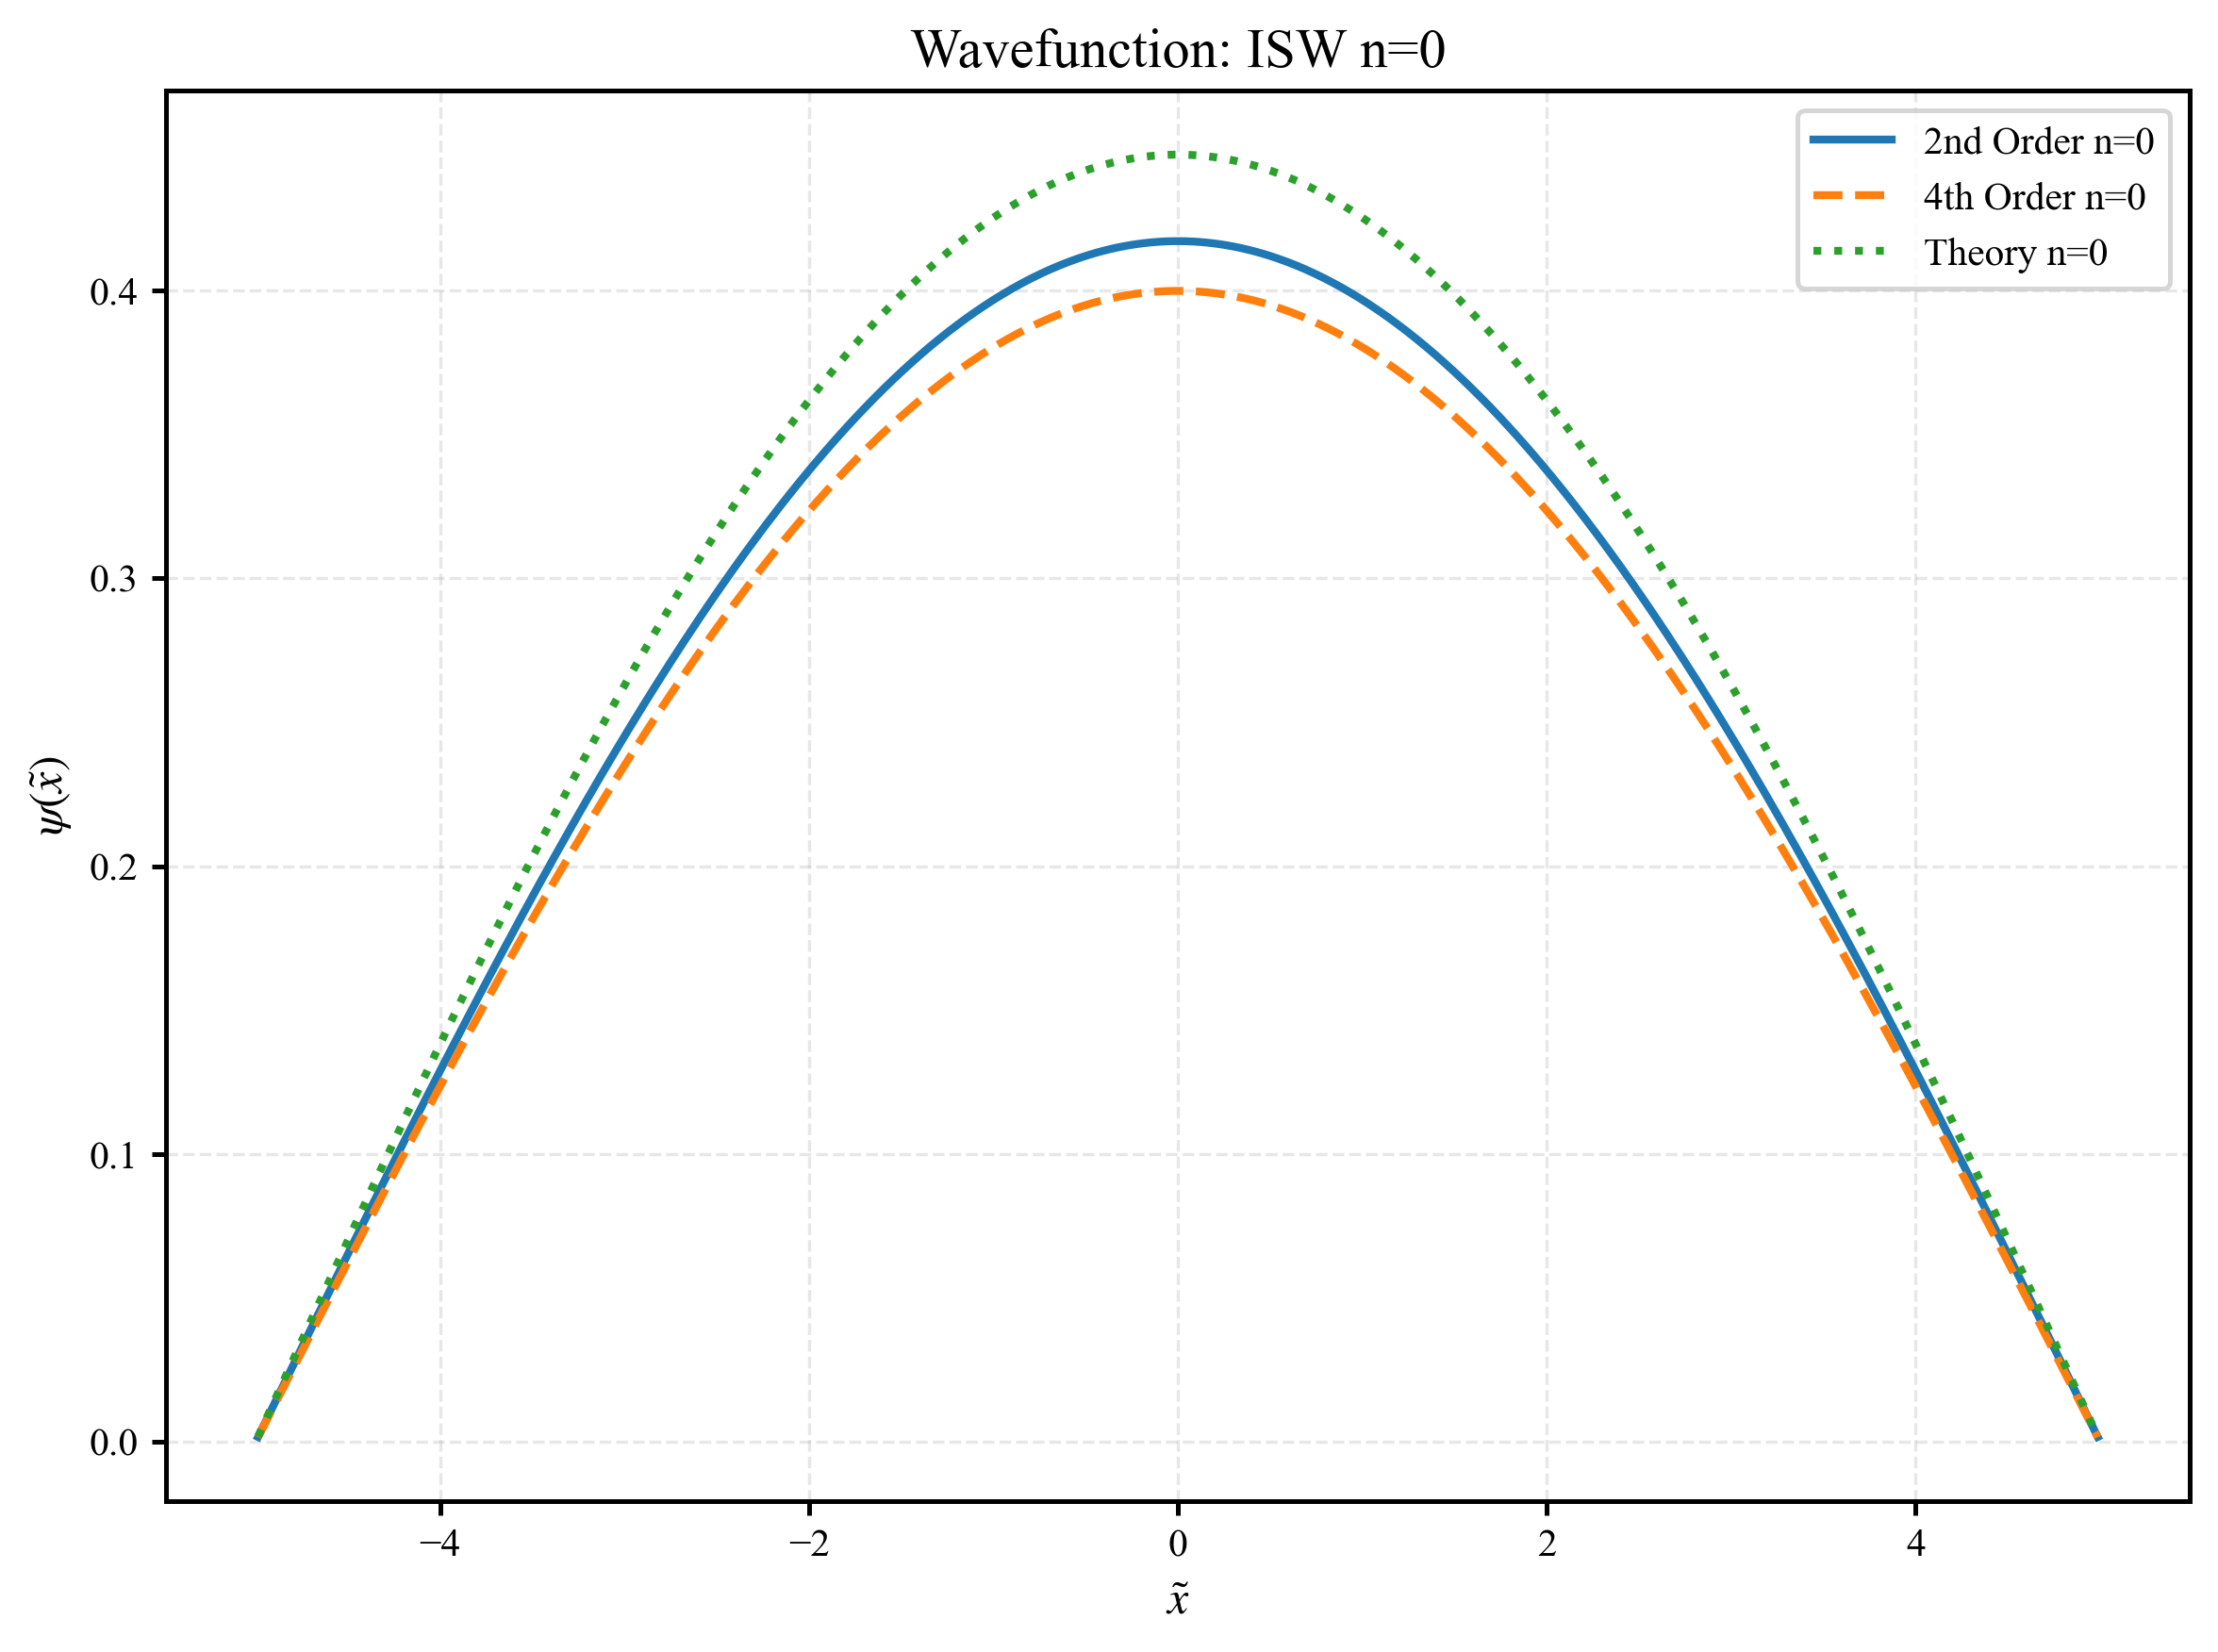

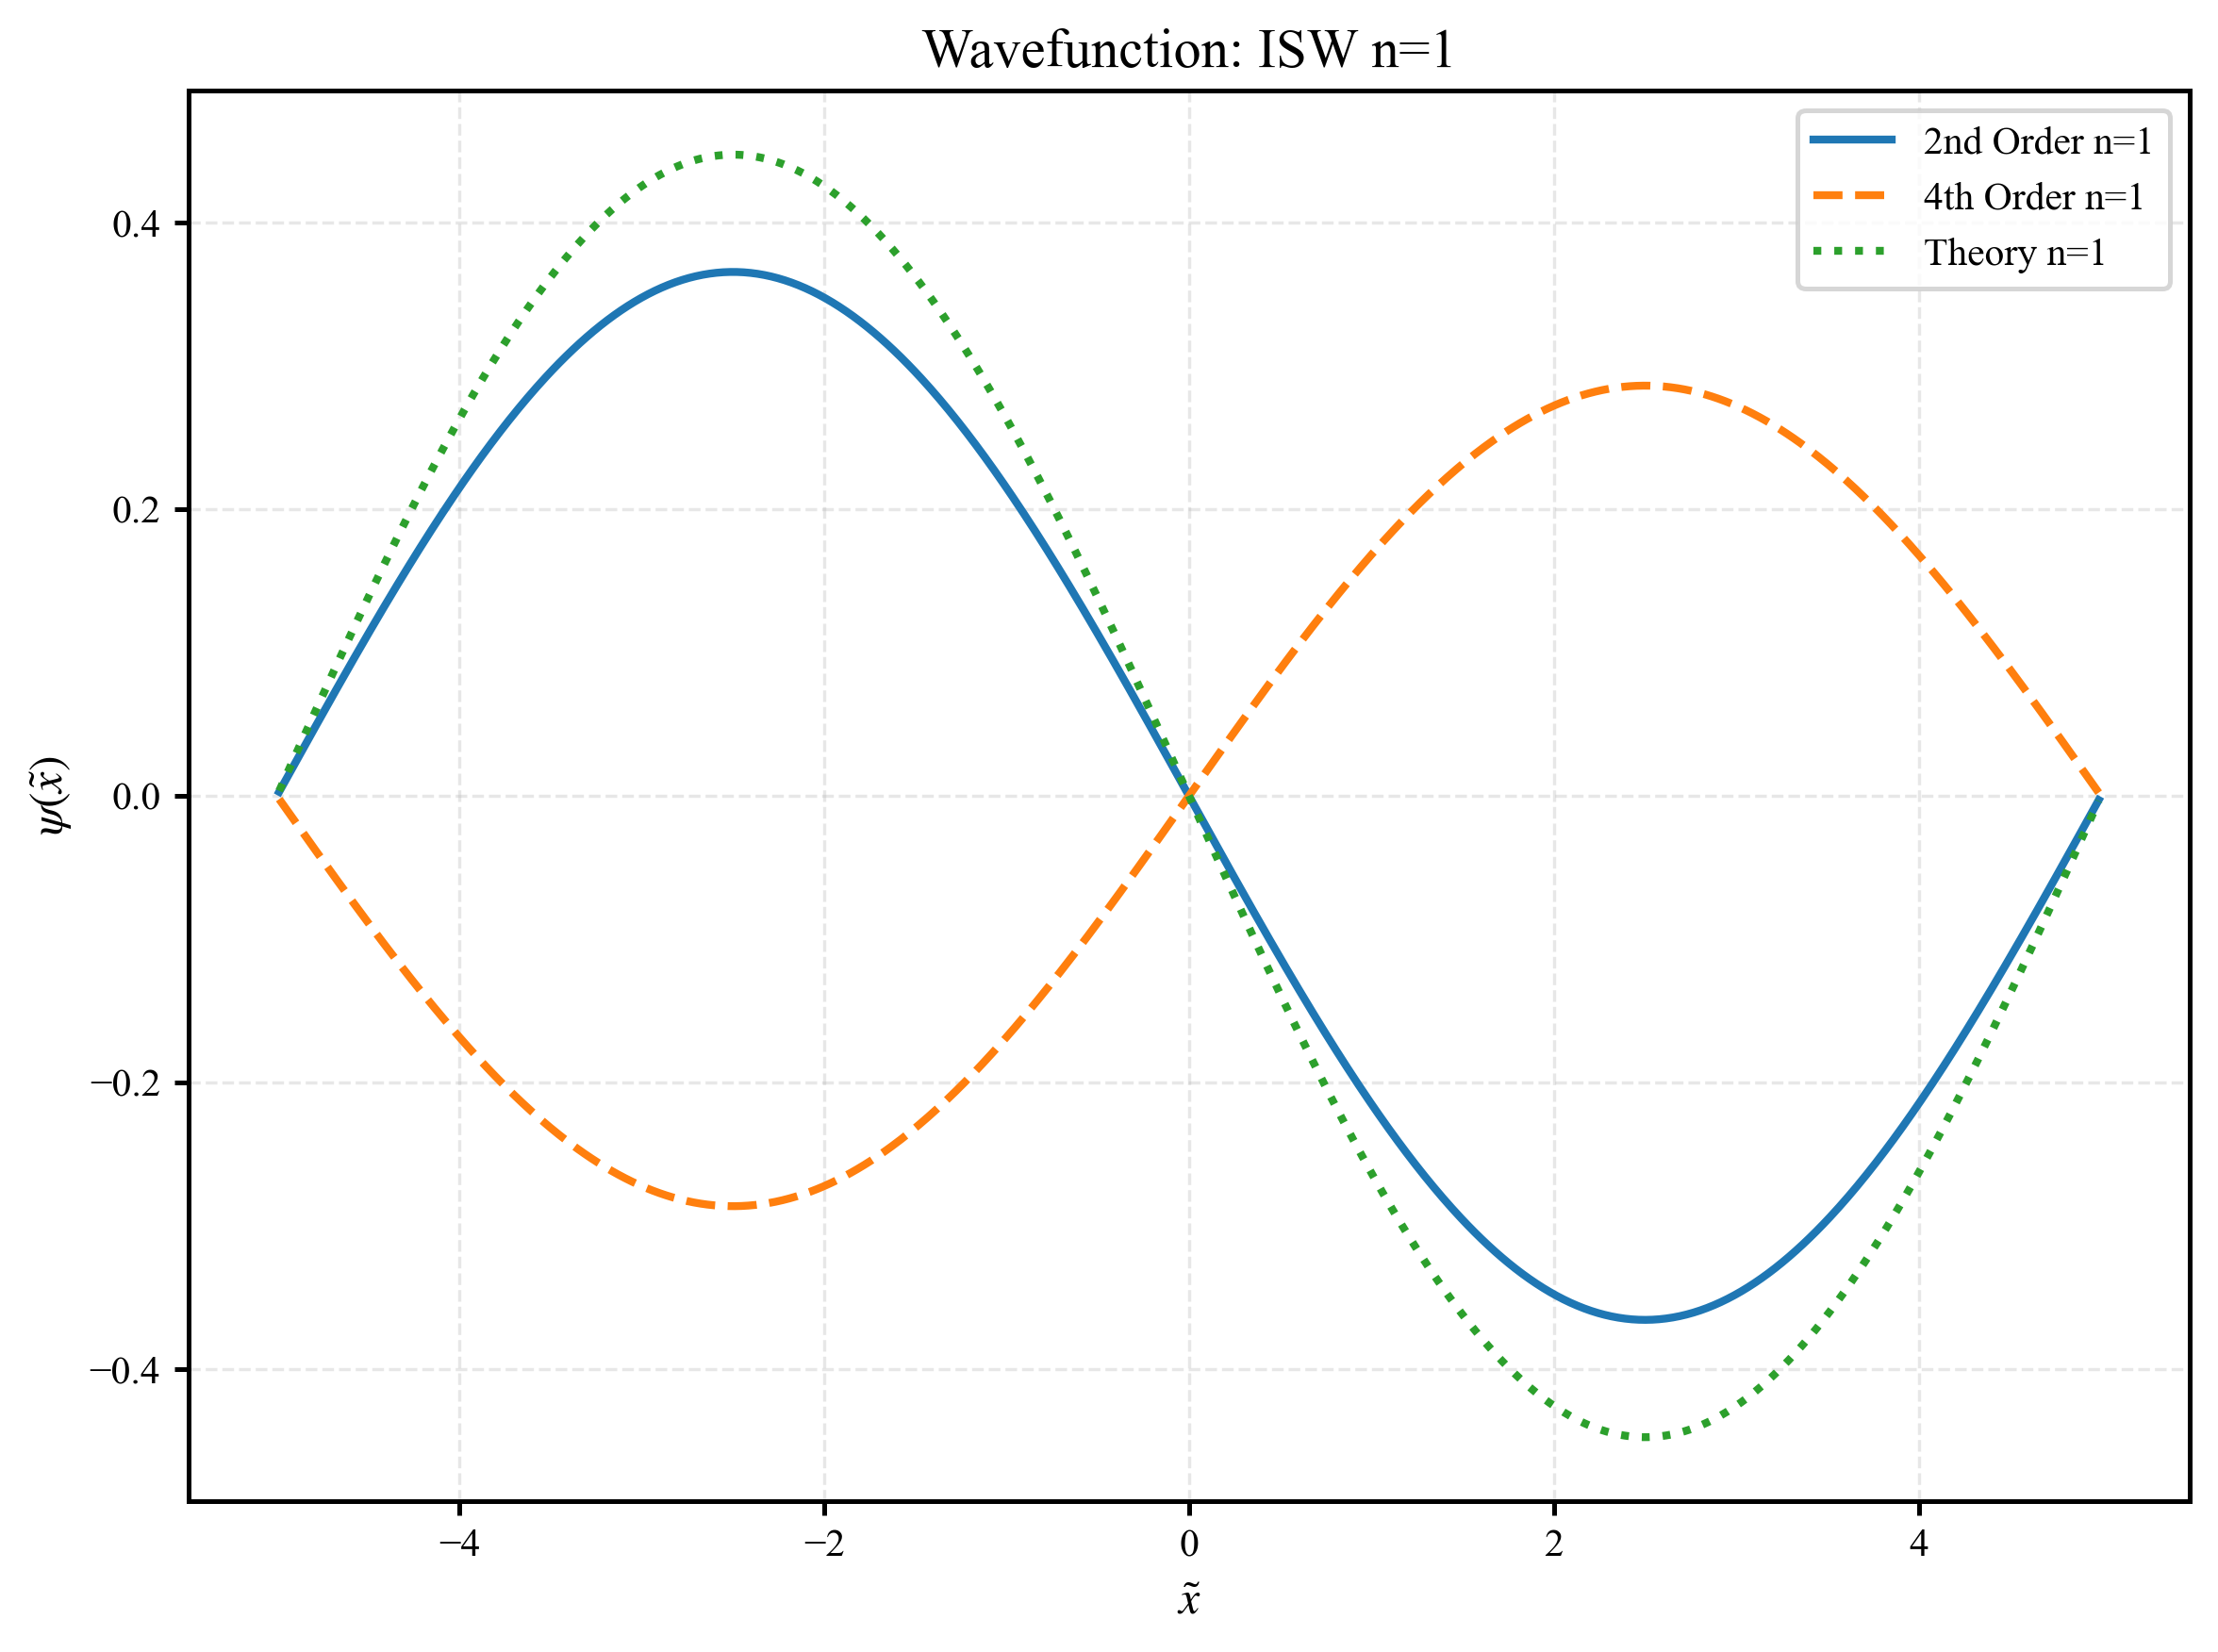

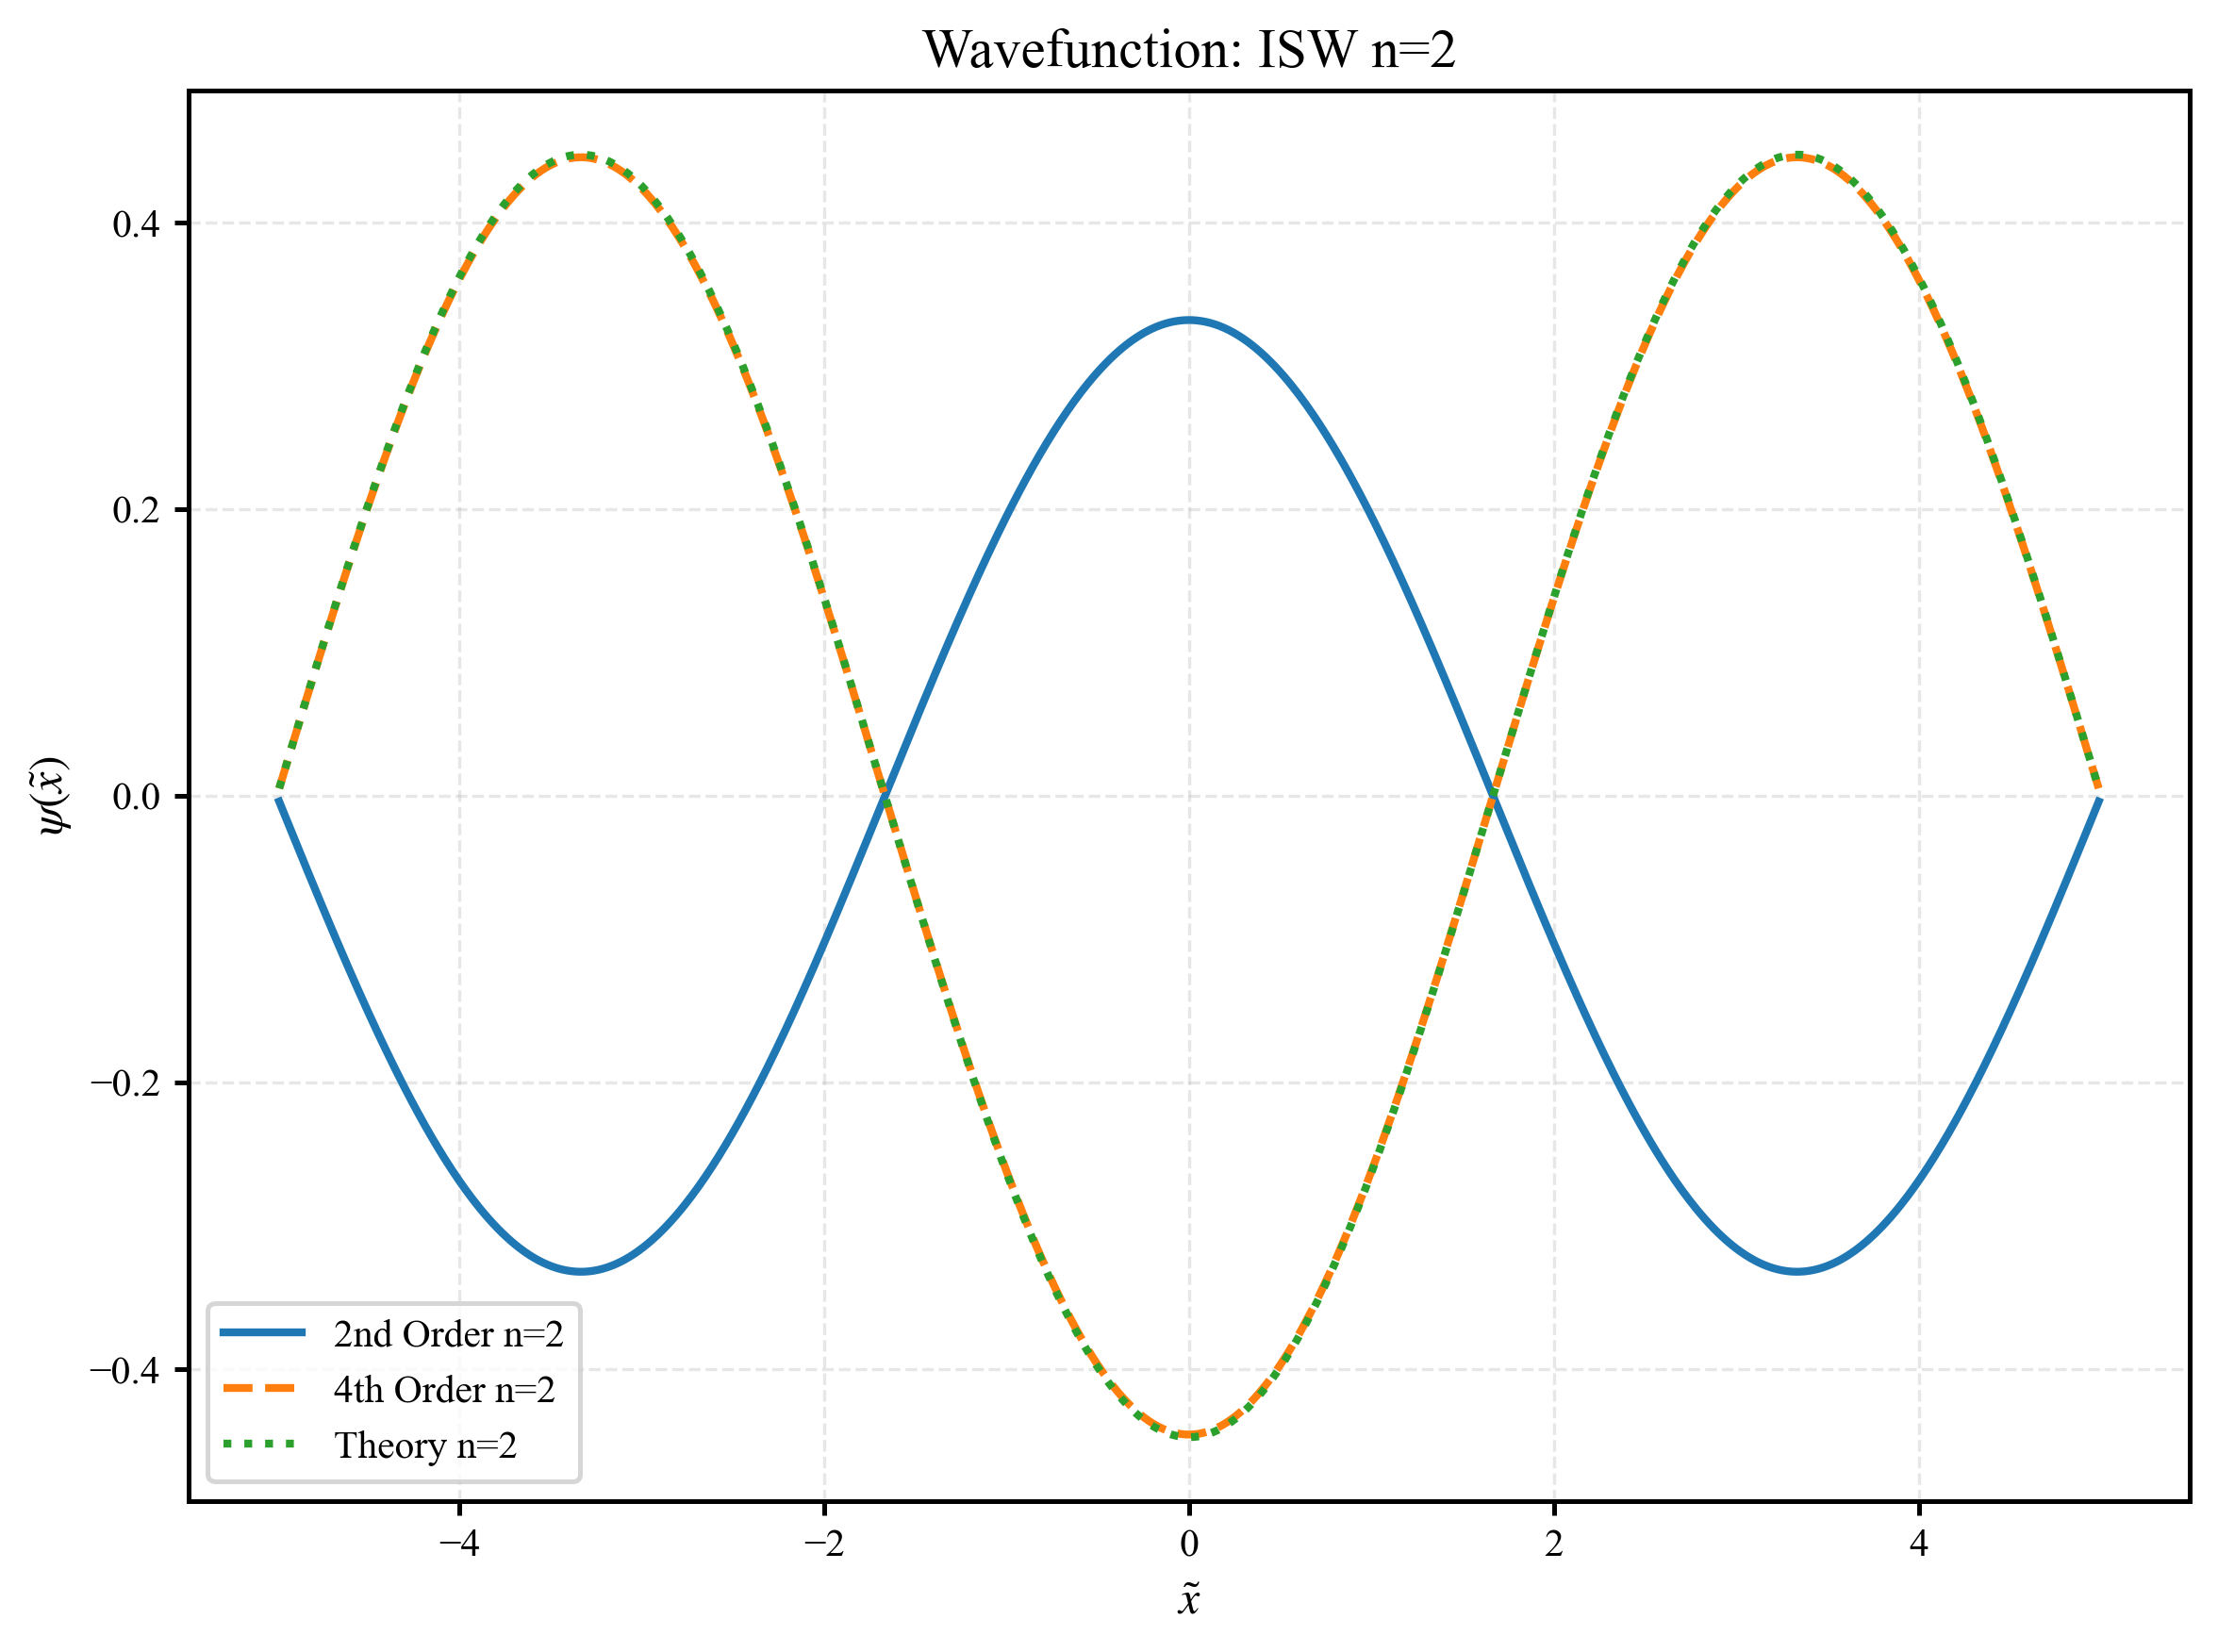

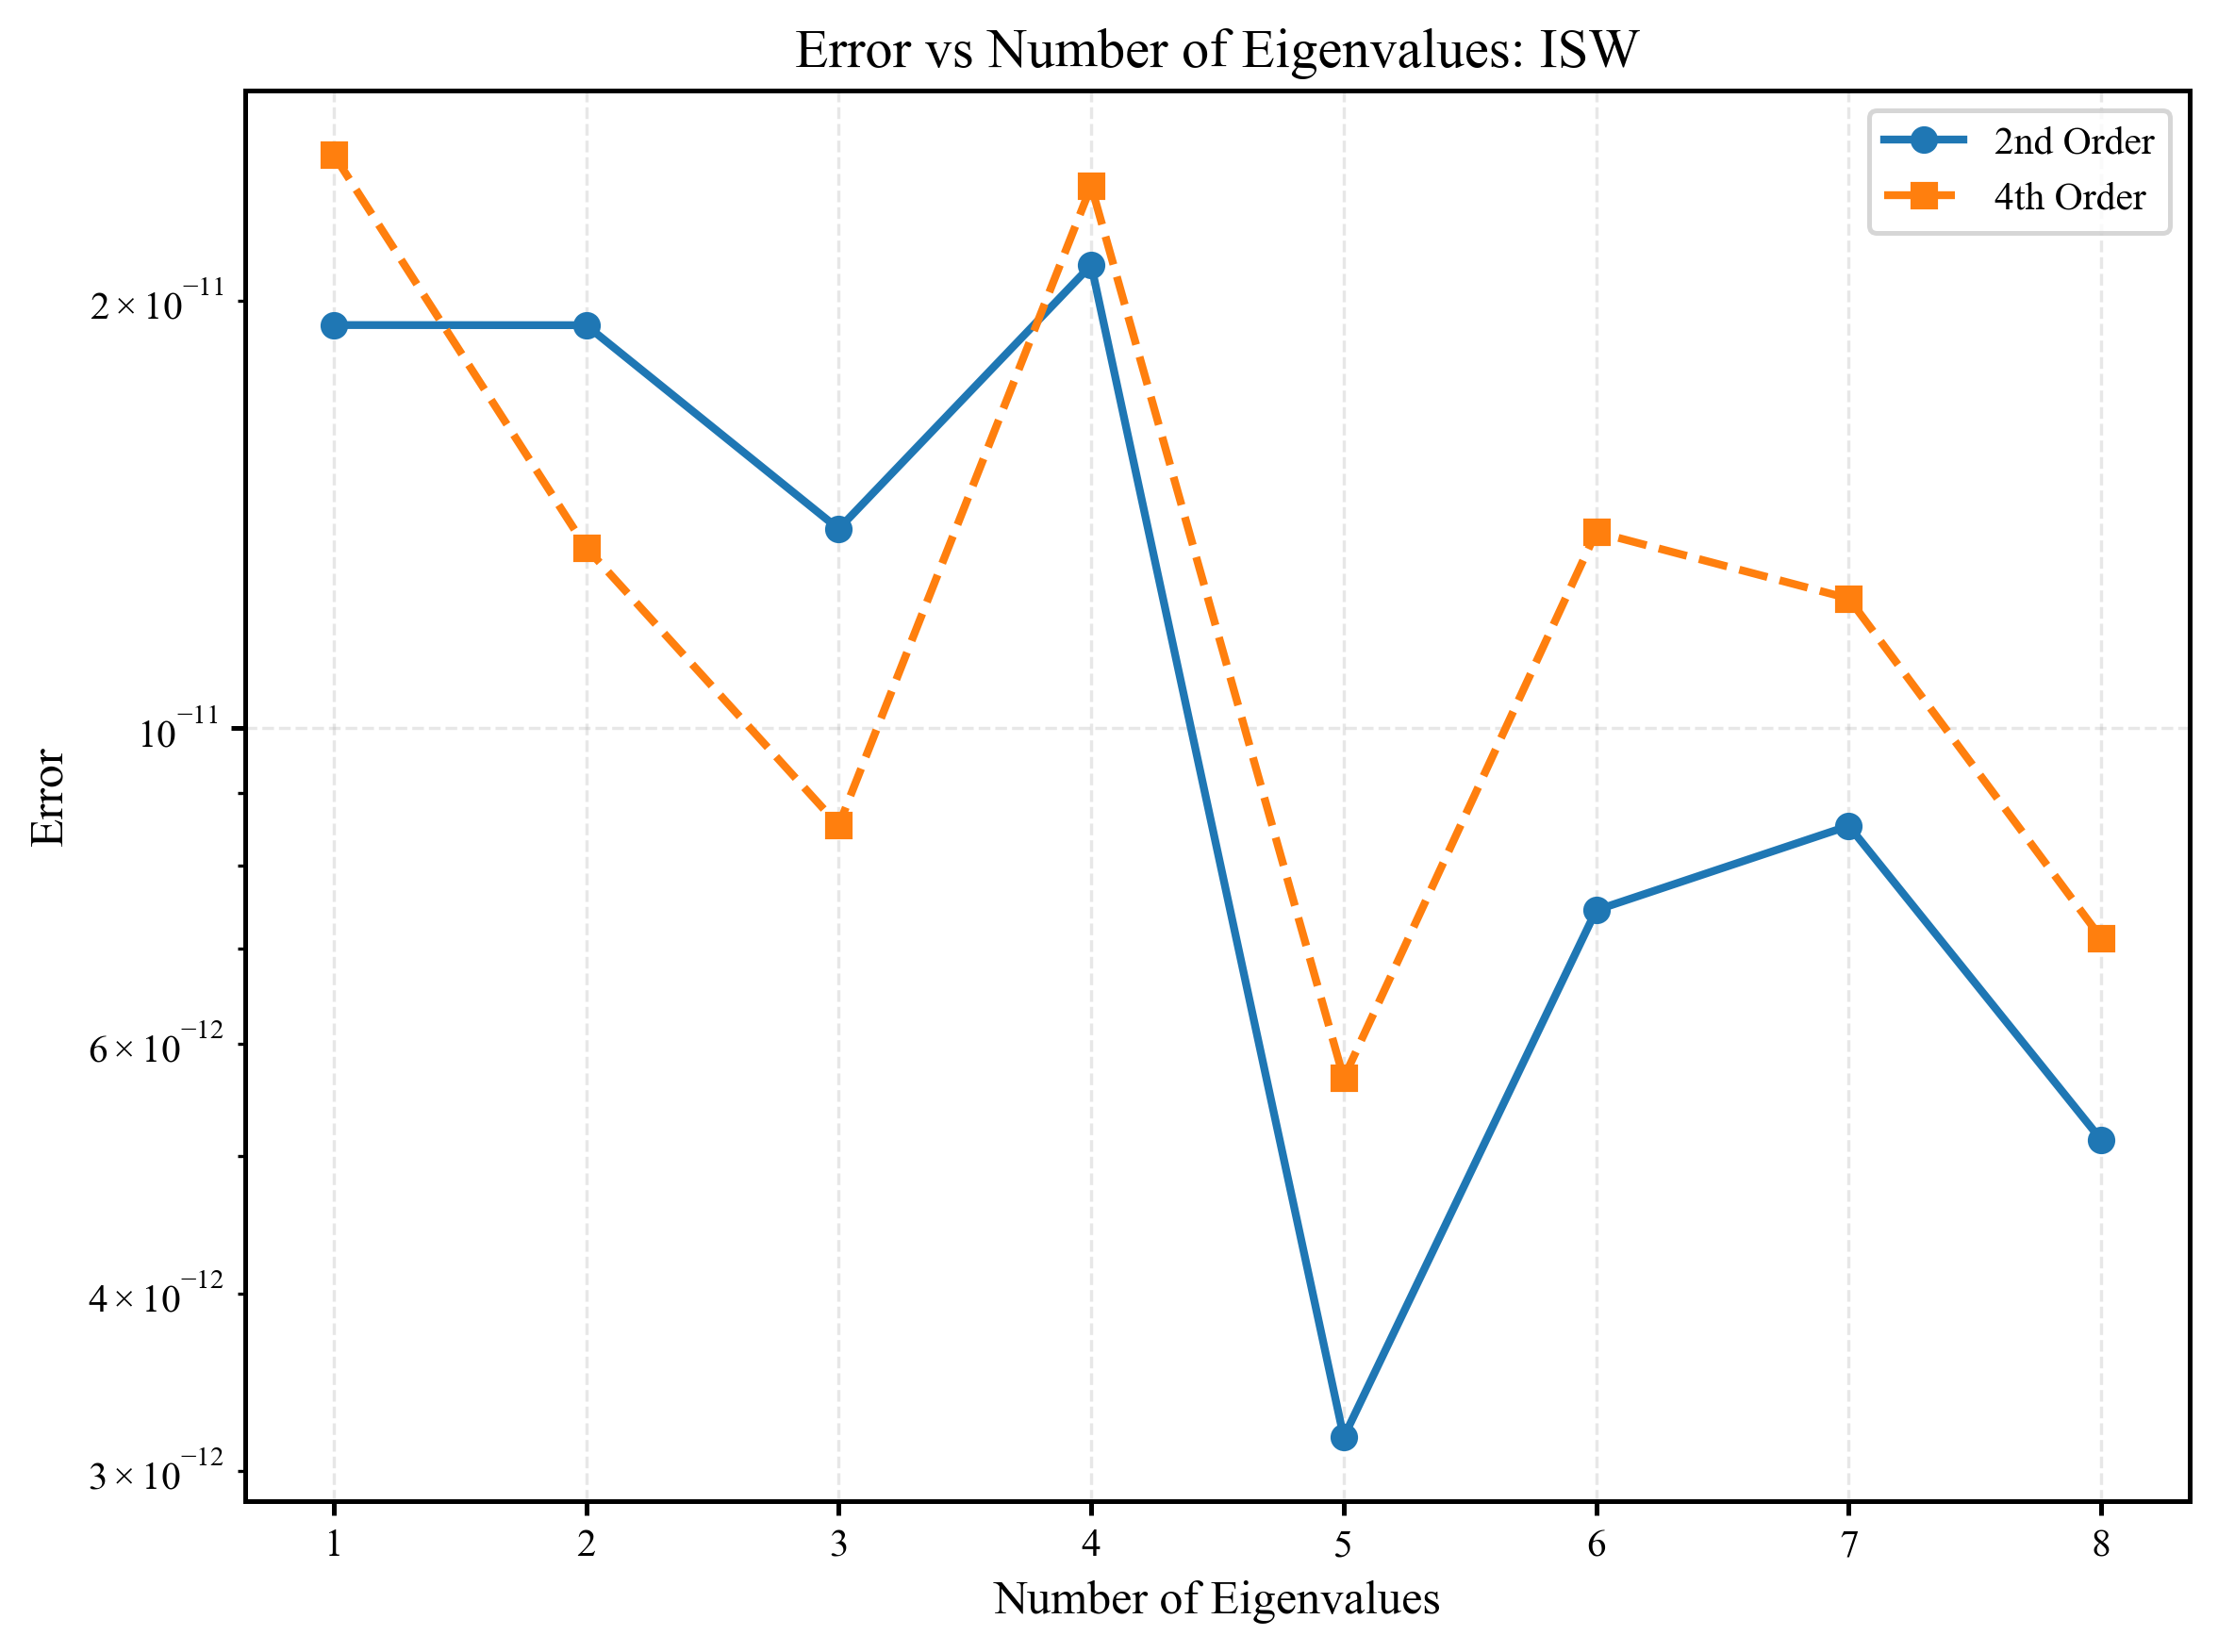

In [8]:
isw_results = run_all_analyses(
    isw_config,
    N_values=N_values_convergence,
    N_fixed=N_fixed,
    x_inf_values=None,
    n_eigenvalues_range=np.arange(1, 9, 1),
    save_prefix='isw'
)

### Generate Individual Analyses


In [9]:
N_values = np.arange(100, 901, 200)

convergence_results = generate_convergence_analysis(
    qsho_config, N_values, save_name='qsho_convergence_custom'
)

timing_results = generate_timing_analysis(
    qsho_config, N_values, save_name='qsho_timing_custom'
)

accuracy_results = generate_accuracy_analysis(
    qsho_config, N=800, save_name='qsho_accuracy_custom'
)
